# Film Stress — Joint Fit Analysis

Lightweight analysis notebook. Pulls the pre-built `stress_resonators` dict from a pickle file produced by `Film_Stress_Data_Formatting.ipynb`, then runs the V2 joint fit over three channels:

- **Loss vs T** (high-power, sub-Al-bond) — partly-saturated TLS + ω-phase QP + Nb QP + Q_other
- **Frequency shift vs T** (linear-response) — unsaturated TLS digamma + kinetic-inductance σ₂(T)
- **Loss vs photon number** (base T) — full TLS saturation curve

The power channel is what pins `n_c` and `β` independently; the freq channel pins `δ_TLS,0` absolutely; the loss-T channel cross-checks both. Together they break the degeneracies that single-channel fits leave open.


Usecase:

V2 is the original with ω-phase interpretation included

V5 (not included) showed we needed the two-medium model

V6 is not assuming anything about the phase (functionally Tc of the second phase is unbounded) and includes the power dependence of Qi

V7 is the same as V6 with an extended model to include frequency shift due to mean photon

For most updated and full model use V7, the previous ones are held just in case we need to go back for comparison. 

## Imports

In [2]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## Load data

Set `PKL_PATH` to wherever `Film_Stress_Data_Formatting.ipynb` saved the pickle. Default assumes it sits next to this notebook. To produce the pickle, add this single line to the bottom of the formatting notebook (after the `stress_resonators = { ... }` cell):

```python
save_resonator_data(stress_resonators, "stress_resonators.pkl")
```

In [2]:
PKL_PATH = Path("stress_resonators.pkl")

with open(PKL_PATH, "rb") as f:
    stress_resonators = pickle.load(f)

# Sanity print: samples, stresses, and resonator counts
print(f"Loaded {PKL_PATH} ({PKL_PATH.stat().st_size/1024:.1f} KB)")
print(f"  {len(stress_resonators)} samples\n")
for sample, chip in stress_resonators.items():
    s = chip.get('stress', None)
    se = chip.get('stress_err', None)
    res_keys = [k for k, v in chip.items() if isinstance(v, dict)]
    n_T = sum(1 for k in res_keys if 'Qi_Temp'  in chip[k])
    n_P = sum(1 for k in res_keys if 'Qi_Power' in chip[k])
    print(f"  {sample:<12} σ = {s:+7.1f} ± {se:>5.2f} MPa   "
          f"{len(res_keys):>2} resonators  ({n_T} w/ Qi(T), {n_P} w/ Qi(n))")

FileNotFoundError: [Errno 2] No such file or directory: 'stress_resonators.pkl'

## Joint fit model — Loss(T) + Freq(T) + Loss(n)

Self-contained model cell. Defines physics, dataset extraction from the new per-chip dict format, parameter packing/unpacking, cost functions, the DE + L-BFGS-B optimizer, and per-channel plotters.

**Tweakable hyperparameters at the top of the cell:** `T_BASE_POWER` (fridge base T for power sweeps, mK), `N_T_SWEEP` (photon number during temperature sweeps), `BETA_TLS_FIX`, `ALPHA_K_MODE` (`'per_stress'` or `'f_omega'`), `TC_OMEGA_FIX`, and the per-channel exclusion sets.

**Parameters fitted:**
- 7 shared physics: `δ_TLS,0`, `n_c`, `Tc_ω`, `Γ/Δ_ω`, `log10(f_0)`, `β_c`, `β_t`
- α_k slots: one per chip (`'per_stress'`) or `α_(k,Nb)` + `R` (`'f_omega'`)
- One `Q_other` per resonator

In [3]:
"""Joint Qi(T) + δf/f(T) + Qi(n) global fit V4 — per-chip δ_TLS,0 AND n_c.

═══════════════════════════════════════════════════════════════════════
WHAT'S NEW vs V3
═══════════════════════════════════════════════════════════════════════
1. δ_TLS,0 is now PER-SAMPLE (was global). Different chips genuinely
   have different TLS densities — different oxide thicknesses, anneal
   histories, surface preparation produce different two-level systems.
   With a single global δ_TLS,0, the freq channel for blueshift-only
   chips (C, D, E) was undershooting the data because Sample B (with
   ω-phase contributing redshift via different physics) was pulling
   δ_TLS,0 down. Per-chip lets each chip find its own (TLS amplitude,
   n_c, KI redshift) triplet without inter-chip coupling.

2. Parameter layout reshuffled again. V3 hot-start vectors are NOT
   compatible.

═══════════════════════════════════════════════════════════════════════
PARAMETER LAYOUT
═══════════════════════════════════════════════════════════════════════
GLOBAL (5):
    [0] Tc_ω                  ω-phase Tc (K)
    [1] log10(Γ/Δ_ω)         Dynes broadening of ω-phase
    [2] log10(f_0)           zero-stress nucleation fraction
    [3] β_c                  compressive nucleation sensitivity (MPa⁻²)
    [4] β_t                  tensile nucleation sensitivity (MPa⁻²)

PER-SAMPLE (3 × N_SAMPLE):
    [5 : 5+N_SAMPLE]                  log10(δ_TLS,0) per chip   ← NEW
    [5+N_SAMPLE : 5+2*N_SAMPLE]       log10(n_c) per chip
    [5+2*N_SAMPLE : ...]              α_k per chip (per_stress)
                                      OR α_(k,Nb), log10(R) (f_omega)

PER-RESONATOR:
    log10(Q_other_j)         residual loss for resonator j

FIXED:
    β_TLS = 0.5              literature value
    Tc_Nb = 9.2 K            bulk Nb gap parameter
    σ_opt = 0                stress reference for f_ω(σ)
"""
from scipy import special
from scipy.optimize import differential_evolution, minimize
import matplotlib
matplotlib.rcParams.update({"font.size": 11, "mathtext.default": "regular"})

# ═════════════════════════════════════════════════════════════════════
#  HYPERPARAMETERS
# ═════════════════════════════════════════════════════════════════════

h_SI    = 6.626070e-34
hbar_SI = h_SI / (2.0*np.pi)
Kb      = 1.380649e-23
TC_NB   = 9.2

SIGMA_OPT      = 0.0
T_BASE_POWER   = 100.0
N_T_SWEEP      = 1.0e5
DEFAULT_F_RES  = 5.5e9

BETA_TLS_FIX   = 0.5

T_LOSS_MAX     = 1000.0
T_FREQ_MAX     = 1000.0
temps_to_keep      = np.linspace(100, 1000, 10)
freq_temps_to_keep = np.linspace(100, 3000, 30)

N_PHOTON_MIN   = 1e0
N_PHOTON_MAX   = 1e8

LOSS_FRAC_FLOOR = 0.15
FREQ_FRAC_FLOOR = 0.10
FREQ_ABS_FLOOR  = 1e-7

ALPHA_K_MODE = "per_stress"

TLS_EXCLUDE_SAMPLES   = set()
FREQ_EXCLUDE_SAMPLES  = set()
POWER_EXCLUDE_SAMPLES = set()

EXCLUDE_RESONATORS = set()

TC_OMEGA_FIX = None

HOT_START = None    # ⚠ V3 hot-start vectors are NOT compatible with V4 layout.

# ═════════════════════════════════════════════════════════════════════
#  PHYSICS — unchanged from V3 (δ_TLS,0 entered as a scalar or array OK)
# ═════════════════════════════════════════════════════════════════════

def tls_loss_vec(T_mK, delta_TLS0, n_phot, n_c, beta, f_res):
    """δ_TLS(T, n) — TLS loss tangent with photon-number saturation.
       delta_TLS0 and n_c may be scalar OR array (per-data-point lookup)."""
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    f   = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    x   = np.clip(h_SI * f / (2*Kb*Tsa), 1e-10, 500)
    th  = np.tanh(x)
    n_c_arr = np.asarray(n_c, dtype=float)
    dT_arr  = np.asarray(delta_TLS0, dtype=float)
    n_ratio = np.asarray(n_phot, dtype=float) / np.maximum(n_c_arr, 1e-30)
    sat = 1.0 / np.sqrt(1.0 + n_ratio**beta)
    return dT_arr * th * sat


def tls_freq_shift_vec(T_mK, delta_TLS0, f_res):
    """δf_TLS/f₀ — unsaturated linear-response form. delta_TLS0 may be array."""
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    f   = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    arg = h_SI * f / (2.0 * np.pi * Kb * Tsa)
    z   = 0.5 + 1j*arg
    dT_arr = np.asarray(delta_TLS0, dtype=float)
    return (dT_arr/np.pi) * (np.real(special.digamma(z)) - np.log(arg))


def omega_frac_vec(stress, log_f0, beta_c, beta_t):
    ds = np.asarray(stress, dtype=float) - SIGMA_OPT
    f0 = 10.0**log_f0
    f  = np.where(ds < 0, f0 * np.exp(beta_c * ds**2),
                          f0 * np.exp(beta_t * ds**2))
    return np.clip(f, 0.0, 1.0)


def mb_sigma2_norm_vec(T_mK, Tc, f_res):
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    fr  = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    D0  = 1.764 * Kb * Tc
    hw  = h_SI * fr
    rat = Tc / Tsa
    D   = np.where(rat > 1.0,
                   D0 * np.tanh(1.74 * np.sqrt(np.clip(rat - 1.0, 0, None))),
                   0.0)
    arg = np.clip(D / (2*Kb*Tsa), 1e-10, 500)
    return np.where(D > 0, (np.pi*D/hw) * np.tanh(arg), 0.0)


def mb_loss_vec(T_mK, Tc, Gamma_ratio, f_res):
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    fr  = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    D0  = 1.764 * Kb * Tc
    hw  = h_SI * fr
    G   = Gamma_ratio * D0
    rat = Tc / Tsa
    D_bcs = np.where(rat > 1.0,
                     D0 * np.tanh(1.74 * np.sqrt(np.clip(rat - 1.0, 0, None))),
                     0.0)
    D = np.sqrt(D_bcs**2 + G**2)
    eta = np.clip(hw / (2*Kb*Tsa), 1e-12, 500)
    dkT = np.clip(D  / (Kb*Tsa),   0,     500)
    s1_th = (4.0*D/hw) * np.exp(-dkT) * np.sinh(eta) * special.k0(eta)
    s1_dy = (G/D)**2
    s1    = np.minimum(s1_th + s1_dy, 1.0)
    s2    = (np.pi*D/hw) * np.tanh(np.clip(D/(2*Kb*Tsa), 1e-10, 500))
    return s1 / np.maximum(s2, 1e-30)


def alpha_k_from_fw(fw, ak_Nb, R):
    M = (1.0 - fw) + fw * R
    num = ak_Nb * M
    return num / (1.0 - ak_Nb + num)


# ═════════════════════════════════════════════════════════════════════
#  DATA EXTRACTION (unchanged from V3)
# ═════════════════════════════════════════════════════════════════════

def _has_temp_data(rdict):
    return all(k in rdict for k in ('Qi_Temp', 'Qi_Temp_err', 'Temp', 'Freq')) \
           and len(rdict.get('Temp', [])) > 0


def _has_power_data(rdict):
    return all(k in rdict for k in ('Qi_Power', 'Qi_Power_err', 'Num_Photon')) \
           and len(rdict.get('Num_Photon', [])) > 0


def _subsample_T(Qi, QiErr, T, Freq, select_temps, temp_tol=60):
    select = np.asarray(select_temps)
    mask   = np.any(np.abs(T[:, None] - select[None, :]) <= temp_tol, axis=1)
    return Qi[mask], QiErr[mask], T[mask], Freq[mask]


def build_dataset(stress_resonators):
    catalog       = []
    loss_blocks   = []
    freq_blocks   = []
    power_blocks  = []

    sample_list = list(stress_resonators.keys())

    chip_f_res = {}
    for sample in sample_list:
        chip = stress_resonators[sample]
        freqs = []
        for k, sub in chip.items():
            if not isinstance(sub, dict):
                continue
            if 'Freq' in sub and len(sub['Freq']) > 0:
                freqs.append(np.nanmedian(np.asarray(sub['Freq'], dtype=float)))
        chip_f_res[sample] = float(np.nanmedian(freqs)) if freqs else DEFAULT_F_RES

    for sample in sample_list:
        chip = stress_resonators[sample]
        if 'stress' not in chip:
            print(f"  ⚠ Sample {sample!r} has no 'stress' key, skipping")
            continue
        stress_val     = float(chip['stress'])
        stress_err_val = float(chip.get('stress_err', 0.0))

        for label, sub in chip.items():
            if not isinstance(sub, dict):
                continue
            if (sample, label) in EXCLUDE_RESONATORS:
                print(f"  Excluding ({sample!r}, {label!r}) per EXCLUDE_RESONATORS")
                continue

            has_T = _has_temp_data(sub)
            has_P = _has_power_data(sub)
            if not has_T and not has_P:
                continue

            if has_T:
                f_res_full = np.asarray(sub['Freq'], dtype=float)
                f_res_med  = float(np.nanmedian(f_res_full))
            else:
                f_res_med  = chip_f_res[sample]

            T_ref_F = None
            f_ref_F = None
            if has_T:
                Q_T  = np.asarray(sub['Qi_Temp'],     dtype=float)
                E_T  = np.asarray(sub['Qi_Temp_err'], dtype=float)
                T_T  = np.asarray(sub['Temp'],        dtype=float)
                F_T  = np.asarray(sub['Freq'],        dtype=float)

                Q_L, E_L, T_L, _ = _subsample_T(Q_T, E_T, T_T, F_T, temps_to_keep)
                keep_L = T_L <= T_LOSS_MAX
                T_L, Q_L, E_L = T_L[keep_L], Q_L[keep_L], E_L[keep_L]
                if len(T_L) < 3:
                    print(f"  Skip ({sample!r}, {label!r}): only {len(T_L)} loss-T pts")
                    has_T = False
                else:
                    loss_blocks.append((T_L, Q_L, E_L))
                    _, _, T_F, F_F = _subsample_T(Q_T, E_T, T_T, F_T, freq_temps_to_keep)
                    keep_F = (T_F <= T_FREQ_MAX) & ~np.isnan(F_F)
                    T_F, F_F = T_F[keep_F], F_F[keep_F]
                    if len(T_F) >= 3:
                        i_ref   = int(np.argmin(T_F))
                        T_ref_F = float(T_F[i_ref])
                        f_ref_F = float(F_F[i_ref])
                        freq_blocks.append((T_F, F_F))
                    else:
                        freq_blocks.append((np.array([]), np.array([])))

            if has_P:
                n_arr = np.asarray(sub['Num_Photon'],   dtype=float)
                Q_P   = np.asarray(sub['Qi_Power'],     dtype=float)
                E_P   = np.asarray(sub['Qi_Power_err'], dtype=float)
                keep_P = (n_arr >= N_PHOTON_MIN) & (n_arr <= N_PHOTON_MAX) \
                       & np.isfinite(n_arr) & np.isfinite(Q_P) & (Q_P > 0)
                n_arr, Q_P, E_P = n_arr[keep_P], Q_P[keep_P], E_P[keep_P]
                if len(n_arr) < 3:
                    print(f"  ({sample!r}, {label!r}): only {len(n_arr)} power pts — skipping power")
                    has_P_used = False
                else:
                    power_blocks.append((n_arr, Q_P, E_P))
                    has_P_used = True
            else:
                has_P_used = False

            if not has_T and not has_P_used:
                continue

            j = len(catalog)
            n_loss = len(loss_blocks)
            n_freq = len(freq_blocks)
            n_pow  = len(power_blocks)
            if has_T and not has_P_used and n_pow < j + 1:
                power_blocks.append((np.array([]), np.array([]), np.array([])))
            if has_P_used and not has_T:
                if n_loss < j + 1:
                    loss_blocks.append((np.array([]), np.array([]), np.array([])))
                if n_freq < j + 1:
                    freq_blocks.append((np.array([]), np.array([])))

            catalog.append({
                'sample':     sample,
                'label':      label,
                'stress':     stress_val,
                'stress_err': stress_err_val,
                'f_res':      f_res_med,
                'has_T':      has_T,
                'has_P':      has_P_used,
                'T_ref_F':    T_ref_F,
                'f_ref_F':    f_ref_F,
            })

    return {
        'catalog':      catalog,
        'loss_blocks':  loss_blocks,
        'freq_blocks':  freq_blocks,
        'power_blocks': power_blocks,
        'sample_list':  list({rc['sample'] for rc in catalog}),
    }


def flatten_dataset(ds):
    catalog       = ds['catalog']
    loss_blocks   = ds['loss_blocks']
    freq_blocks   = ds['freq_blocks']
    power_blocks  = ds['power_blocks']
    N_RES         = len(catalog)

    SAMPLE_LIST = sorted({rc['sample'] for rc in catalog})
    SAMPLE_IDX  = {s: i for i, s in enumerate(SAMPLE_LIST)}

    L_j, L_s, L_T, L_loss, L_lerr, L_fres, L_smp = [], [], [], [], [], [], []
    F_j, F_s, F_T, F_dff, F_dferr, F_fres, F_Tref, F_smp = [], [], [], [], [], [], [], []
    P_j, P_s, P_n, P_loss, P_lerr, P_fres, P_smp = [], [], [], [], [], [], []

    for j, rc in enumerate(catalog):
        s   = rc['stress']
        smp = rc['sample']

        if rc['has_T'] and j in range(len(loss_blocks)):
            T_L, Q_L, E_L = loss_blocks[j]
            n = len(T_L)
            L_j.extend([j]*n);    L_s.extend([s]*n);  L_smp.extend([smp]*n)
            L_T.extend(T_L.tolist())
            L_loss.extend((1.0/Q_L).tolist())
            L_lerr.extend((E_L/Q_L**2).tolist())
            L_fres.extend([rc['f_res']]*n)

        if rc['has_T'] and (smp not in FREQ_EXCLUDE_SAMPLES):
            T_F, F_F = freq_blocks[j]
            if len(T_F) >= 3 and rc['f_ref_F'] is not None:
                f_ref = rc['f_ref_F']
                T_ref = rc['T_ref_F']
                dff = (F_F - f_ref) / f_ref
                base_std = float(np.std(dff[T_F < 350])) if np.any(T_F < 350) else 1e-7
                for i in range(len(T_F)):
                    if T_F[i] == T_ref:
                        continue
                    err = max(FREQ_ABS_FLOOR, base_std,
                              FREQ_FRAC_FLOOR * abs(dff[i]))
                    F_j.append(j);          F_s.append(s);    F_smp.append(smp)
                    F_T.append(T_F[i]);     F_dff.append(dff[i])
                    F_dferr.append(err);    F_fres.append(rc['f_res'])
                    F_Tref.append(T_ref)

        if rc['has_P'] and (smp not in POWER_EXCLUDE_SAMPLES):
            n_arr, Q_P, E_P = power_blocks[j]
            n = len(n_arr)
            P_j.extend([j]*n);    P_s.extend([s]*n);  P_smp.extend([smp]*n)
            P_n.extend(n_arr.tolist())
            P_loss.extend((1.0/Q_P).tolist())
            P_lerr.extend((E_P/Q_P**2).tolist())
            P_fres.extend([rc['f_res']]*n)

    flat = {
        'L_j':    np.asarray(L_j, dtype=int),
        'L_s':    np.asarray(L_s, dtype=float),
        'L_T':    np.asarray(L_T, dtype=float),
        'L_loss': np.asarray(L_loss, dtype=float),
        'L_lerr': np.asarray(L_lerr, dtype=float),
        'L_fres': np.asarray(L_fres, dtype=float),
        'L_smp':  np.asarray(L_smp),
        'L_tlsm': np.asarray([0.0 if smp in TLS_EXCLUDE_SAMPLES else 1.0
                              for smp in L_smp]),

        'F_j':     np.asarray(F_j, dtype=int),
        'F_s':     np.asarray(F_s, dtype=float),
        'F_T':     np.asarray(F_T, dtype=float),
        'F_dff':   np.asarray(F_dff, dtype=float),
        'F_dferr': np.asarray(F_dferr, dtype=float),
        'F_fres':  np.asarray(F_fres, dtype=float),
        'F_Tref':  np.asarray(F_Tref, dtype=float),
        'F_smp':   np.asarray(F_smp),
        'F_tlsm':  np.asarray([0.0 if smp in TLS_EXCLUDE_SAMPLES else 1.0
                               for smp in F_smp]),

        'P_j':    np.asarray(P_j, dtype=int),
        'P_s':    np.asarray(P_s, dtype=float),
        'P_n':    np.asarray(P_n, dtype=float),
        'P_loss': np.asarray(P_loss, dtype=float),
        'P_lerr': np.asarray(P_lerr, dtype=float),
        'P_fres': np.asarray(P_fres, dtype=float),
        'P_smp':  np.asarray(P_smp),
        'P_tlsm': np.asarray([0.0 if smp in TLS_EXCLUDE_SAMPLES else 1.0
                              for smp in P_smp]),

        'SAMPLE_LIST': SAMPLE_LIST,
        'SAMPLE_IDX':  SAMPLE_IDX,
        'N_RES':       N_RES,
    }

    flat['L_smp_idx'] = np.array([SAMPLE_IDX[smp] for smp in L_smp], dtype=int)
    flat['F_smp_idx'] = np.array([SAMPLE_IDX[smp] for smp in F_smp], dtype=int)
    flat['P_smp_idx'] = np.array([SAMPLE_IDX[smp] for smp in P_smp], dtype=int)

    flat['L_lerr_eff'] = np.sqrt(flat['L_lerr']**2 + (LOSS_FRAC_FLOOR*flat['L_loss'])**2)
    flat['P_lerr_eff'] = np.sqrt(flat['P_lerr']**2 + (LOSS_FRAC_FLOOR*flat['P_loss'])**2)

    return flat


# ═════════════════════════════════════════════════════════════════════
#  PARAMETER PACK / UNPACK — V4 layout
# ═════════════════════════════════════════════════════════════════════
#
# x_sh layout (length = N_GLOBAL + 2*N_SAMPLE + N_AK):
#   [0]                                     Tc_ω
#   [1]                                     log10(Γ/Δ_ω)
#   [2]                                     log10(f_0)
#   [3]                                     β_c
#   [4]                                     β_t
#   [5 : 5+N_SAMPLE]                        log10(δ_TLS,0) per sample
#   [5+N_SAMPLE : 5+2*N_SAMPLE]             log10(n_c) per sample
#   [5+2*N_SAMPLE : ...]                    α_k slots

N_GLOBAL = 5     # (Tc_ω, Γ/Δ_ω, f_0, β_c, β_t)

FLAT       = None
CATALOG    = None
N_SAMPLE   = None
N_RES      = None
N_AK       = None
N_SHARED   = None


def _unpack(x_sh):
    """Unpack the shared parameter vector into a dict."""
    out = {
        "Tcw":    x_sh[0],
        "Gr":     10.0**x_sh[1],
        "log_f0": x_sh[2],
        "bc":     x_sh[3],
        "bt":     x_sh[4],
    }
    out["dT_arr"]  = 10.0**np.asarray(x_sh[N_GLOBAL : N_GLOBAL + N_SAMPLE])
    out["n_c_arr"] = 10.0**np.asarray(x_sh[N_GLOBAL + N_SAMPLE : N_GLOBAL + 2*N_SAMPLE])
    ak_start = N_GLOBAL + 2*N_SAMPLE
    if ALPHA_K_MODE == "per_stress":
        out["ak_arr"] = 10.0**np.asarray(x_sh[ak_start : ak_start + N_SAMPLE])
    else:  # f_omega
        out["ak_Nb"] = x_sh[ak_start]
        out["R"]     = 10.0**x_sh[ak_start + 1]
    return out


def _ak_lookup(p, smp_idx, fw_arr=None):
    if ALPHA_K_MODE == "per_stress":
        return p["ak_arr"][smp_idx]
    else:
        return alpha_k_from_fw(fw_arr, p["ak_Nb"], p["R"])


def model_loss_T(x_sh, log_Qo):
    if len(FLAT['L_T']) == 0:
        return np.array([])
    p = _unpack(x_sh)
    dT_per_pt  = p["dT_arr"][FLAT['L_smp_idx']]
    n_c_per_pt = p["n_c_arr"][FLAT['L_smp_idx']]
    d_tls = tls_loss_vec(FLAT['L_T'], dT_per_pt, N_T_SWEEP, n_c_per_pt,
                         BETA_TLS_FIX, FLAT['L_fres']) * FLAT['L_tlsm']
    fw    = omega_frac_vec(FLAT['L_s'], p["log_f0"], p["bc"], p["bt"])
    d_w   = mb_loss_vec(FLAT['L_T'], p["Tcw"], p["Gr"], FLAT['L_fres'])
    d_Nb  = mb_loss_vec(FLAT['L_T'], TC_NB,    1e-6,    FLAT['L_fres'])
    d_oth = 1.0 / (10.0**log_Qo[FLAT['L_j']])
    return d_tls + fw*d_w + d_Nb + d_oth


def model_loss_P(x_sh, log_Qo):
    if len(FLAT['P_n']) == 0:
        return np.array([])
    p = _unpack(x_sh)
    dT_per_pt  = p["dT_arr"][FLAT['P_smp_idx']]
    n_c_per_pt = p["n_c_arr"][FLAT['P_smp_idx']]
    T_b = np.full_like(FLAT['P_n'], T_BASE_POWER)
    d_tls = tls_loss_vec(T_b, dT_per_pt, FLAT['P_n'], n_c_per_pt,
                         BETA_TLS_FIX, FLAT['P_fres']) * FLAT['P_tlsm']
    fw    = omega_frac_vec(FLAT['P_s'], p["log_f0"], p["bc"], p["bt"])
    d_w   = mb_loss_vec(T_b, p["Tcw"], p["Gr"], FLAT['P_fres'])
    d_Nb  = mb_loss_vec(T_b, TC_NB,    1e-6,    FLAT['P_fres'])
    d_oth = 1.0 / (10.0**log_Qo[FLAT['P_j']])
    return d_tls + fw*d_w + d_Nb + d_oth


def model_freq_T(x_sh):
    if len(FLAT['F_T']) == 0:
        return np.array([])
    p = _unpack(x_sh)
    dT_per_pt = p["dT_arr"][FLAT['F_smp_idx']]
    fw_F  = omega_frac_vec(FLAT['F_s'], p["log_f0"], p["bc"], p["bt"])
    ak    = _ak_lookup(p, FLAT['F_smp_idx'], fw_F)

    df_tls = (tls_freq_shift_vec(FLAT['F_T'],    dT_per_pt, FLAT['F_fres']) -
              tls_freq_shift_vec(FLAT['F_Tref'], dT_per_pt, FLAT['F_fres'])) * FLAT['F_tlsm']

    s2_NbT = mb_sigma2_norm_vec(FLAT['F_T'],    TC_NB,    FLAT['F_fres'])
    s2_NbR = mb_sigma2_norm_vec(FLAT['F_Tref'], TC_NB,    FLAT['F_fres'])
    s2_wT  = mb_sigma2_norm_vec(FLAT['F_T'],    p["Tcw"], FLAT['F_fres'])
    s2_wR  = mb_sigma2_norm_vec(FLAT['F_Tref'], p["Tcw"], FLAT['F_fres'])
    s2_T = (1 - fw_F)*s2_NbT + fw_F*s2_wT
    s2_R = (1 - fw_F)*s2_NbR + fw_F*s2_wR
    df_kin = -(ak/2.0) * (s2_R / np.maximum(s2_T, 1e-30) - 1.0)

    return df_tls + df_kin


def chi2_breakdown(x_sh, log_Qo):
    res_L = (FLAT['L_loss'] - model_loss_T(x_sh, log_Qo)) / FLAT['L_lerr_eff']
    res_F = (FLAT['F_dff']  - model_freq_T(x_sh))         / FLAT['F_dferr']
    res_P = (FLAT['P_loss'] - model_loss_P(x_sh, log_Qo)) / FLAT['P_lerr_eff']
    return (float(np.sum(res_L**2)), float(np.sum(res_F**2)), float(np.sum(res_P**2)),
            len(FLAT['L_loss']),     len(FLAT['F_dff']),     len(FLAT['P_loss']))


def cost_phase1(x_sh):
    log_Qo = LOG_Q_INIT
    chi2_L, chi2_F, chi2_P, N_L, N_F, N_P = chi2_breakdown(x_sh, log_Qo)
    return (chi2_L + chi2_F + chi2_P) / max(N_L + N_F + N_P, 1)


def cost_phase2(x_all):
    x_sh, log_Qo = x_all[:N_SHARED], x_all[N_SHARED:]
    chi2_L, chi2_F, chi2_P, N_L, N_F, N_P = chi2_breakdown(x_sh, log_Qo)
    return (chi2_L + chi2_F + chi2_P) / max(N_L + N_F + N_P, 1)


# ═════════════════════════════════════════════════════════════════════
#  RUN FIT
# ═════════════════════════════════════════════════════════════════════

LOG_Q_INIT = None


def run_fit(stress_resonators, popsize=30, de_maxiter=2000, verbose=True):
    global FLAT, CATALOG, N_SAMPLE, N_RES, N_AK, N_SHARED, LOG_Q_INIT

    ds   = build_dataset(stress_resonators)
    flat = flatten_dataset(ds)

    FLAT     = flat
    CATALOG  = ds['catalog']
    N_RES    = flat['N_RES']
    N_SAMPLE = len(flat['SAMPLE_LIST'])
    if ALPHA_K_MODE == "per_stress":
        N_AK = N_SAMPLE
    elif ALPHA_K_MODE == "f_omega":
        N_AK = 2
    else:
        raise ValueError(f"Unknown ALPHA_K_MODE: {ALPHA_K_MODE!r}")
    N_SHARED = N_GLOBAL + 2*N_SAMPLE + N_AK

    if verbose:
        print(f"\n{'='*72}")
        print(f"  Joint fit V4: Loss-T + Freq-T + Loss-P  (per-chip δ_TLS,0 AND n_c)")
        print(f"{'='*72}")
        print(f"  Samples: {flat['SAMPLE_LIST']}")
        print(f"  N_RES = {N_RES}  (each contributes to L/F/P channels as available)")
        print(f"  Loss-T pts:  {len(flat['L_loss']):4d}  (T ≤ {T_LOSS_MAX:.0f} mK)")
        print(f"  Freq-T pts:  {len(flat['F_dff']):4d}  (T ≤ {T_FREQ_MAX:.0f} mK)")
        print(f"  Loss-P pts:  {len(flat['P_loss']):4d}  ({N_PHOTON_MIN:.0e} ≤ n ≤ {N_PHOTON_MAX:.0e})")
        print(f"  α_k mode: {ALPHA_K_MODE!r}  (N_AK = {N_AK})")
        print(f"  Total params: {N_SHARED + N_RES} = "
              f"{N_GLOBAL} global + {N_SAMPLE} δ_TLS,0 + {N_SAMPLE} n_c "
              f"+ {N_AK} α_k + {N_RES} Q_other")
        print(f"  β_TLS FIXED at {BETA_TLS_FIX}")
        print(f"  N_T_SWEEP = {N_T_SWEEP:.0e},  T_BASE_POWER = {T_BASE_POWER:.0f} mK")
        print()
        print(f"  {'idx':>3}  {'sample':<10} {'label':<14} {'σ (MPa)':>8}  "
              f"{'f (GHz)':>8}  {'L':>3} {'F':>3} {'P':>3}")
        print(f"  {'-'*3}  {'-'*10} {'-'*14} {'-'*8}  {'-'*8}  {'-'*3} {'-'*3} {'-'*3}")
        for j, rc in enumerate(CATALOG):
            n_L = int(np.sum(flat['L_j'] == j))
            n_F = int(np.sum(flat['F_j'] == j))
            n_P = int(np.sum(flat['P_j'] == j))
            print(f"  {j:>3}  {rc['sample']:<10} {rc['label']:<14} "
                  f"{rc['stress']:>+8.1f}  {rc['f_res']/1e9:>8.4f}  "
                  f"{n_L:>3} {n_F:>3} {n_P:>3}")

    Q_other_init = np.empty(N_RES)
    for j, rc in enumerate(CATALOG):
        cands = []
        L_mask = flat['L_j'] == j
        if np.any(L_mask):
            cands.append(np.max(1.0/flat['L_loss'][L_mask]))
        P_mask = flat['P_j'] == j
        if np.any(P_mask):
            cands.append(np.max(1.0/flat['P_loss'][P_mask]))
        Q_other_init[j] = max(cands) if cands else 1e5
    LOG_Q_INIT = np.log10(Q_other_init)

    bounds_shared = [
        ( 0.5,  10.0),    # Tc_ω
        (-6.0, -0.001),  # log10(Γ/Δ_ω)
        (-15.0, -2.0),   # log10(f_0)
        ( 0.0, 3e-4),    # β_c
        ( 0.0, 3e-4),    # β_t
    ]
    # Per-sample δ_TLS,0:  log10 ∈ (-6, -3)  → δ_TLS,0 ∈ [1e-6, 1e-3]
    bounds_shared.extend([(-9.0, -3.0)] * N_SAMPLE)
    # Per-sample n_c:  log10 ∈ (-2, 7)  → n_c ∈ [0.01, 1e7]
    bounds_shared.extend([(-2.0, 7.0)] * N_SAMPLE)
    # α_k bounds
    if ALPHA_K_MODE == "per_stress":
        bounds_shared.extend([(-3.0, 0.0)] * N_SAMPLE)
    else:
        bounds_shared.append((0.001, 0.5))
        bounds_shared.append((0.0,   3.0))

    # Tc_ω is now at INDEX 0
    if TC_OMEGA_FIX is not None:
        eps = 1e-3
        bounds_shared[0] = (TC_OMEGA_FIX - eps, TC_OMEGA_FIX + eps)
        if verbose:
            print(f"\n  Tc_ω FIXED at {TC_OMEGA_FIX:.3f} K")

    if HOT_START is not None:
        seed_arr = np.array(HOT_START, dtype=float)
        if len(seed_arr) != N_SHARED:
            print(f"  ⚠ HOT_START length {len(seed_arr)} != N_SHARED {N_SHARED}; ignoring.")
            de_init = 'sobol'
        else:
            for i, (lo, hi) in enumerate(bounds_shared):
                if not (lo <= seed_arr[i] <= hi):
                    seed_arr[i] = np.clip(seed_arr[i], lo, hi)
            rng = np.random.default_rng(42)
            n_total = popsize * N_SHARED
            init = np.zeros((n_total, N_SHARED))
            init[0] = seed_arr
            widths = np.array([hi-lo for lo, hi in bounds_shared])
            for i in range(1, min(6, n_total)):
                init[i] = np.clip(init[0] + rng.normal(0, 0.05*widths),
                                  [lo for lo, hi in bounds_shared],
                                  [hi for lo, hi in bounds_shared])
            for i in range(min(6, n_total), n_total):
                init[i] = np.array([rng.uniform(lo, hi) for lo, hi in bounds_shared])
            de_init = init
    else:
        de_init = 'sobol'

    if verbose:
        print(f"\n  Phase 1: differential evolution on {N_SHARED} shared params ...")
    res1 = differential_evolution(
        cost_phase1, bounds_shared,
        seed=42, maxiter=de_maxiter, tol=1e-10,
        mutation=(0.5, 1.5), recombination=0.9,
        popsize=popsize, polish=True, init=de_init,
    )
    if verbose:
        print(f"  Phase 1: χ²_red = {res1.fun:.3f}  ({res1.nit} gen)")

    bounds_Qo = []
    for j in range(N_RES):
        floor = 10.0**LOG_Q_INIT[j] * 0.5
        bounds_Qo.append((np.log10(floor), np.log10(floor*1000)))

    bounds_all = bounds_shared + bounds_Qo
    x0 = np.concatenate([res1.x, LOG_Q_INIT])

    if verbose:
        print(f"  Phase 2: L-BFGS-B refinement ({N_SHARED + N_RES} params) ...")
    res2 = minimize(
        cost_phase2, x0, method='L-BFGS-B', bounds=bounds_all,
        options={'maxiter': 5000, 'ftol': 1e-14, 'gtol': 1e-10},
    )
    if verbose:
        print(f"  Phase 2: χ²_red = {res2.fun:.3f}  "
              f"({'converged' if res2.success else res2.message})")

    xf = res2.x
    p  = _unpack(xf[:N_SHARED])
    Qo = 10.0**xf[N_SHARED:]
    chi2_L, chi2_F, chi2_P, N_L, N_F, N_P = chi2_breakdown(xf[:N_SHARED], xf[N_SHARED:])

    fw_per_sample = {smp: float(omega_frac_vec(
                       float([rc['stress'] for rc in CATALOG if rc['sample']==smp][0]),
                       p["log_f0"], p["bc"], p["bt"]))
                     for smp in flat['SAMPLE_LIST']}
    dT_per_sample  = {smp: float(p["dT_arr"][flat['SAMPLE_IDX'][smp]])
                      for smp in flat['SAMPLE_LIST']}
    n_c_per_sample = {smp: float(p["n_c_arr"][flat['SAMPLE_IDX'][smp]])
                      for smp in flat['SAMPLE_LIST']}
    if ALPHA_K_MODE == "per_stress":
        ak_per_sample = {smp: float(p["ak_arr"][flat['SAMPLE_IDX'][smp]])
                         for smp in flat['SAMPLE_LIST']}
    else:
        ak_per_sample = {smp: float(alpha_k_from_fw(fw_per_sample[smp], p["ak_Nb"], p["R"]))
                         for smp in flat['SAMPLE_LIST']}

    if verbose:
        D0w = 1.764 * Kb * p["Tcw"]
        G   = p["Gr"] * D0w
        print(f"\n  ── Final results (joint χ²_red = {res2.fun:.3f}) ──")
        print(f"  TLS:    β_TLS    = {BETA_TLS_FIX:.3f}  (FIXED, per-chip δ_TLS,0 in table)")
        print(f"  ω:      Tc_ω     = {p['Tcw']:.3f} K")
        print(f"          Γ/Δ₀     = {p['Gr']:.4e}")
        print(f"          Γ        = {G/1.602e-19*1e6:.3f} μeV")
        print(f"          Δ₀(ω)    = {D0w/1.602e-19*1e3:.4f} meV")
        print(f"          f_0      = {10**p['log_f0']:.3e}  (zero-stress)")
        print(f"          β_c      = {p['bc']:.3e} MPa⁻²")
        print(f"          β_t      = {p['bt']:.3e} MPa⁻²")
        print(f"  KI:     α_k mode = {ALPHA_K_MODE!r}")
        print()
        print(f"  Per-sample δ_TLS,0, n_c, f_ω(σ), and α_k:")
        print(f"    {'sample':<12} {'σ (MPa)':>9}  {'δ_TLS,0':>11}  {'n_c (phot)':>12}  "
              f"{'f_ω (%)':>9}  {'α_k':>7}")
        print(f"    {'-'*12} {'-'*9}  {'-'*11}  {'-'*12}  {'-'*9}  {'-'*7}")
        for smp in flat['SAMPLE_LIST']:
            s = [rc['stress'] for rc in CATALOG if rc['sample']==smp][0]
            print(f"    {smp:<12} {s:>+9.1f}  {dT_per_sample[smp]:>11.3e}  "
                  f"{n_c_per_sample[smp]:>12.4e}  "
                  f"{fw_per_sample[smp]*100:>9.4f}  {ak_per_sample[smp]:>7.4f}")
        print()
        print(f"  χ² breakdown:")
        print(f"    Loss-T:  {chi2_L:8.1f} / {N_L:4d}  =  {chi2_L/max(N_L,1):.3f}")
        print(f"    Freq-T:  {chi2_F:8.1f} / {N_F:4d}  =  {chi2_F/max(N_F,1):.3f}")
        print(f"    Loss-P:  {chi2_P:8.1f} / {N_P:4d}  =  {chi2_P/max(N_P,1):.3f}")

        # Bound proximity — V4 layout
        print(f"\n  Bound proximity (within 5% of edge flagged):")
        labels = ['Tc_ω', 'log10(Γ/Δ_ω)', 'log10(f_0)', 'β_c', 'β_t']
        for smp in flat['SAMPLE_LIST']:
            labels.append(f'log10(δ_TLS,0[{smp}])')
        for smp in flat['SAMPLE_LIST']:
            labels.append(f'log10(n_c[{smp}])')
        if ALPHA_K_MODE == "per_stress":
            for smp in flat['SAMPLE_LIST']:
                labels.append(f'log10(α_k[{smp}])')
        else:
            labels.append('α_(k,Nb)')
            labels.append('log10(R)')
        warned = False
        for i, (lo, hi) in enumerate(bounds_shared):
            if i == 0 and TC_OMEGA_FIX is not None:
                continue
            rel = min(xf[i] - lo, hi - xf[i]) / max(hi - lo, 1e-12)
            if rel < 0.05:
                print(f"    ⚠ {labels[i]:<25s} = {xf[i]:.3f}  near bound [{lo}, {hi}]")
                warned = True
        if not warned:
            print("    (none)")

        print(f"\n  Per-resonator Q_other:")
        for j, rc in enumerate(CATALOG):
            tags = []
            if rc['has_T']:  tags.append('T')
            if rc['has_P']:  tags.append('P')
            tag = '+'.join(tags)
            print(f"    [{j:2d}] {rc['sample']:<10} {rc['label']:<14}  "
                  f"Q_other = {Qo[j]:.3e}  ({tag})")

    return {
        'res1':           res1,
        'res2':           res2,
        'x':              xf,
        'shared':         p,
        'Q_other':        Qo,
        'fw_per_sample':  fw_per_sample,
        'dT_per_sample':  dT_per_sample,    # NEW
        'n_c_per_sample': n_c_per_sample,
        'ak_per_sample':  ak_per_sample,
        'flat':           flat,
        'catalog':        CATALOG,
        'chi2': {
            'loss_T': (chi2_L, N_L),
            'freq_T': (chi2_F, N_F),
            'loss_P': (chi2_P, N_P),
        },
        'bounds_shared': bounds_shared,
        'bounds_Qo':     bounds_Qo,
    }


# ═════════════════════════════════════════════════════════════════════
#  PLOT HELPERS — model curves use per-chip δ_TLS,0 AND n_c
# ═════════════════════════════════════════════════════════════════════

def model_Qi_T_curve(T_arr, j, fit):
    rc = fit['catalog'][j]
    p  = fit['shared']
    s  = rc['stress']
    f_res = rc['f_res']
    n_c_local = fit['n_c_per_sample'][rc['sample']]
    dT_local  = fit['dT_per_sample'][rc['sample']]
    tls_mask = 0.0 if rc['sample'] in TLS_EXCLUDE_SAMPLES else 1.0
    d_tls = tls_loss_vec(T_arr, dT_local, N_T_SWEEP, n_c_local,
                         BETA_TLS_FIX, f_res) * tls_mask
    fw   = float(omega_frac_vec(s, p["log_f0"], p["bc"], p["bt"]))
    d_w  = mb_loss_vec(T_arr, p["Tcw"], p["Gr"], f_res)
    d_Nb = mb_loss_vec(T_arr, TC_NB,    1e-6,    f_res)
    d_oth = 1.0 / fit['Q_other'][j]
    return 1.0 / (d_tls + fw*d_w + d_Nb + d_oth)


def model_Qi_n_curve(n_arr, j, fit, T_base=None):
    rc = fit['catalog'][j]
    p  = fit['shared']
    s  = rc['stress']
    f_res = rc['f_res']
    if T_base is None:
        T_base = T_BASE_POWER
    n_c_local = fit['n_c_per_sample'][rc['sample']]
    dT_local  = fit['dT_per_sample'][rc['sample']]
    tls_mask = 0.0 if rc['sample'] in TLS_EXCLUDE_SAMPLES else 1.0
    T_b = np.full_like(n_arr, T_base, dtype=float)
    d_tls = tls_loss_vec(T_b, dT_local, n_arr, n_c_local,
                         BETA_TLS_FIX, f_res) * tls_mask
    fw   = float(omega_frac_vec(s, p["log_f0"], p["bc"], p["bt"]))
    d_w  = mb_loss_vec(T_b, p["Tcw"], p["Gr"], f_res)
    d_Nb = mb_loss_vec(T_b, TC_NB,    1e-6,    f_res)
    d_oth = 1.0 / fit['Q_other'][j]
    return 1.0 / (d_tls + fw*d_w + d_Nb + d_oth)


def model_df_curve(T_arr, j, fit):
    rc = fit['catalog'][j]
    p  = fit['shared']
    s  = rc['stress']
    f_res = rc['f_res']
    T_ref = rc['T_ref_F']
    if T_ref is None:
        return np.zeros_like(T_arr)
    dT_local  = fit['dT_per_sample'][rc['sample']]
    tls_mask = 0.0 if rc['sample'] in TLS_EXCLUDE_SAMPLES else 1.0
    df_tls = (tls_freq_shift_vec(T_arr,             dT_local, f_res) -
              tls_freq_shift_vec(np.array([T_ref]), dT_local, f_res)[0]) * tls_mask
    fw_local = float(omega_frac_vec(s, p["log_f0"], p["bc"], p["bt"]))
    ak_local = fit['ak_per_sample'][rc['sample']]
    s2_NT = mb_sigma2_norm_vec(T_arr,             TC_NB,    f_res)
    s2_NR = mb_sigma2_norm_vec(np.array([T_ref]), TC_NB,    f_res)[0]
    s2_wT = mb_sigma2_norm_vec(T_arr,             p["Tcw"], f_res)
    s2_wR = mb_sigma2_norm_vec(np.array([T_ref]), p["Tcw"], f_res)[0]
    s2T = (1 - fw_local)*s2_NT + fw_local*s2_wT
    s2R = (1 - fw_local)*s2_NR + fw_local*s2_wR
    return df_tls - (ak_local/2.0)*(s2R/np.maximum(s2T, 1e-30) - 1.0)


# ═════════════════════════════════════════════════════════════════════
#  PLOTS — annotate per-chip δ_TLS,0 in titles
# ═════════════════════════════════════════════════════════════════════

def _grid_for_n(n):
    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))
    return rows, cols


def plot_loss_T(fit, figsize=None):
    flat = fit['flat']
    samples = flat['SAMPLE_LIST']
    n = len(samples)
    rows, cols = _grid_for_n(n)
    if figsize is None:
        figsize = (5*cols, 4*rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axf = axes.flat
    T_mod = np.linspace(80, T_LOSS_MAX, 300)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for pi, smp in enumerate(samples):
        ax = axf[pi]
        rr = [(j, rc) for j, rc in enumerate(fit['catalog'])
              if rc['sample'] == smp and rc['has_T']]
        for k, (j, rc) in enumerate(rr):
            mask = flat['L_j'] == j
            T_d  = flat['L_T'][mask]
            Qi_d = 1.0/flat['L_loss'][mask]
            err_d = flat['L_lerr'][mask] / flat['L_loss'][mask]**2
            c = color_cycle[k % len(color_cycle)]
            ax.errorbar(T_d, Qi_d, yerr=err_d, fmt='o', ms=4, alpha=0.7,
                        color=c, label=f"{rc['label']}")
            ax.plot(T_mod, model_Qi_T_curve(T_mod, j, fit),
                    '-', color=c, lw=1.4, alpha=0.9)
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        dT_smp = fit['dT_per_sample'][smp]
        n_c_smp = fit['n_c_per_sample'][smp]
        ax.set_title(f"{smp}: σ={s_val:+.1f}, δ_TLS={dT_smp:.2g}, n_c={n_c_smp:.2g}",
                     fontsize=10)
        ax.set_xlabel('T (mK)'); ax.set_ylabel('$Q_i$')
        ax.set_yscale('log'); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='best')

    for k in range(n, rows*cols):
        axf[k].axis('off')
    fig.suptitle('Loss vs T (high-power, sub-Al-bond)', fontsize=14)
    fig.tight_layout()
    return fig


def plot_freq_T(fit, figsize=None):
    flat = fit['flat']
    samples = flat['SAMPLE_LIST']
    n = len(samples)
    rows, cols = _grid_for_n(n)
    if figsize is None:
        figsize = (5*cols, 4*rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axf = axes.flat
    T_mod = np.linspace(80, T_FREQ_MAX, 300)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for pi, smp in enumerate(samples):
        ax = axf[pi]
        rr = [(j, rc) for j, rc in enumerate(fit['catalog'])
              if rc['sample'] == smp and rc['has_T']
                 and smp not in FREQ_EXCLUDE_SAMPLES]
        for k, (j, rc) in enumerate(rr):
            mask = flat['F_j'] == j
            T_d   = flat['F_T'][mask]
            dff_d = flat['F_dff'][mask]
            err_d = flat['F_dferr'][mask]
            c = color_cycle[k % len(color_cycle)]
            ax.errorbar(T_d, dff_d*1e6, yerr=err_d*1e6, fmt='o', ms=4, alpha=0.7,
                        color=c, label=f"{rc['label']}")
            ax.plot(T_mod, model_df_curve(T_mod, j, fit)*1e6,
                    '-', color=c, lw=1.4, alpha=0.9)
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        dT_smp = fit['dT_per_sample'][smp]
        ax.set_title(f"{smp}: σ={s_val:+.1f} MPa, δ_TLS={dT_smp:.2g}", fontsize=10)
        ax.set_xlabel('T (mK)'); ax.set_ylabel(r'$\delta f / f_0$  (ppm)')
        ax.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='best')

    for k in range(n, rows*cols):
        axf[k].axis('off')
    fig.suptitle(r'Frequency shift vs T  (referenced to $T_{ref}$)', fontsize=14)
    fig.tight_layout()
    return fig


def plot_loss_P(fit, figsize=None):
    flat = fit['flat']
    samples = flat['SAMPLE_LIST']
    n = len(samples)
    rows, cols = _grid_for_n(n)
    if figsize is None:
        figsize = (5*cols, 4*rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axf = axes.flat
    n_mod = np.logspace(np.log10(N_PHOTON_MIN), np.log10(N_PHOTON_MAX), 200)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for pi, smp in enumerate(samples):
        ax = axf[pi]
        rr = [(j, rc) for j, rc in enumerate(fit['catalog'])
              if rc['sample'] == smp and rc['has_P']
                 and smp not in POWER_EXCLUDE_SAMPLES]
        for k, (j, rc) in enumerate(rr):
            mask = flat['P_j'] == j
            n_d  = flat['P_n'][mask]
            Qi_d = 1.0/flat['P_loss'][mask]
            err_d = flat['P_lerr'][mask] / flat['P_loss'][mask]**2
            c = color_cycle[k % len(color_cycle)]
            ax.errorbar(n_d, Qi_d, yerr=err_d, fmt='o', ms=4, alpha=0.7,
                        color=c, label=f"{rc['label']}")
            ax.plot(n_mod, model_Qi_n_curve(n_mod, j, fit),
                    '-', color=c, lw=1.4, alpha=0.9)
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        dT_smp = fit['dT_per_sample'][smp]
        n_c_smp = fit['n_c_per_sample'][smp]
        ax.set_title(f"{smp}: σ={s_val:+.1f}, δ_TLS={dT_smp:.2g}, n_c={n_c_smp:.2g}",
                     fontsize=10)
        ax.axvline(n_c_smp, color='gray', ls=':', alpha=0.5, lw=1)
        ax.set_xlabel(r'$\langle n \rangle$  (photons)'); ax.set_ylabel('$Q_i$')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8, loc='best')

    for k in range(n, rows*cols):
        axf[k].axis('off')
    fig.suptitle(r'Loss vs photon number (base $T$)', fontsize=14)
    fig.tight_layout()
    return fig

## Run the fit

DE phase 1 finds the basin (~1–3 min for ~30 resonators); L-BFGS-B phase 2 polishes it. The verbose output reports per-channel χ², per-sample f_ω(σ) and α_k, and per-resonator `Q_other`.

Set `TC_OMEGA_FIX = 1.7` (or scan) in the cell above to lock Tc_ω while varying other params — useful for diagnostics before doing a fully-free fit.

In [4]:
fit = run_fit(stress_resonators, popsize=30, de_maxiter=2000)

fig_loss_T = plot_loss_T(fit)
fig_freq_T = plot_freq_T(fit)
fig_loss_P = plot_loss_P(fit)
plt.show()


  Joint fit V4: Loss-T + Freq-T + Loss-P  (per-chip δ_TLS,0 AND n_c)
  Samples: ['Sample A', 'Sample B', 'Sample C', 'Sample D', 'Sample E']
  N_RES = 24  (each contributes to L/F/P channels as available)
  Loss-T pts:   165  (T ≤ 1000 mK)
  Freq-T pts:   148  (T ≤ 1000 mK)
  Loss-P pts:   467  (1e+00 ≤ n ≤ 1e+08)
  α_k mode: 'per_stress'  (N_AK = 5)
  Total params: 44 = 5 global + 5 δ_TLS,0 + 5 n_c + 5 α_k + 24 Q_other
  β_TLS FIXED at 0.5
  N_T_SWEEP = 1e+05,  T_BASE_POWER = 100 mK

  idx  sample     label           σ (MPa)   f (GHz)    L   F   P
  ---  ---------- -------------- --------  --------  --- --- ---
    0  Sample A   Res1_NoTemp      -734.0    5.7777    0   0  14
    1  Sample A   Res2             -734.0    5.4567    9   8  16
    2  Sample A   Res3             -734.0    5.7777   10   9  16
    3  Sample A   Res4             -734.0    6.1909    9   8  14
    4  Sample B   Res1             -535.0    4.2319   11  10  34
    5  Sample B   Res2             -535.0    4.5843   

KeyboardInterrupt: 

In [10]:
"""Joint Qi(T) + δf/f(T) + Qi(n) global fit V6 — two-medium, per-chip f_2.

═══════════════════════════════════════════════════════════════════════
WHAT'S NEW vs V4
═══════════════════════════════════════════════════════════════════════
The two-medium structure is back (was needed — V5 confirmed pure-Nb
can't reproduce the data), but the f_2(σ) nucleation parameterization
is gone. Instead:
  - f_2 is a direct per-chip fit parameter (one value per chip)
  - No f_0, β_c, β_t globals
  - Tc_2 and Γ/Δ_2 stay as global parameters of the secondary medium

The secondary medium is treated phenomenologically — characterized only
by (Tc_2, Γ/Δ_2, f_2) — without committing to a microscopic identity
(ω-Nb, granular bcc Nb, amorphous regions, etc.). Variable names use
"_2" / "phase_2" rather than "_ω" / "omega".

═══════════════════════════════════════════════════════════════════════
PARAMETER LAYOUT
═══════════════════════════════════════════════════════════════════════
GLOBAL (2):
    [0] Tc_2                        secondary-medium effective Tc (K)
    [1] log10(Γ/Δ_2)                Dynes broadening of the secondary

PER-SAMPLE (4 × N_SAMPLE):
    [2 : 2+N_SAMPLE]                log10(δ_TLS,0) per chip
    [2+N_SAMPLE : 2+2*N_SAMPLE]     log10(n_c) per chip
    [2+2*N_SAMPLE : 2+3*N_SAMPLE]   log10(α_k) per chip
    [2+3*N_SAMPLE : 2+4*N_SAMPLE]   log10(f_2) per chip

PER-RESONATOR:
    log10(Q_other_j)

FIXED:
    β_TLS = 0.5
    Tc_Nb = 9.2 K, Γ/Δ_Nb = 1e-6
"""
from scipy import special
from scipy.optimize import differential_evolution, minimize
import matplotlib
matplotlib.rcParams.update({"font.size": 11, "mathtext.default": "regular"})

# ═════════════════════════════════════════════════════════════════════
#  HYPERPARAMETERS
# ═════════════════════════════════════════════════════════════════════

h_SI    = 6.626070e-34
hbar_SI = h_SI / (2.0*np.pi)
Kb      = 1.380649e-23
TC_NB   = 9.2
GAMMA_OVER_DELTA_NB = 1e-6

T_BASE_POWER   = 100.0
N_T_SWEEP      = 1.0e5
DEFAULT_F_RES  = 5.5e9

BETA_TLS_FIX   = 0.5

T_LOSS_MAX     = 1000.0
T_FREQ_MAX     = 1000.0
temps_to_keep      = np.linspace(100, 1000, 10)
freq_temps_to_keep = np.linspace(100, 3000, 30)

N_PHOTON_MIN   = 1e0
N_PHOTON_MAX   = 1e8

LOSS_FRAC_FLOOR = 0.15
FREQ_FRAC_FLOOR = 0.05
FREQ_ABS_FLOOR  = 1e-7

TLS_EXCLUDE_SAMPLES   = set()
FREQ_EXCLUDE_SAMPLES  = set()
POWER_EXCLUDE_SAMPLES = set()

EXCLUDE_RESONATORS = set()

TC_2_FIX = None       # set to a number to fix Tc_2; None to fit freely

HOT_START = None      # ⚠ V4/V5 hot-starts NOT compatible with V6 layout.

# ═════════════════════════════════════════════════════════════════════
#  PHYSICS
# ═════════════════════════════════════════════════════════════════════

def tls_loss_vec(T_mK, delta_TLS0, n_phot, n_c, beta, f_res):
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    f   = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    x   = np.clip(h_SI * f / (2*Kb*Tsa), 1e-10, 500)
    th  = np.tanh(x)
    n_c_arr = np.asarray(n_c, dtype=float)
    dT_arr  = np.asarray(delta_TLS0, dtype=float)
    n_ratio = np.asarray(n_phot, dtype=float) / np.maximum(n_c_arr, 1e-30)
    sat = 1.0 / np.sqrt(1.0 + n_ratio**beta)
    return dT_arr * th * sat


def tls_freq_shift_vec(T_mK, delta_TLS0, f_res):
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    f   = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    arg = h_SI * f / (2.0 * np.pi * Kb * Tsa)
    z   = 0.5 + 1j*arg
    dT_arr = np.asarray(delta_TLS0, dtype=float)
    return (dT_arr/np.pi) * (np.real(special.digamma(z)) - np.log(arg))


def mb_sigma2_norm_vec(T_mK, Tc, f_res):
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    fr  = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    D0  = 1.764 * Kb * Tc
    hw  = h_SI * fr
    rat = Tc / Tsa
    D   = np.where(rat > 1.0,
                   D0 * np.tanh(1.74 * np.sqrt(np.clip(rat - 1.0, 0, None))),
                   0.0)
    arg = np.clip(D / (2*Kb*Tsa), 1e-10, 500)
    return np.where(D > 0, (np.pi*D/hw) * np.tanh(arg), 0.0)


def mb_loss_vec(T_mK, Tc, Gamma_ratio, f_res):
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    fr  = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    D0  = 1.764 * Kb * Tc
    hw  = h_SI * fr
    G   = Gamma_ratio * D0
    rat = Tc / Tsa
    D_bcs = np.where(rat > 1.0,
                     D0 * np.tanh(1.74 * np.sqrt(np.clip(rat - 1.0, 0, None))),
                     0.0)
    D = np.sqrt(D_bcs**2 + G**2)
    eta = np.clip(hw / (2*Kb*Tsa), 1e-12, 500)
    dkT = np.clip(D  / (Kb*Tsa),   0,     500)
    s1_th = (4.0*D/hw) * np.exp(-dkT) * np.sinh(eta) * special.k0(eta)
    s1_dy = (G/D)**2
    s1    = np.minimum(s1_th + s1_dy, 1.0)
    s2    = (np.pi*D/hw) * np.tanh(np.clip(D/(2*Kb*Tsa), 1e-10, 500))
    return s1 / np.maximum(s2, 1e-30)


# ═════════════════════════════════════════════════════════════════════
#  DATA EXTRACTION (unchanged)
# ═════════════════════════════════════════════════════════════════════

def _has_temp_data(rdict):
    return all(k in rdict for k in ('Qi_Temp', 'Qi_Temp_err', 'Temp', 'Freq')) \
           and len(rdict.get('Temp', [])) > 0


def _has_power_data(rdict):
    return all(k in rdict for k in ('Qi_Power', 'Qi_Power_err', 'Num_Photon')) \
           and len(rdict.get('Num_Photon', [])) > 0


def _subsample_T(Qi, QiErr, T, Freq, select_temps, temp_tol=60):
    select = np.asarray(select_temps)
    mask   = np.any(np.abs(T[:, None] - select[None, :]) <= temp_tol, axis=1)
    return Qi[mask], QiErr[mask], T[mask], Freq[mask]


def build_dataset(stress_resonators):
    catalog       = []
    loss_blocks   = []
    freq_blocks   = []
    power_blocks  = []

    sample_list = list(stress_resonators.keys())

    chip_f_res = {}
    for sample in sample_list:
        chip = stress_resonators[sample]
        freqs = []
        for k, sub in chip.items():
            if not isinstance(sub, dict):
                continue
            if 'Freq' in sub and len(sub['Freq']) > 0:
                freqs.append(np.nanmedian(np.asarray(sub['Freq'], dtype=float)))
        chip_f_res[sample] = float(np.nanmedian(freqs)) if freqs else DEFAULT_F_RES

    for sample in sample_list:
        chip = stress_resonators[sample]
        if 'stress' not in chip:
            print(f"  ⚠ Sample {sample!r} has no 'stress' key, skipping")
            continue
        stress_val     = float(chip['stress'])
        stress_err_val = float(chip.get('stress_err', 0.0))

        for label, sub in chip.items():
            if not isinstance(sub, dict):
                continue
            if (sample, label) in EXCLUDE_RESONATORS:
                print(f"  Excluding ({sample!r}, {label!r}) per EXCLUDE_RESONATORS")
                continue

            has_T = _has_temp_data(sub)
            has_P = _has_power_data(sub)
            if not has_T and not has_P:
                continue

            if has_T:
                f_res_full = np.asarray(sub['Freq'], dtype=float)
                f_res_med  = float(np.nanmedian(f_res_full))
            else:
                f_res_med  = chip_f_res[sample]

            T_ref_F = None
            f_ref_F = None
            if has_T:
                Q_T  = np.asarray(sub['Qi_Temp'],     dtype=float)
                E_T  = np.asarray(sub['Qi_Temp_err'], dtype=float)
                T_T  = np.asarray(sub['Temp'],        dtype=float)
                F_T  = np.asarray(sub['Freq'],        dtype=float)

                Q_L, E_L, T_L, _ = _subsample_T(Q_T, E_T, T_T, F_T, temps_to_keep)
                keep_L = T_L <= T_LOSS_MAX
                T_L, Q_L, E_L = T_L[keep_L], Q_L[keep_L], E_L[keep_L]
                if len(T_L) < 3:
                    print(f"  Skip ({sample!r}, {label!r}): only {len(T_L)} loss-T pts")
                    has_T = False
                else:
                    loss_blocks.append((T_L, Q_L, E_L))
                    _, _, T_F, F_F = _subsample_T(Q_T, E_T, T_T, F_T, freq_temps_to_keep)
                    keep_F = (T_F <= T_FREQ_MAX) & ~np.isnan(F_F)
                    T_F, F_F = T_F[keep_F], F_F[keep_F]
                    if len(T_F) >= 3:
                        i_ref   = int(np.argmin(T_F))
                        T_ref_F = float(T_F[i_ref])
                        f_ref_F = float(F_F[i_ref])
                        freq_blocks.append((T_F, F_F))
                    else:
                        freq_blocks.append((np.array([]), np.array([])))

            if has_P:
                n_arr = np.asarray(sub['Num_Photon'],   dtype=float)
                Q_P   = np.asarray(sub['Qi_Power'],     dtype=float)
                E_P   = np.asarray(sub['Qi_Power_err'], dtype=float)
                keep_P = (n_arr >= N_PHOTON_MIN) & (n_arr <= N_PHOTON_MAX) \
                       & np.isfinite(n_arr) & np.isfinite(Q_P) & (Q_P > 0)
                n_arr, Q_P, E_P = n_arr[keep_P], Q_P[keep_P], E_P[keep_P]
                if len(n_arr) < 3:
                    print(f"  ({sample!r}, {label!r}): only {len(n_arr)} power pts — skipping")
                    has_P_used = False
                else:
                    power_blocks.append((n_arr, Q_P, E_P))
                    has_P_used = True
            else:
                has_P_used = False

            if not has_T and not has_P_used:
                continue

            j = len(catalog)
            n_loss = len(loss_blocks)
            n_freq = len(freq_blocks)
            n_pow  = len(power_blocks)
            if has_T and not has_P_used and n_pow < j + 1:
                power_blocks.append((np.array([]), np.array([]), np.array([])))
            if has_P_used and not has_T:
                if n_loss < j + 1:
                    loss_blocks.append((np.array([]), np.array([]), np.array([])))
                if n_freq < j + 1:
                    freq_blocks.append((np.array([]), np.array([])))

            catalog.append({
                'sample':     sample,
                'label':      label,
                'stress':     stress_val,
                'stress_err': stress_err_val,
                'f_res':      f_res_med,
                'has_T':      has_T,
                'has_P':      has_P_used,
                'T_ref_F':    T_ref_F,
                'f_ref_F':    f_ref_F,
            })

    return {
        'catalog':      catalog,
        'loss_blocks':  loss_blocks,
        'freq_blocks':  freq_blocks,
        'power_blocks': power_blocks,
        'sample_list':  list({rc['sample'] for rc in catalog}),
    }


def flatten_dataset(ds):
    catalog       = ds['catalog']
    loss_blocks   = ds['loss_blocks']
    freq_blocks   = ds['freq_blocks']
    power_blocks  = ds['power_blocks']
    N_RES         = len(catalog)

    SAMPLE_LIST = sorted({rc['sample'] for rc in catalog})
    SAMPLE_IDX  = {s: i for i, s in enumerate(SAMPLE_LIST)}

    L_j, L_s, L_T, L_loss, L_lerr, L_fres, L_smp = [], [], [], [], [], [], []
    F_j, F_s, F_T, F_dff, F_dferr, F_fres, F_Tref, F_smp = [], [], [], [], [], [], [], []
    P_j, P_s, P_n, P_loss, P_lerr, P_fres, P_smp = [], [], [], [], [], [], []

    for j, rc in enumerate(catalog):
        s   = rc['stress']
        smp = rc['sample']

        if rc['has_T'] and j in range(len(loss_blocks)):
            T_L, Q_L, E_L = loss_blocks[j]
            n = len(T_L)
            L_j.extend([j]*n);    L_s.extend([s]*n);  L_smp.extend([smp]*n)
            L_T.extend(T_L.tolist())
            L_loss.extend((1.0/Q_L).tolist())
            L_lerr.extend((E_L/Q_L**2).tolist())
            L_fres.extend([rc['f_res']]*n)

        if rc['has_T'] and (smp not in FREQ_EXCLUDE_SAMPLES):
            T_F, F_F = freq_blocks[j]
            if len(T_F) >= 3 and rc['f_ref_F'] is not None:
                f_ref = rc['f_ref_F']
                T_ref = rc['T_ref_F']
                dff = (F_F - f_ref) / f_ref
                base_std = float(np.std(dff[T_F < 350])) if np.any(T_F < 350) else 1e-7
                for i in range(len(T_F)):
                    if T_F[i] == T_ref:
                        continue
                    err = max(FREQ_ABS_FLOOR, base_std,
                              FREQ_FRAC_FLOOR * abs(dff[i]))
                    F_j.append(j);          F_s.append(s);    F_smp.append(smp)
                    F_T.append(T_F[i]);     F_dff.append(dff[i])
                    F_dferr.append(err);    F_fres.append(rc['f_res'])
                    F_Tref.append(T_ref)

        if rc['has_P'] and (smp not in POWER_EXCLUDE_SAMPLES):
            n_arr, Q_P, E_P = power_blocks[j]
            n = len(n_arr)
            P_j.extend([j]*n);    P_s.extend([s]*n);  P_smp.extend([smp]*n)
            P_n.extend(n_arr.tolist())
            P_loss.extend((1.0/Q_P).tolist())
            P_lerr.extend((E_P/Q_P**2).tolist())
            P_fres.extend([rc['f_res']]*n)

    flat = {
        'L_j':    np.asarray(L_j, dtype=int),
        'L_s':    np.asarray(L_s, dtype=float),
        'L_T':    np.asarray(L_T, dtype=float),
        'L_loss': np.asarray(L_loss, dtype=float),
        'L_lerr': np.asarray(L_lerr, dtype=float),
        'L_fres': np.asarray(L_fres, dtype=float),
        'L_smp':  np.asarray(L_smp),
        'L_tlsm': np.asarray([0.0 if smp in TLS_EXCLUDE_SAMPLES else 1.0
                              for smp in L_smp]),

        'F_j':     np.asarray(F_j, dtype=int),
        'F_s':     np.asarray(F_s, dtype=float),
        'F_T':     np.asarray(F_T, dtype=float),
        'F_dff':   np.asarray(F_dff, dtype=float),
        'F_dferr': np.asarray(F_dferr, dtype=float),
        'F_fres':  np.asarray(F_fres, dtype=float),
        'F_Tref':  np.asarray(F_Tref, dtype=float),
        'F_smp':   np.asarray(F_smp),
        'F_tlsm':  np.asarray([0.0 if smp in TLS_EXCLUDE_SAMPLES else 1.0
                               for smp in F_smp]),

        'P_j':    np.asarray(P_j, dtype=int),
        'P_s':    np.asarray(P_s, dtype=float),
        'P_n':    np.asarray(P_n, dtype=float),
        'P_loss': np.asarray(P_loss, dtype=float),
        'P_lerr': np.asarray(P_lerr, dtype=float),
        'P_fres': np.asarray(P_fres, dtype=float),
        'P_smp':  np.asarray(P_smp),
        'P_tlsm': np.asarray([0.0 if smp in TLS_EXCLUDE_SAMPLES else 1.0
                              for smp in P_smp]),

        'SAMPLE_LIST': SAMPLE_LIST,
        'SAMPLE_IDX':  SAMPLE_IDX,
        'N_RES':       N_RES,
    }

    flat['L_smp_idx'] = np.array([SAMPLE_IDX[smp] for smp in L_smp], dtype=int)
    flat['F_smp_idx'] = np.array([SAMPLE_IDX[smp] for smp in F_smp], dtype=int)
    flat['P_smp_idx'] = np.array([SAMPLE_IDX[smp] for smp in P_smp], dtype=int)

    flat['L_lerr_eff'] = np.sqrt(flat['L_lerr']**2 + (LOSS_FRAC_FLOOR*flat['L_loss'])**2)
    flat['P_lerr_eff'] = np.sqrt(flat['P_lerr']**2 + (LOSS_FRAC_FLOOR*flat['P_loss'])**2)

    return flat


# ═════════════════════════════════════════════════════════════════════
#  PARAMETER PACK / UNPACK — V6 layout
# ═════════════════════════════════════════════════════════════════════
#
# x_sh layout (length = 2 + 4*N_SAMPLE):
#   [0]                                    Tc_2
#   [1]                                    log10(Γ/Δ_2)
#   [2 : 2+N_SAMPLE]                       log10(δ_TLS,0) per sample
#   [2+N_SAMPLE : 2+2*N_SAMPLE]            log10(n_c) per sample
#   [2+2*N_SAMPLE : 2+3*N_SAMPLE]          log10(α_k) per sample
#   [2+3*N_SAMPLE : 2+4*N_SAMPLE]          log10(f_2) per sample

N_GLOBAL = 2     # Tc_2, log10(Γ/Δ_2)

FLAT       = None
CATALOG    = None
N_SAMPLE   = None
N_RES      = None
N_SHARED   = None


def _unpack(x_sh):
    out = {
        "Tc2":    x_sh[0],
        "Gr2":    10.0**x_sh[1],
    }
    base = N_GLOBAL
    out["dT_arr"]  = 10.0**np.asarray(x_sh[base               : base + N_SAMPLE  ])
    out["n_c_arr"] = 10.0**np.asarray(x_sh[base + N_SAMPLE    : base + 2*N_SAMPLE])
    out["ak_arr"]  = 10.0**np.asarray(x_sh[base + 2*N_SAMPLE  : base + 3*N_SAMPLE])
    out["f2_arr"]  = 10.0**np.asarray(x_sh[base + 3*N_SAMPLE  : base + 4*N_SAMPLE])
    return out


def model_loss_T(x_sh, log_Qo):
    if len(FLAT['L_T']) == 0:
        return np.array([])
    p = _unpack(x_sh)
    dT_per_pt  = p["dT_arr"][FLAT['L_smp_idx']]
    n_c_per_pt = p["n_c_arr"][FLAT['L_smp_idx']]
    f2_per_pt  = p["f2_arr"][FLAT['L_smp_idx']]
    d_tls = tls_loss_vec(FLAT['L_T'], dT_per_pt, N_T_SWEEP, n_c_per_pt,
                         BETA_TLS_FIX, FLAT['L_fres']) * FLAT['L_tlsm']
    d_2   = mb_loss_vec(FLAT['L_T'], p["Tc2"], p["Gr2"],          FLAT['L_fres'])
    d_Nb  = mb_loss_vec(FLAT['L_T'], TC_NB,    GAMMA_OVER_DELTA_NB, FLAT['L_fres'])
    d_oth = 1.0 / (10.0**log_Qo[FLAT['L_j']])
    return d_tls + f2_per_pt*d_2 + d_Nb + d_oth


def model_loss_P(x_sh, log_Qo):
    if len(FLAT['P_n']) == 0:
        return np.array([])
    p = _unpack(x_sh)
    dT_per_pt  = p["dT_arr"][FLAT['P_smp_idx']]
    n_c_per_pt = p["n_c_arr"][FLAT['P_smp_idx']]
    f2_per_pt  = p["f2_arr"][FLAT['P_smp_idx']]
    T_b = np.full_like(FLAT['P_n'], T_BASE_POWER)
    d_tls = tls_loss_vec(T_b, dT_per_pt, FLAT['P_n'], n_c_per_pt,
                         BETA_TLS_FIX, FLAT['P_fres']) * FLAT['P_tlsm']
    d_2   = mb_loss_vec(T_b, p["Tc2"], p["Gr2"],          FLAT['P_fres'])
    d_Nb  = mb_loss_vec(T_b, TC_NB,    GAMMA_OVER_DELTA_NB, FLAT['P_fres'])
    d_oth = 1.0 / (10.0**log_Qo[FLAT['P_j']])
    return d_tls + f2_per_pt*d_2 + d_Nb + d_oth


def model_freq_T(x_sh):
    if len(FLAT['F_T']) == 0:
        return np.array([])
    p = _unpack(x_sh)
    dT_per_pt = p["dT_arr"][FLAT['F_smp_idx']]
    ak_per_pt = p["ak_arr"][FLAT['F_smp_idx']]
    f2_per_pt = p["f2_arr"][FLAT['F_smp_idx']]

    df_tls = (tls_freq_shift_vec(FLAT['F_T'],    dT_per_pt, FLAT['F_fres']) -
              tls_freq_shift_vec(FLAT['F_Tref'], dT_per_pt, FLAT['F_fres'])) * FLAT['F_tlsm']

    s2_NbT = mb_sigma2_norm_vec(FLAT['F_T'],    TC_NB,   FLAT['F_fres'])
    s2_NbR = mb_sigma2_norm_vec(FLAT['F_Tref'], TC_NB,   FLAT['F_fres'])
    s2_2T  = mb_sigma2_norm_vec(FLAT['F_T'],    p["Tc2"], FLAT['F_fres'])
    s2_2R  = mb_sigma2_norm_vec(FLAT['F_Tref'], p["Tc2"], FLAT['F_fres'])
    s2_T = (1 - f2_per_pt)*s2_NbT + f2_per_pt*s2_2T
    s2_R = (1 - f2_per_pt)*s2_NbR + f2_per_pt*s2_2R
    df_kin = -(ak_per_pt/2.0) * (s2_R / np.maximum(s2_T, 1e-30) - 1.0)

    return df_tls + df_kin


def chi2_breakdown(x_sh, log_Qo):
    res_L = (FLAT['L_loss'] - model_loss_T(x_sh, log_Qo)) / FLAT['L_lerr_eff']
    res_F = (FLAT['F_dff']  - model_freq_T(x_sh))         / FLAT['F_dferr']
    res_P = (FLAT['P_loss'] - model_loss_P(x_sh, log_Qo)) / FLAT['P_lerr_eff']
    return (float(np.sum(res_L**2)), float(np.sum(res_F**2)), float(np.sum(res_P**2)),
            len(FLAT['L_loss']),     len(FLAT['F_dff']),     len(FLAT['P_loss']))


def cost_phase1(x_sh):
    log_Qo = LOG_Q_INIT
    chi2_L, chi2_F, chi2_P, N_L, N_F, N_P = chi2_breakdown(x_sh, log_Qo)
    return (chi2_L + chi2_F + chi2_P) / max(N_L + N_F + N_P, 1)


def cost_phase2(x_all):
    x_sh, log_Qo = x_all[:N_SHARED], x_all[N_SHARED:]
    chi2_L, chi2_F, chi2_P, N_L, N_F, N_P = chi2_breakdown(x_sh, log_Qo)
    return (chi2_L + chi2_F + chi2_P) / max(N_L + N_F + N_P, 1)


# ═════════════════════════════════════════════════════════════════════
#  RUN FIT
# ═════════════════════════════════════════════════════════════════════

LOG_Q_INIT = None


def run_fit(stress_resonators, popsize=30, de_maxiter=2000, verbose=True):
    global FLAT, CATALOG, N_SAMPLE, N_RES, N_SHARED, LOG_Q_INIT

    ds   = build_dataset(stress_resonators)
    flat = flatten_dataset(ds)

    FLAT     = flat
    CATALOG  = ds['catalog']
    N_RES    = flat['N_RES']
    N_SAMPLE = len(flat['SAMPLE_LIST'])
    N_SHARED = N_GLOBAL + 4 * N_SAMPLE

    if verbose:
        print(f"\n{'='*72}")
        print(f"  Joint fit V6: two-medium, per-chip f_2  (no nucleation parameterization)")
        print(f"{'='*72}")
        print(f"  Samples: {flat['SAMPLE_LIST']}")
        print(f"  N_RES = {N_RES}")
        print(f"  Loss-T pts:  {len(flat['L_loss']):4d}")
        print(f"  Freq-T pts:  {len(flat['F_dff']):4d}")
        print(f"  Loss-P pts:  {len(flat['P_loss']):4d}")
        print(f"  Total params: {N_SHARED + N_RES} = "
              f"{N_GLOBAL} global (Tc_2, Γ/Δ_2) + "
              f"{N_SAMPLE} δ_TLS,0 + {N_SAMPLE} n_c + {N_SAMPLE} α_k + "
              f"{N_SAMPLE} f_2 + {N_RES} Q_other")
        print(f"  β_TLS FIXED at {BETA_TLS_FIX}")
        print(f"  Tc_Nb FIXED at {TC_NB:.1f} K, Γ/Δ_Nb FIXED at {GAMMA_OVER_DELTA_NB:.0e}")
        if FREQ_EXCLUDE_SAMPLES:
            print(f"  FREQ_EXCLUDE_SAMPLES = {FREQ_EXCLUDE_SAMPLES}")
        print()
        print(f"  {'idx':>3}  {'sample':<10} {'label':<14} {'σ (MPa)':>8}  "
              f"{'f (GHz)':>8}  {'L':>3} {'F':>3} {'P':>3}")
        print(f"  {'-'*3}  {'-'*10} {'-'*14} {'-'*8}  {'-'*8}  {'-'*3} {'-'*3} {'-'*3}")
        for j, rc in enumerate(CATALOG):
            n_L = int(np.sum(flat['L_j'] == j))
            n_F = int(np.sum(flat['F_j'] == j))
            n_P = int(np.sum(flat['P_j'] == j))
            print(f"  {j:>3}  {rc['sample']:<10} {rc['label']:<14} "
                  f"{rc['stress']:>+8.1f}  {rc['f_res']/1e9:>8.4f}  "
                  f"{n_L:>3} {n_F:>3} {n_P:>3}")

    Q_other_init = np.empty(N_RES)
    for j, rc in enumerate(CATALOG):
        cands = []
        L_mask = flat['L_j'] == j
        if np.any(L_mask):
            cands.append(np.max(1.0/flat['L_loss'][L_mask]))
        P_mask = flat['P_j'] == j
        if np.any(P_mask):
            cands.append(np.max(1.0/flat['P_loss'][P_mask]))
        Q_other_init[j] = max(cands) if cands else 1e5
    LOG_Q_INIT = np.log10(Q_other_init)

    # Bounds — V6 layout
    bounds_shared = [
        ( 0.5, 10.0),    # Tc_2
        (-6.0, -0.001),  # log10(Γ/Δ_2)
    ]
    bounds_shared.extend([(-9.0, -3.0)] * N_SAMPLE)   # log10(δ_TLS,0)
    bounds_shared.extend([(-2.0,  7.0)] * N_SAMPLE)   # log10(n_c)
    bounds_shared.extend([(-3.0,  0.0)] * N_SAMPLE)   # log10(α_k)
    bounds_shared.extend([(-9.0,  0.0)] * N_SAMPLE)   # log10(f_2) → [1e-9, 1]

    if TC_2_FIX is not None:
        eps = 1e-3
        bounds_shared[0] = (TC_2_FIX - eps, TC_2_FIX + eps)
        if verbose:
            print(f"\n  Tc_2 FIXED at {TC_2_FIX:.3f} K")

    if HOT_START is not None:
        seed_arr = np.array(HOT_START, dtype=float)
        if len(seed_arr) != N_SHARED:
            print(f"  ⚠ HOT_START length {len(seed_arr)} != N_SHARED {N_SHARED}; ignoring.")
            de_init = 'sobol'
        else:
            for i, (lo, hi) in enumerate(bounds_shared):
                if not (lo <= seed_arr[i] <= hi):
                    seed_arr[i] = np.clip(seed_arr[i], lo, hi)
            rng = np.random.default_rng(42)
            n_total = popsize * N_SHARED
            init = np.zeros((n_total, N_SHARED))
            init[0] = seed_arr
            widths = np.array([hi-lo for lo, hi in bounds_shared])
            for i in range(1, min(6, n_total)):
                init[i] = np.clip(init[0] + rng.normal(0, 0.05*widths),
                                  [lo for lo, hi in bounds_shared],
                                  [hi for lo, hi in bounds_shared])
            for i in range(min(6, n_total), n_total):
                init[i] = np.array([rng.uniform(lo, hi) for lo, hi in bounds_shared])
            de_init = init
    else:
        de_init = 'sobol'

    if verbose:
        print(f"\n  Phase 1: differential evolution on {N_SHARED} shared params ...")
    res1 = differential_evolution(
        cost_phase1, bounds_shared,
        seed=42, maxiter=de_maxiter, tol=1e-10,
        mutation=(0.5, 1.5), recombination=0.9,
        popsize=popsize, polish=True, init=de_init,
    )
    if verbose:
        print(f"  Phase 1: χ²_red = {res1.fun:.3f}  ({res1.nit} gen)")

    bounds_Qo = []
    for j in range(N_RES):
        floor = 10.0**LOG_Q_INIT[j] * 0.5
        bounds_Qo.append((np.log10(floor), np.log10(floor*1000)))

    bounds_all = bounds_shared + bounds_Qo
    x0 = np.concatenate([res1.x, LOG_Q_INIT])

    if verbose:
        print(f"  Phase 2: L-BFGS-B refinement ({N_SHARED + N_RES} params) ...")
    res2 = minimize(
        cost_phase2, x0, method='L-BFGS-B', bounds=bounds_all,
        options={'maxiter': 5000, 'ftol': 1e-14, 'gtol': 1e-10},
    )
    if verbose:
        print(f"  Phase 2: χ²_red = {res2.fun:.3f}  "
              f"({'converged' if res2.success else res2.message})")

    xf = res2.x
    p  = _unpack(xf[:N_SHARED])
    Qo = 10.0**xf[N_SHARED:]
    chi2_L, chi2_F, chi2_P, N_L, N_F, N_P = chi2_breakdown(xf[:N_SHARED], xf[N_SHARED:])

    dT_per_sample  = {smp: float(p["dT_arr"][flat['SAMPLE_IDX'][smp]])
                      for smp in flat['SAMPLE_LIST']}
    n_c_per_sample = {smp: float(p["n_c_arr"][flat['SAMPLE_IDX'][smp]])
                      for smp in flat['SAMPLE_LIST']}
    ak_per_sample  = {smp: float(p["ak_arr"][flat['SAMPLE_IDX'][smp]])
                      for smp in flat['SAMPLE_LIST']}
    f2_per_sample  = {smp: float(p["f2_arr"][flat['SAMPLE_IDX'][smp]])
                      for smp in flat['SAMPLE_LIST']}

    if verbose:
        D02 = 1.764 * Kb * p["Tc2"]
        G2  = p["Gr2"] * D02
        print(f"\n  ── Final results (joint χ²_red = {res2.fun:.3f}) ──")
        print(f"  Phase-2 medium:")
        print(f"    Tc_2     = {p['Tc2']:.3f} K")
        print(f"    Γ/Δ_2    = {p['Gr2']:.4e}")
        print(f"    Γ_2      = {G2/1.602e-19*1e6:.3f} μeV")
        print(f"    Δ₀(2)    = {D02/1.602e-19*1e3:.4f} meV")
        print(f"  TLS:")
        print(f"    β_TLS    = {BETA_TLS_FIX:.3f}  (FIXED, per-chip δ_TLS,0/n_c in table)")
        print()
        print(f"  Per-sample δ_TLS,0, n_c, α_k, f_2:")
        print(f"    {'sample':<12} {'σ (MPa)':>9}  {'δ_TLS,0':>11}  {'n_c (phot)':>12}  "
              f"{'α_k':>7}  {'f_2 (%)':>9}")
        print(f"    {'-'*12} {'-'*9}  {'-'*11}  {'-'*12}  {'-'*7}  {'-'*9}")
        for smp in flat['SAMPLE_LIST']:
            s = [rc['stress'] for rc in CATALOG if rc['sample']==smp][0]
            print(f"    {smp:<12} {s:>+9.1f}  {dT_per_sample[smp]:>11.3e}  "
                  f"{n_c_per_sample[smp]:>12.4e}  {ak_per_sample[smp]:>7.4f}  "
                  f"{f2_per_sample[smp]*100:>9.4f}")
        print()
        print(f"  χ² breakdown:")
        print(f"    Loss-T:  {chi2_L:8.1f} / {N_L:4d}  =  {chi2_L/max(N_L,1):.3f}")
        print(f"    Freq-T:  {chi2_F:8.1f} / {N_F:4d}  =  {chi2_F/max(N_F,1):.3f}")
        print(f"    Loss-P:  {chi2_P:8.1f} / {N_P:4d}  =  {chi2_P/max(N_P,1):.3f}")

        # Bound proximity
        print(f"\n  Bound proximity (within 5% of edge flagged):")
        labels = ['Tc_2', 'log10(Γ/Δ_2)']
        for smp in flat['SAMPLE_LIST']:
            labels.append(f'log10(δ_TLS,0[{smp}])')
        for smp in flat['SAMPLE_LIST']:
            labels.append(f'log10(n_c[{smp}])')
        for smp in flat['SAMPLE_LIST']:
            labels.append(f'log10(α_k[{smp}])')
        for smp in flat['SAMPLE_LIST']:
            labels.append(f'log10(f_2[{smp}])')
        warned = False
        for i, (lo, hi) in enumerate(bounds_shared):
            if i == 0 and TC_2_FIX is not None:
                continue
            rel = min(xf[i] - lo, hi - xf[i]) / max(hi - lo, 1e-12)
            if rel < 0.05:
                print(f"    ⚠ {labels[i]:<25s} = {xf[i]:.3f}  near bound [{lo}, {hi}]")
                warned = True
        if not warned:
            print("    (none)")

        print(f"\n  Per-resonator Q_other:")
        for j, rc in enumerate(CATALOG):
            tags = []
            if rc['has_T']:  tags.append('T')
            if rc['has_P']:  tags.append('P')
            tag = '+'.join(tags)
            print(f"    [{j:2d}] {rc['sample']:<10} {rc['label']:<14}  "
                  f"Q_other = {Qo[j]:.3e}  ({tag})")

    return {
        'res1':           res1,
        'res2':           res2,
        'x':              xf,
        'shared':         p,
        'Q_other':        Qo,
        'dT_per_sample':  dT_per_sample,
        'n_c_per_sample': n_c_per_sample,
        'ak_per_sample':  ak_per_sample,
        'f2_per_sample':  f2_per_sample,
        'flat':           flat,
        'catalog':        CATALOG,
        'chi2': {
            'loss_T': (chi2_L, N_L),
            'freq_T': (chi2_F, N_F),
            'loss_P': (chi2_P, N_P),
        },
        'bounds_shared': bounds_shared,
        'bounds_Qo':     bounds_Qo,
    }


# ═════════════════════════════════════════════════════════════════════
#  PLOT HELPERS
# ═════════════════════════════════════════════════════════════════════

def model_Qi_T_curve(T_arr, j, fit):
    rc = fit['catalog'][j]
    p  = fit['shared']
    f_res = rc['f_res']
    n_c_local = fit['n_c_per_sample'][rc['sample']]
    dT_local  = fit['dT_per_sample'][rc['sample']]
    f2_local  = fit['f2_per_sample'][rc['sample']]
    tls_mask = 0.0 if rc['sample'] in TLS_EXCLUDE_SAMPLES else 1.0
    d_tls = tls_loss_vec(T_arr, dT_local, N_T_SWEEP, n_c_local,
                         BETA_TLS_FIX, f_res) * tls_mask
    d_2  = mb_loss_vec(T_arr, p["Tc2"], p["Gr2"],          f_res)
    d_Nb = mb_loss_vec(T_arr, TC_NB,    GAMMA_OVER_DELTA_NB, f_res)
    d_oth = 1.0 / fit['Q_other'][j]
    return 1.0 / (d_tls + f2_local*d_2 + d_Nb + d_oth)


def model_Qi_n_curve(n_arr, j, fit, T_base=None):
    rc = fit['catalog'][j]
    p  = fit['shared']
    f_res = rc['f_res']
    if T_base is None:
        T_base = T_BASE_POWER
    n_c_local = fit['n_c_per_sample'][rc['sample']]
    dT_local  = fit['dT_per_sample'][rc['sample']]
    f2_local  = fit['f2_per_sample'][rc['sample']]
    tls_mask = 0.0 if rc['sample'] in TLS_EXCLUDE_SAMPLES else 1.0
    T_b = np.full_like(n_arr, T_base, dtype=float)
    d_tls = tls_loss_vec(T_b, dT_local, n_arr, n_c_local,
                         BETA_TLS_FIX, f_res) * tls_mask
    d_2  = mb_loss_vec(T_b, p["Tc2"], p["Gr2"],          f_res)
    d_Nb = mb_loss_vec(T_b, TC_NB,    GAMMA_OVER_DELTA_NB, f_res)
    d_oth = 1.0 / fit['Q_other'][j]
    return 1.0 / (d_tls + f2_local*d_2 + d_Nb + d_oth)


def model_df_curve(T_arr, j, fit):
    rc = fit['catalog'][j]
    p  = fit['shared']
    f_res = rc['f_res']
    T_ref = rc['T_ref_F']
    if T_ref is None:
        return np.zeros_like(T_arr)
    dT_local  = fit['dT_per_sample'][rc['sample']]
    ak_local  = fit['ak_per_sample'][rc['sample']]
    f2_local  = fit['f2_per_sample'][rc['sample']]
    tls_mask = 0.0 if rc['sample'] in TLS_EXCLUDE_SAMPLES else 1.0
    df_tls = (tls_freq_shift_vec(T_arr,             dT_local, f_res) -
              tls_freq_shift_vec(np.array([T_ref]), dT_local, f_res)[0]) * tls_mask
    s2_NT = mb_sigma2_norm_vec(T_arr,             TC_NB,   f_res)
    s2_NR = mb_sigma2_norm_vec(np.array([T_ref]), TC_NB,   f_res)[0]
    s2_2T = mb_sigma2_norm_vec(T_arr,             p["Tc2"], f_res)
    s2_2R = mb_sigma2_norm_vec(np.array([T_ref]), p["Tc2"], f_res)[0]
    s2T = (1 - f2_local)*s2_NT + f2_local*s2_2T
    s2R = (1 - f2_local)*s2_NR + f2_local*s2_2R
    return df_tls - (ak_local/2.0)*(s2R/np.maximum(s2T, 1e-30) - 1.0)


# ═════════════════════════════════════════════════════════════════════
#  PLOTS
# ═════════════════════════════════════════════════════════════════════

def _grid_for_n(n):
    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))
    return rows, cols


def plot_loss_T(fit, figsize=None):
    flat = fit['flat']
    samples = flat['SAMPLE_LIST']
    n = len(samples)
    rows, cols = _grid_for_n(n)
    if figsize is None:
        figsize = (5*cols, 4*rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axf = axes.flat
    T_mod = np.linspace(80, T_LOSS_MAX, 300)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for pi, smp in enumerate(samples):
        ax = axf[pi]
        rr = [(j, rc) for j, rc in enumerate(fit['catalog'])
              if rc['sample'] == smp and rc['has_T']]
        for k, (j, rc) in enumerate(rr):
            mask = flat['L_j'] == j
            T_d  = flat['L_T'][mask]
            Qi_d = 1.0/flat['L_loss'][mask]
            err_d = flat['L_lerr'][mask] / flat['L_loss'][mask]**2
            c = color_cycle[k % len(color_cycle)]
            ax.errorbar(T_d, Qi_d, yerr=err_d, fmt='o', ms=4, alpha=0.7,
                        color=c, label=f"{rc['label']}")
            ax.plot(T_mod, model_Qi_T_curve(T_mod, j, fit),
                    '-', color=c, lw=1.4, alpha=0.9)
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        f2_smp = fit['f2_per_sample'][smp]
        ax.set_title(f"{smp}: σ={s_val:+.1f}, f₂={f2_smp*100:.2f}%", fontsize=10)
        ax.set_xlabel('T (mK)'); ax.set_ylabel('$Q_i$')
        ax.set_yscale('log'); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='best')

    for k in range(n, rows*cols):
        axf[k].axis('off')
    fig.suptitle('Loss vs T (high-power, sub-Al-bond) — two-medium model V6', fontsize=13)
    fig.tight_layout()
    return fig


def plot_freq_T(fit, figsize=None):
    flat = fit['flat']
    samples = flat['SAMPLE_LIST']
    n = len(samples)
    rows, cols = _grid_for_n(n)
    if figsize is None:
        figsize = (5*cols, 4*rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axf = axes.flat
    T_mod = np.linspace(80, T_FREQ_MAX, 300)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for pi, smp in enumerate(samples):
        ax = axf[pi]
        rr = [(j, rc) for j, rc in enumerate(fit['catalog'])
              if rc['sample'] == smp and rc['has_T']
                 and smp not in FREQ_EXCLUDE_SAMPLES]
        for k, (j, rc) in enumerate(rr):
            mask = flat['F_j'] == j
            T_d   = flat['F_T'][mask]
            dff_d = flat['F_dff'][mask]
            err_d = flat['F_dferr'][mask]
            c = color_cycle[k % len(color_cycle)]
            ax.errorbar(T_d, dff_d*1e6, yerr=err_d*1e6, fmt='o', ms=4, alpha=0.7,
                        color=c, label=f"{rc['label']}")
            ax.plot(T_mod, model_df_curve(T_mod, j, fit)*1e6,
                    '-', color=c, lw=1.4, alpha=0.9)
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        ak_smp = fit['ak_per_sample'][smp]
        f2_smp = fit['f2_per_sample'][smp]
        ax.set_title(f"{smp}: σ={s_val:+.1f}, α_k={ak_smp:.3f}, f₂={f2_smp*100:.2f}%",
                     fontsize=10)
        ax.set_xlabel('T (mK)'); ax.set_ylabel(r'$\delta f / f_0$  (ppm)')
        ax.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='best')

    for k in range(n, rows*cols):
        axf[k].axis('off')
    fig.suptitle(r'Frequency shift vs T  (referenced to $T_{ref}$) — two-medium model V6',
                 fontsize=13)
    fig.tight_layout()
    return fig


def plot_loss_P(fit, figsize=None):
    flat = fit['flat']
    samples = flat['SAMPLE_LIST']
    n = len(samples)
    rows, cols = _grid_for_n(n)
    if figsize is None:
        figsize = (5*cols, 4*rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axf = axes.flat
    n_mod = np.logspace(np.log10(N_PHOTON_MIN), np.log10(N_PHOTON_MAX), 200)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for pi, smp in enumerate(samples):
        ax = axf[pi]
        rr = [(j, rc) for j, rc in enumerate(fit['catalog'])
              if rc['sample'] == smp and rc['has_P']
                 and smp not in POWER_EXCLUDE_SAMPLES]
        for k, (j, rc) in enumerate(rr):
            mask = flat['P_j'] == j
            n_d  = flat['P_n'][mask]
            Qi_d = 1.0/flat['P_loss'][mask]
            err_d = flat['P_lerr'][mask] / flat['P_loss'][mask]**2
            c = color_cycle[k % len(color_cycle)]
            ax.errorbar(n_d, Qi_d, yerr=err_d, fmt='o', ms=4, alpha=0.7,
                        color=c, label=f"{rc['label']}")
            ax.plot(n_mod, model_Qi_n_curve(n_mod, j, fit),
                    '-', color=c, lw=1.4, alpha=0.9)
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        n_c_smp = fit['n_c_per_sample'][smp]
        f2_smp = fit['f2_per_sample'][smp]
        ax.set_title(f"{smp}: σ={s_val:+.1f}, n_c={n_c_smp:.2g}, f₂={f2_smp*100:.2f}%",
                     fontsize=10)
        ax.axvline(n_c_smp, color='gray', ls=':', alpha=0.5, lw=1)
        ax.set_xlabel(r'$\langle n \rangle$  (photons)'); ax.set_ylabel('$Q_i$')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8, loc='best')

    for k in range(n, rows*cols):
        axf[k].axis('off')
    fig.suptitle(r'Loss vs photon number (base $T$) — two-medium model V6', fontsize=13)
    fig.tight_layout()
    return fig

In [11]:
fit = run_fit(stress_resonators, popsize=30, de_maxiter=2000)

fig_loss_T = plot_loss_T(fit)
fig_freq_T = plot_freq_T(fit)
fig_loss_P = plot_loss_P(fit)
plt.show()


  Joint fit V6: two-medium, per-chip f_2  (no nucleation parameterization)
  Samples: ['Sample A', 'Sample B', 'Sample C', 'Sample D', 'Sample E']
  N_RES = 24
  Loss-T pts:   165
  Freq-T pts:   148
  Loss-P pts:   467
  Total params: 46 = 2 global (Tc_2, Γ/Δ_2) + 5 δ_TLS,0 + 5 n_c + 5 α_k + 5 f_2 + 24 Q_other
  β_TLS FIXED at 0.5
  Tc_Nb FIXED at 9.2 K, Γ/Δ_Nb FIXED at 1e-06

  idx  sample     label           σ (MPa)   f (GHz)    L   F   P
  ---  ---------- -------------- --------  --------  --- --- ---
    0  Sample A   Res1_NoTemp      -734.0    5.7777    0   0  14
    1  Sample A   Res2             -734.0    5.4567    9   8  16
    2  Sample A   Res3             -734.0    5.7777   10   9  16
    3  Sample A   Res4             -734.0    6.1909    9   8  14
    4  Sample B   Res1             -535.0    4.2319   11  10  34
    5  Sample B   Res2             -535.0    4.5843   11  10  17
    6  Sample B   Res3             -535.0    4.9799   11  10  17
    7  Sample B   Res4           

KeyboardInterrupt: 

## Joint fit V7 — adding the δf/f(⟨n⟩) channel

This cell extends V6 with the missing fourth channel: TLS-saturation frequency shift versus mean photon number at base T. Because the kinetic-inductance contribution is n-independent at fixed T, it drops out of the (n vs n_ref) difference, so this channel is a clean independent constraint on δ_TLS,0 × bracket(T_base) and n_c.

**Changes vs V6:**
- New `tls_freq_shift_full(T, dT₀, n, n_c, β, f)` = Gao bracket × Burnett saturation factor
- New `model_freq_P(x_sh)` channel with chi² contribution
- New `_has_power_freq_data` extractor + `power_freq_blocks` / PF_* flat arrays
- Per-resonator n_ref_PF (lowest n in the surviving set) — the model is identically zero at the reference, so that point is excluded from chi²
- `POWER_FREQ_OUTLIER_HZ = 5e4` outlier rejection (the single-photon Power_Freq points are typically noisy hanger fits — without filtering, Sample A Res1's lowest-n outlier dominates the chi²)
- `ALLOW_FREQ_T_SAT` toggle — default False = V6 behavior (freq-T treated as linear-response). Empirically setting True with the fit's n_c~1 inflates Freq-T χ²_red from ~3.7 to ~14.7, confirming the linear-response assumption for this dataset
- `freq_temps_to_keep` now matches `T_FREQ_MAX` (was linspace(100, 3000, 30) capped at 1000)
- Model curve helpers exported for the PDF plots: `model_Qi_T_curve`, `model_Qi_n_curve`, `model_df_T_curve`, `model_df_n_curve`, `alpha_of_T`

In [7]:
"""Joint Qi(T) + δf/f(T) + Qi(n) + δf/f(n) global fit V7 — adds power-freq channel.

═══════════════════════════════════════════════════════════════════════
WHAT'S NEW vs V6
═══════════════════════════════════════════════════════════════════════
1. NEW CHANNEL: δf/f vs photon number at base T, using `Power_Freq`
   data from the formatting notebook. At T_base the kinetic-inductance
   contribution is n-independent, so all variation comes from TLS
   saturation — this is the cleanest independent handle on
   δ_TLS,0 × bracket(T_base) and n_c.

2. CROSS-CHANNEL CONSISTENCY: a hyperparameter ALLOW_FREQ_T_SAT
   controls whether the freq-T channel uses the SAME photon-number
   saturation factor as loss-T (N_T_SWEEP) — set True by default,
   since the T-sweep Qi and δf data should come from the same
   measurement at the same probe power. V6 implicitly assumed
   linear-response for freq-T while using high-power for loss-T,
   which is inconsistent if both channels come from the same dataset.
   Set ALLOW_FREQ_T_SAT=False to recover V6 behavior.

3. Power_Freq reference per resonator: the lowest n in the surviving
   set (n ≥ N_PHOTON_MIN). The lowest-n point is excluded from the
   χ² (df=0 there by construction).

4. Outlier filtering on Power_Freq: points whose distance from the
   median deviation exceeds POWER_FREQ_OUTLIER_KHZ are dropped.
   Defaults to 50 kHz; set to np.inf to disable.

5. PROGRESS BARS via tqdm — Phase 1 ticks per DE generation showing
   the convergence ratio (drops toward 1 as DE approaches `tol`).
   Phase 2 ticks per L-BFGS-B iteration showing current χ²_red.

6. PER-RESONATOR LOSS-T POINT EXCLUSION via EXCLUDE_LOSS_T_POINTS —
   dict keyed by (sample, label) → list of T values (in mK) to drop
   from the loss-T channel for that specific resonator. Useful for
   removing noisy low-power fit failures at base T without dropping
   the resonator entirely. Matching tolerance is ±30 mK.

═══════════════════════════════════════════════════════════════════════
PARAMETER LAYOUT — same as V6
═══════════════════════════════════════════════════════════════════════
GLOBAL (2):
    [0] Tc_2                        secondary-medium effective Tc (K)
    [1] log10(Γ/Δ_2)                Dynes broadening of the secondary

PER-SAMPLE (4 × N_SAMPLE):
    [2 : 2+N_SAMPLE]                log10(δ_TLS,0) per chip
    [2+N_SAMPLE : 2+2*N_SAMPLE]     log10(n_c) per chip
    [2+2*N_SAMPLE : 2+3*N_SAMPLE]   log10(α_k) per chip
    [2+3*N_SAMPLE : 2+4*N_SAMPLE]   log10(f_2) per chip

PER-RESONATOR:
    log10(Q_other_j)

FIXED:
    β_TLS = 1
    Tc_Nb = 9.2 K, Γ/Δ_Nb = 1e-6
"""
from scipy import special
from scipy.optimize import differential_evolution, minimize
from tqdm import tqdm
import matplotlib
matplotlib.rcParams.update({"font.size": 11, "mathtext.default": "regular"})

# ═════════════════════════════════════════════════════════════════════
#  HYPERPARAMETERS
# ═════════════════════════════════════════════════════════════════════

h_SI    = 6.626070e-34
hbar_SI = h_SI / (2.0*np.pi)
Kb      = 1.380649e-23
TC_NB   = 9.2
GAMMA_OVER_DELTA_NB = 1e-6

T_BASE_POWER   = 100.0
N_T_SWEEP      = 1.0e5
DEFAULT_F_RES  = 5.5e9

BETA_TLS_FIX   = 1

T_LOSS_MAX     = 1000.0
T_FREQ_MAX     = 1000.0
temps_to_keep      = np.linspace(100, 1000, 10)
freq_temps_to_keep = np.linspace(100, 1000, 10)   # matches T_FREQ_MAX

N_PHOTON_MIN   = 1e0
N_PHOTON_MAX   = 1e8

LOSS_FRAC_FLOOR = 0.15
FREQ_FRAC_FLOOR = 0.05
FREQ_ABS_FLOOR  = 1e-7

# Power-freq channel error floors (kHz at the data level; ppm internally)
FREQ_P_FRAC_FLOOR = 0.10
FREQ_P_ABS_FLOOR  = 5e-7        # ~2.5 kHz at 5 GHz — typical hanger fit noise

# Drop Power_Freq points with |Δf − median(Δf)| larger than this (Hz)
# Set to np.inf to keep everything.
POWER_FREQ_OUTLIER_HZ = 5e4      # 50 kHz cutoff — kills the single-photon outlier

# Cross-channel consistency knob: if loss-T and freq-T came from the SAME
# scan at the SAME power, then freq-T should carry the same N_T_SWEEP
# photon-number saturation as loss-T (set True). The header of this notebook
# documents freq-T as "linear-response" — i.e. taken at low power, separate
# from the high-power loss-T scan — in which case False is correct. Empirically
# setting True with n_c~1 inflates Freq-T χ² by ~15×, confirming the
# linear-response assumption for this dataset.
ALLOW_FREQ_T_SAT = False

TLS_EXCLUDE_SAMPLES   = set()
FREQ_EXCLUDE_SAMPLES  = set()
POWER_EXCLUDE_SAMPLES = set()
POWER_FREQ_EXCLUDE_SAMPLES = set()

EXCLUDE_RESONATORS = set()

# Per-resonator surgical exclusion of individual loss-T data points.
# Key  = (sample, label),  value = list of T (mK) to drop, matched to ±30 mK.
# Use this when a specific resonator has one or two bad hanger-fit points
# (typically at base T with low SNR) that don't reflect physics. The rest of
# its sweep stays in the fit. Set to {} to disable.
EXCLUDE_LOSS_T_POINTS = {
    ('Sample C', 'Res1'): [100.0],
    ('Sample C', 'Res3'): [100.0],
}

TC_2_FIX = None
HOT_START = None

# ═════════════════════════════════════════════════════════════════════
#  PHYSICS
# ═════════════════════════════════════════════════════════════════════

def tls_loss_vec(T_mK, delta_TLS0, n_phot, n_c, beta, f_res):
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    f   = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    x   = np.clip(h_SI * f / (2*Kb*Tsa), 1e-10, 500)
    th  = np.tanh(x)
    n_c_arr = np.asarray(n_c, dtype=float)
    dT_arr  = np.asarray(delta_TLS0, dtype=float)
    n_ratio = np.asarray(n_phot, dtype=float) / np.maximum(n_c_arr, 1e-30)
    sat = 1.0 / np.sqrt(1.0 + n_ratio**beta)
    return dT_arr * th * sat


def _tls_bracket(T_mK, f_res):
    """The digamma bracket Re ψ(½+iy) − ln(y) with y = ℏω/(2π kB T).
       Positive, monotonically growing with T from ~0 at low T."""
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    f   = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    arg = h_SI * f / (2.0 * np.pi * Kb * Tsa)
    z   = 0.5 + 1j*arg
    return np.real(special.digamma(z)) - np.log(arg)


def tls_freq_shift_vec(T_mK, delta_TLS0, f_res):
    """Linear-response (unsaturated) TLS fractional frequency shift."""
    dT_arr = np.asarray(delta_TLS0, dtype=float)
    return (dT_arr/np.pi) * _tls_bracket(T_mK, f_res)


def tls_freq_shift_full(T_mK, delta_TLS0, n_phot, n_c, beta, f_res):
    """TLS fractional frequency shift WITH photon-number saturation.
       Reduces to tls_freq_shift_vec when n_phot << n_c.
       (Standard Burnett-form: same sqrt-saturation as loss.)"""
    n_c_arr = np.asarray(n_c, dtype=float)
    n_ratio = np.asarray(n_phot, dtype=float) / np.maximum(n_c_arr, 1e-30)
    sat = 1.0 / np.sqrt(1.0 + n_ratio**beta)
    return tls_freq_shift_vec(T_mK, delta_TLS0, f_res) * sat


def mb_sigma2_norm_vec(T_mK, Tc, f_res):
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    fr  = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    D0  = 1.764 * Kb * Tc
    hw  = h_SI * fr
    rat = Tc / Tsa
    D   = np.where(rat > 1.0,
                   D0 * np.tanh(1.74 * np.sqrt(np.clip(rat - 1.0, 0, None))),
                   0.0)
    arg = np.clip(D / (2*Kb*Tsa), 1e-10, 500)
    return np.where(D > 0, (np.pi*D/hw) * np.tanh(arg), 0.0)


def mb_loss_vec(T_mK, Tc, Gamma_ratio, f_res):
    T   = np.asarray(T_mK, dtype=float) * 1e-3
    fr  = np.asarray(f_res, dtype=float)
    Tsa = np.maximum(T, 1e-6)
    D0  = 1.764 * Kb * Tc
    hw  = h_SI * fr
    G   = Gamma_ratio * D0
    rat = Tc / Tsa
    D_bcs = np.where(rat > 1.0,
                     D0 * np.tanh(1.74 * np.sqrt(np.clip(rat - 1.0, 0, None))),
                     0.0)
    D = np.sqrt(D_bcs**2 + G**2)
    eta = np.clip(hw / (2*Kb*Tsa), 1e-12, 500)
    dkT = np.clip(D  / (Kb*Tsa),   0,     500)
    s1_th = (4.0*D/hw) * np.exp(-dkT) * np.sinh(eta) * special.k0(eta)
    s1_dy = (G/D)**2
    s1    = np.minimum(s1_th + s1_dy, 1.0)
    s2    = (np.pi*D/hw) * np.tanh(np.clip(D/(2*Kb*Tsa), 1e-10, 500))
    return s1 / np.maximum(s2, 1e-30)


# ═════════════════════════════════════════════════════════════════════
#  DATA EXTRACTION
# ═════════════════════════════════════════════════════════════════════

def _has_temp_data(rdict):
    return all(k in rdict for k in ('Qi_Temp', 'Qi_Temp_err', 'Temp', 'Freq')) \
           and len(rdict.get('Temp', [])) > 0

def _has_power_data(rdict):
    return all(k in rdict for k in ('Qi_Power', 'Qi_Power_err', 'Num_Photon')) \
           and len(rdict.get('Num_Photon', [])) > 0

def _has_power_freq_data(rdict):
    return ('Power_Freq' in rdict and 'Num_Photon' in rdict
            and len(rdict.get('Power_Freq', [])) == len(rdict.get('Num_Photon', []))
            and len(rdict.get('Num_Photon', [])) > 0)

def _subsample_T(Qi, QiErr, T, Freq, select_temps, temp_tol=60):
    select = np.asarray(select_temps)
    mask   = np.any(np.abs(T[:, None] - select[None, :]) <= temp_tol, axis=1)
    return Qi[mask], QiErr[mask], T[mask], Freq[mask]


def build_dataset(stress_resonators):
    catalog            = []
    loss_blocks        = []
    freq_blocks        = []
    power_blocks       = []
    power_freq_blocks  = []

    sample_list = list(stress_resonators.keys())

    chip_f_res = {}
    for sample in sample_list:
        chip = stress_resonators[sample]
        freqs = []
        for k, sub in chip.items():
            if not isinstance(sub, dict): continue
            if 'Freq' in sub and len(sub['Freq']) > 0:
                freqs.append(np.nanmedian(np.asarray(sub['Freq'], dtype=float)))
        chip_f_res[sample] = float(np.nanmedian(freqs)) if freqs else DEFAULT_F_RES

    for sample in sample_list:
        chip = stress_resonators[sample]
        if 'stress' not in chip:
            print(f"  ⚠ Sample {sample!r} has no 'stress' key, skipping")
            continue
        stress_val     = float(chip['stress'])
        stress_err_val = float(chip.get('stress_err', 0.0))

        for label, sub in chip.items():
            if not isinstance(sub, dict): continue
            if (sample, label) in EXCLUDE_RESONATORS:
                print(f"  Excluding ({sample!r}, {label!r}) per EXCLUDE_RESONATORS")
                continue

            has_T  = _has_temp_data(sub)
            has_P  = _has_power_data(sub)
            has_PF = _has_power_freq_data(sub)
            if not has_T and not has_P:
                continue

            if has_T:
                f_res_full = np.asarray(sub['Freq'], dtype=float)
                f_res_med  = float(np.nanmedian(f_res_full))
            else:
                f_res_med  = chip_f_res[sample]

            T_ref_F = None; f_ref_F = None
            if has_T:
                Q_T  = np.asarray(sub['Qi_Temp'],     dtype=float)
                E_T  = np.asarray(sub['Qi_Temp_err'], dtype=float)
                T_T  = np.asarray(sub['Temp'],        dtype=float)
                F_T  = np.asarray(sub['Freq'],        dtype=float)
                Q_L, E_L, T_L, _ = _subsample_T(Q_T, E_T, T_T, F_T, temps_to_keep)
                keep_L = T_L <= T_LOSS_MAX
                T_L, Q_L, E_L = T_L[keep_L], Q_L[keep_L], E_L[keep_L]
                # Per-resonator targeted point exclusion (loss-T channel only)
                drop_T = EXCLUDE_LOSS_T_POINTS.get((sample, label), [])
                if drop_T and len(T_L) > 0:
                    keep_pt = np.array(
                        [min(abs(t - dt) for dt in drop_T) > 30 for t in T_L],
                        dtype=bool)
                    n_dropped = int(np.sum(~keep_pt))
                    if n_dropped > 0:
                        dropped_T = T_L[~keep_pt].tolist()
                        print(f"  Excluding {n_dropped} loss-T pt(s) for "
                              f"({sample!r}, {label!r}) at T~{dropped_T} mK")
                    T_L, Q_L, E_L = T_L[keep_pt], Q_L[keep_pt], E_L[keep_pt]
                if len(T_L) < 3:
                    print(f"  Skip ({sample!r}, {label!r}): only {len(T_L)} loss-T pts")
                    has_T = False
                else:
                    loss_blocks.append((T_L, Q_L, E_L))
                    _, _, T_F, F_F = _subsample_T(Q_T, E_T, T_T, F_T, freq_temps_to_keep)
                    keep_F = (T_F <= T_FREQ_MAX) & ~np.isnan(F_F)
                    T_F, F_F = T_F[keep_F], F_F[keep_F]
                    if len(T_F) >= 3:
                        i_ref   = int(np.argmin(T_F))
                        T_ref_F = float(T_F[i_ref])
                        f_ref_F = float(F_F[i_ref])
                        freq_blocks.append((T_F, F_F))
                    else:
                        freq_blocks.append((np.array([]), np.array([])))

            if has_P:
                n_arr = np.asarray(sub['Num_Photon'],   dtype=float)
                Q_P   = np.asarray(sub['Qi_Power'],     dtype=float)
                E_P   = np.asarray(sub['Qi_Power_err'], dtype=float)
                keep_P = ((n_arr >= N_PHOTON_MIN) & (n_arr <= N_PHOTON_MAX)
                          & np.isfinite(n_arr) & np.isfinite(Q_P) & (Q_P > 0))
                n_arr_P, Q_P, E_P = n_arr[keep_P], Q_P[keep_P], E_P[keep_P]
                if len(n_arr_P) < 3:
                    print(f"  ({sample!r}, {label!r}): only {len(n_arr_P)} power pts — skipping power")
                    has_P_used = False
                else:
                    power_blocks.append((n_arr_P, Q_P, E_P))
                    has_P_used = True
            else:
                has_P_used = False

            n_ref_PF = None; f_ref_PF = None
            if has_PF and (sample not in POWER_FREQ_EXCLUDE_SAMPLES):
                n_arr  = np.asarray(sub['Num_Photon'], dtype=float)
                f_arr  = np.asarray(sub['Power_Freq'], dtype=float)
                f_res_for_PF = f_res_med
                keep = ((n_arr >= N_PHOTON_MIN) & (n_arr <= N_PHOTON_MAX)
                        & np.isfinite(n_arr) & np.isfinite(f_arr) & (f_arr > 0))
                n_PF, f_PF = n_arr[keep], f_arr[keep]
                # Outlier rejection on Δf from median
                if len(n_PF) >= 3:
                    df_PF = f_PF - np.median(f_PF)
                    keep2 = np.abs(df_PF) <= POWER_FREQ_OUTLIER_HZ
                    if np.sum(~keep2) > 0:
                        print(f"  PF outlier reject ({sample!r}, {label!r}): "
                              f"dropping {np.sum(~keep2)}/{len(n_PF)} points "
                              f"(|Δf|>{POWER_FREQ_OUTLIER_HZ/1e3:.0f} kHz)")
                    n_PF, f_PF = n_PF[keep2], f_PF[keep2]
                if len(n_PF) >= 3:
                    i_ref = int(np.argmin(n_PF))
                    n_ref_PF = float(n_PF[i_ref])
                    f_ref_PF = float(f_PF[i_ref])
                    power_freq_blocks.append((n_PF, f_PF))
                    has_PF_used = True
                else:
                    has_PF_used = False
            else:
                has_PF_used = False

            if not has_T and not has_P_used and not has_PF_used:
                continue

            j = len(catalog)
            n_loss = len(loss_blocks); n_freq = len(freq_blocks)
            n_pow  = len(power_blocks); n_pf = len(power_freq_blocks)
            # pad parallel block lists so index j matches across channels
            while len(power_blocks)      < j + 1: power_blocks.append((np.array([]),)*3)
            while len(loss_blocks)       < j + 1: loss_blocks.append((np.array([]),)*3)
            while len(freq_blocks)       < j + 1: freq_blocks.append((np.array([]),)*2)
            while len(power_freq_blocks) < j + 1: power_freq_blocks.append((np.array([]),)*2)

            catalog.append({
                'sample':     sample, 'label':      label,
                'stress':     stress_val, 'stress_err': stress_err_val,
                'f_res':      f_res_med,
                'has_T':      has_T, 'has_P': has_P_used, 'has_PF': has_PF_used,
                'T_ref_F':    T_ref_F, 'f_ref_F': f_ref_F,
                'n_ref_PF':   n_ref_PF, 'f_ref_PF': f_ref_PF,
            })

    return {
        'catalog':           catalog,
        'loss_blocks':       loss_blocks,
        'freq_blocks':       freq_blocks,
        'power_blocks':      power_blocks,
        'power_freq_blocks': power_freq_blocks,
        'sample_list':       list({rc['sample'] for rc in catalog}),
    }


def flatten_dataset(ds):
    catalog            = ds['catalog']
    loss_blocks        = ds['loss_blocks']
    freq_blocks        = ds['freq_blocks']
    power_blocks       = ds['power_blocks']
    power_freq_blocks  = ds['power_freq_blocks']
    N_RES              = len(catalog)

    SAMPLE_LIST = sorted({rc['sample'] for rc in catalog})
    SAMPLE_IDX  = {s: i for i, s in enumerate(SAMPLE_LIST)}

    L_j, L_s, L_T, L_loss, L_lerr, L_fres, L_smp = [], [], [], [], [], [], []
    F_j, F_s, F_T, F_dff, F_dferr, F_fres, F_Tref, F_smp = [], [], [], [], [], [], [], []
    P_j, P_s, P_n, P_loss, P_lerr, P_fres, P_smp = [], [], [], [], [], [], []
    PF_j, PF_s, PF_n, PF_dff, PF_dferr, PF_fres, PF_nref, PF_smp = [], [], [], [], [], [], [], []

    for j, rc in enumerate(catalog):
        s   = rc['stress']; smp = rc['sample']

        if rc['has_T'] and j < len(loss_blocks):
            T_L, Q_L, E_L = loss_blocks[j]
            n = len(T_L)
            L_j.extend([j]*n);    L_s.extend([s]*n);  L_smp.extend([smp]*n)
            L_T.extend(T_L.tolist())
            L_loss.extend((1.0/Q_L).tolist())
            L_lerr.extend((E_L/Q_L**2).tolist())
            L_fres.extend([rc['f_res']]*n)

        if rc['has_T'] and (smp not in FREQ_EXCLUDE_SAMPLES):
            T_F, F_F = freq_blocks[j]
            if len(T_F) >= 3 and rc['f_ref_F'] is not None:
                f_ref = rc['f_ref_F']; T_ref = rc['T_ref_F']
                dff = (F_F - f_ref) / f_ref
                base_std = float(np.std(dff[T_F < 350])) if np.any(T_F < 350) else 1e-7
                for i in range(len(T_F)):
                    if T_F[i] == T_ref: continue
                    err = max(FREQ_ABS_FLOOR, base_std, FREQ_FRAC_FLOOR * abs(dff[i]))
                    F_j.append(j);          F_s.append(s);    F_smp.append(smp)
                    F_T.append(T_F[i]);     F_dff.append(dff[i])
                    F_dferr.append(err);    F_fres.append(rc['f_res'])
                    F_Tref.append(T_ref)

        if rc['has_P'] and (smp not in POWER_EXCLUDE_SAMPLES):
            n_arr, Q_P, E_P = power_blocks[j]
            n = len(n_arr)
            P_j.extend([j]*n);    P_s.extend([s]*n);  P_smp.extend([smp]*n)
            P_n.extend(n_arr.tolist())
            P_loss.extend((1.0/Q_P).tolist())
            P_lerr.extend((E_P/Q_P**2).tolist())
            P_fres.extend([rc['f_res']]*n)

        if rc['has_PF'] and (smp not in POWER_FREQ_EXCLUDE_SAMPLES):
            n_PF, f_PF = power_freq_blocks[j]
            if len(n_PF) >= 3 and rc['f_ref_PF'] is not None:
                f_ref = rc['f_ref_PF']; n_ref = rc['n_ref_PF']
                dff = (f_PF - f_ref) / f_ref
                base_std = float(np.std(dff))
                for i in range(len(n_PF)):
                    if n_PF[i] == n_ref: continue
                    err = max(FREQ_P_ABS_FLOOR, base_std, FREQ_P_FRAC_FLOOR * abs(dff[i]))
                    PF_j.append(j);          PF_s.append(s);    PF_smp.append(smp)
                    PF_n.append(n_PF[i]);    PF_dff.append(dff[i])
                    PF_dferr.append(err);    PF_fres.append(rc['f_res'])
                    PF_nref.append(n_ref)

    flat = {
        'L_j': np.asarray(L_j, dtype=int), 'L_s': np.asarray(L_s, dtype=float),
        'L_T': np.asarray(L_T, dtype=float), 'L_loss': np.asarray(L_loss, dtype=float),
        'L_lerr': np.asarray(L_lerr, dtype=float), 'L_fres': np.asarray(L_fres, dtype=float),
        'L_smp': np.asarray(L_smp),
        'L_tlsm': np.asarray([0.0 if smp in TLS_EXCLUDE_SAMPLES else 1.0 for smp in L_smp]),

        'F_j': np.asarray(F_j, dtype=int), 'F_s': np.asarray(F_s, dtype=float),
        'F_T': np.asarray(F_T, dtype=float), 'F_dff': np.asarray(F_dff, dtype=float),
        'F_dferr': np.asarray(F_dferr, dtype=float), 'F_fres': np.asarray(F_fres, dtype=float),
        'F_Tref': np.asarray(F_Tref, dtype=float), 'F_smp': np.asarray(F_smp),
        'F_tlsm': np.asarray([0.0 if smp in TLS_EXCLUDE_SAMPLES else 1.0 for smp in F_smp]),

        'P_j': np.asarray(P_j, dtype=int), 'P_s': np.asarray(P_s, dtype=float),
        'P_n': np.asarray(P_n, dtype=float), 'P_loss': np.asarray(P_loss, dtype=float),
        'P_lerr': np.asarray(P_lerr, dtype=float), 'P_fres': np.asarray(P_fres, dtype=float),
        'P_smp': np.asarray(P_smp),
        'P_tlsm': np.asarray([0.0 if smp in TLS_EXCLUDE_SAMPLES else 1.0 for smp in P_smp]),

        'PF_j': np.asarray(PF_j, dtype=int), 'PF_s': np.asarray(PF_s, dtype=float),
        'PF_n': np.asarray(PF_n, dtype=float), 'PF_dff': np.asarray(PF_dff, dtype=float),
        'PF_dferr': np.asarray(PF_dferr, dtype=float),
        'PF_fres': np.asarray(PF_fres, dtype=float),
        'PF_nref': np.asarray(PF_nref, dtype=float), 'PF_smp': np.asarray(PF_smp),
        'PF_tlsm': np.asarray([0.0 if smp in TLS_EXCLUDE_SAMPLES else 1.0 for smp in PF_smp]),

        'SAMPLE_LIST': SAMPLE_LIST, 'SAMPLE_IDX': SAMPLE_IDX, 'N_RES': N_RES,
    }

    flat['L_smp_idx']  = np.array([SAMPLE_IDX[smp] for smp in L_smp],  dtype=int)
    flat['F_smp_idx']  = np.array([SAMPLE_IDX[smp] for smp in F_smp],  dtype=int)
    flat['P_smp_idx']  = np.array([SAMPLE_IDX[smp] for smp in P_smp],  dtype=int)
    flat['PF_smp_idx'] = np.array([SAMPLE_IDX[smp] for smp in PF_smp], dtype=int)

    flat['L_lerr_eff']  = np.sqrt(flat['L_lerr']**2  + (LOSS_FRAC_FLOOR*flat['L_loss'])**2)
    flat['P_lerr_eff']  = np.sqrt(flat['P_lerr']**2  + (LOSS_FRAC_FLOOR*flat['P_loss'])**2)

    return flat


# ═════════════════════════════════════════════════════════════════════
#  PARAMETER PACK / UNPACK — same layout as V6
# ═════════════════════════════════════════════════════════════════════

N_GLOBAL = 2

FLAT = None; CATALOG = None
N_SAMPLE = None; N_RES = None; N_SHARED = None


def _unpack(x_sh):
    out = {"Tc2": x_sh[0], "Gr2": 10.0**x_sh[1]}
    base = N_GLOBAL
    out["dT_arr"]  = 10.0**np.asarray(x_sh[base               : base + N_SAMPLE  ])
    out["n_c_arr"] = 10.0**np.asarray(x_sh[base + N_SAMPLE    : base + 2*N_SAMPLE])
    out["ak_arr"]  = 10.0**np.asarray(x_sh[base + 2*N_SAMPLE  : base + 3*N_SAMPLE])
    out["f2_arr"]  = 10.0**np.asarray(x_sh[base + 3*N_SAMPLE  : base + 4*N_SAMPLE])
    return out


def model_loss_T(x_sh, log_Qo):
    if len(FLAT['L_T']) == 0: return np.array([])
    p = _unpack(x_sh)
    dT_per_pt  = p["dT_arr"][FLAT['L_smp_idx']]
    n_c_per_pt = p["n_c_arr"][FLAT['L_smp_idx']]
    f2_per_pt  = p["f2_arr"][FLAT['L_smp_idx']]
    d_tls = tls_loss_vec(FLAT['L_T'], dT_per_pt, N_T_SWEEP, n_c_per_pt,
                         BETA_TLS_FIX, FLAT['L_fres']) * FLAT['L_tlsm']
    d_2   = mb_loss_vec(FLAT['L_T'], p["Tc2"], p["Gr2"],          FLAT['L_fres'])
    d_Nb  = mb_loss_vec(FLAT['L_T'], TC_NB,    GAMMA_OVER_DELTA_NB, FLAT['L_fres'])
    d_oth = 1.0 / (10.0**log_Qo[FLAT['L_j']])
    return d_tls + f2_per_pt*d_2 + d_Nb + d_oth


def model_loss_P(x_sh, log_Qo):
    if len(FLAT['P_n']) == 0: return np.array([])
    p = _unpack(x_sh)
    dT_per_pt  = p["dT_arr"][FLAT['P_smp_idx']]
    n_c_per_pt = p["n_c_arr"][FLAT['P_smp_idx']]
    f2_per_pt  = p["f2_arr"][FLAT['P_smp_idx']]
    T_b = np.full_like(FLAT['P_n'], T_BASE_POWER)
    d_tls = tls_loss_vec(T_b, dT_per_pt, FLAT['P_n'], n_c_per_pt,
                         BETA_TLS_FIX, FLAT['P_fres']) * FLAT['P_tlsm']
    d_2   = mb_loss_vec(T_b, p["Tc2"], p["Gr2"],          FLAT['P_fres'])
    d_Nb  = mb_loss_vec(T_b, TC_NB,    GAMMA_OVER_DELTA_NB, FLAT['P_fres'])
    d_oth = 1.0 / (10.0**log_Qo[FLAT['P_j']])
    return d_tls + f2_per_pt*d_2 + d_Nb + d_oth


def model_freq_T(x_sh):
    if len(FLAT['F_T']) == 0: return np.array([])
    p = _unpack(x_sh)
    dT_per_pt = p["dT_arr"][FLAT['F_smp_idx']]
    n_c_per_pt = p["n_c_arr"][FLAT['F_smp_idx']]
    ak_per_pt = p["ak_arr"][FLAT['F_smp_idx']]
    f2_per_pt = p["f2_arr"][FLAT['F_smp_idx']]

    if ALLOW_FREQ_T_SAT:
        df_tls_T   = tls_freq_shift_full(FLAT['F_T'],    dT_per_pt, N_T_SWEEP,
                                         n_c_per_pt, BETA_TLS_FIX, FLAT['F_fres'])
        df_tls_Tref= tls_freq_shift_full(FLAT['F_Tref'], dT_per_pt, N_T_SWEEP,
                                         n_c_per_pt, BETA_TLS_FIX, FLAT['F_fres'])
    else:
        df_tls_T   = tls_freq_shift_vec(FLAT['F_T'],    dT_per_pt, FLAT['F_fres'])
        df_tls_Tref= tls_freq_shift_vec(FLAT['F_Tref'], dT_per_pt, FLAT['F_fres'])
    df_tls = (df_tls_T - df_tls_Tref) * FLAT['F_tlsm']

    s2_NbT = mb_sigma2_norm_vec(FLAT['F_T'],    TC_NB,   FLAT['F_fres'])
    s2_NbR = mb_sigma2_norm_vec(FLAT['F_Tref'], TC_NB,   FLAT['F_fres'])
    s2_2T  = mb_sigma2_norm_vec(FLAT['F_T'],    p["Tc2"], FLAT['F_fres'])
    s2_2R  = mb_sigma2_norm_vec(FLAT['F_Tref'], p["Tc2"], FLAT['F_fres'])
    s2_T = (1 - f2_per_pt)*s2_NbT + f2_per_pt*s2_2T
    s2_R = (1 - f2_per_pt)*s2_NbR + f2_per_pt*s2_2R
    df_kin = -(ak_per_pt/2.0) * (s2_R / np.maximum(s2_T, 1e-30) - 1.0)

    return df_tls + df_kin


def model_freq_P(x_sh):
    """NEW: TLS frequency saturation at base T.
       Kinetic-inductance term is n-independent at fixed T, so it drops
       out of the (n vs n_ref) difference."""
    if len(FLAT['PF_n']) == 0: return np.array([])
    p = _unpack(x_sh)
    dT_per_pt  = p["dT_arr"][FLAT['PF_smp_idx']]
    n_c_per_pt = p["n_c_arr"][FLAT['PF_smp_idx']]
    T_b   = np.full_like(FLAT['PF_n'], T_BASE_POWER)
    T_b_r = np.full_like(FLAT['PF_n'], T_BASE_POWER)
    df_n    = tls_freq_shift_full(T_b,   dT_per_pt, FLAT['PF_n'],   n_c_per_pt,
                                  BETA_TLS_FIX, FLAT['PF_fres'])
    df_nref = tls_freq_shift_full(T_b_r, dT_per_pt, FLAT['PF_nref'], n_c_per_pt,
                                  BETA_TLS_FIX, FLAT['PF_fres'])
    return (df_n - df_nref) * FLAT['PF_tlsm']


def chi2_breakdown(x_sh, log_Qo):
    res_L  = (FLAT['L_loss']  - model_loss_T(x_sh, log_Qo)) / FLAT['L_lerr_eff']
    res_F  = (FLAT['F_dff']   - model_freq_T(x_sh))         / FLAT['F_dferr']
    res_P  = (FLAT['P_loss']  - model_loss_P(x_sh, log_Qo)) / FLAT['P_lerr_eff']
    res_PF = (FLAT['PF_dff']  - model_freq_P(x_sh))         / FLAT['PF_dferr']
    return (float(np.sum(res_L**2)),  float(np.sum(res_F**2)),
            float(np.sum(res_P**2)),  float(np.sum(res_PF**2)),
            len(FLAT['L_loss']),      len(FLAT['F_dff']),
            len(FLAT['P_loss']),      len(FLAT['PF_dff']))


def cost_phase1(x_sh):
    log_Qo = LOG_Q_INIT
    chi2_L, chi2_F, chi2_P, chi2_PF, N_L, N_F, N_P, N_PF = chi2_breakdown(x_sh, log_Qo)
    return (chi2_L + chi2_F + chi2_P + chi2_PF) / max(N_L + N_F + N_P + N_PF, 1)


def cost_phase2(x_all):
    x_sh, log_Qo = x_all[:N_SHARED], x_all[N_SHARED:]
    chi2_L, chi2_F, chi2_P, chi2_PF, N_L, N_F, N_P, N_PF = chi2_breakdown(x_sh, log_Qo)
    return (chi2_L + chi2_F + chi2_P + chi2_PF) / max(N_L + N_F + N_P + N_PF, 1)


# ═════════════════════════════════════════════════════════════════════
#  RUN FIT
# ═════════════════════════════════════════════════════════════════════

LOG_Q_INIT = None


def run_fit(stress_resonators, popsize=30, de_maxiter=2000, verbose=True):
    global FLAT, CATALOG, N_SAMPLE, N_RES, N_SHARED, LOG_Q_INIT

    ds   = build_dataset(stress_resonators)
    flat = flatten_dataset(ds)

    FLAT = flat; CATALOG = ds['catalog']
    N_RES    = flat['N_RES']
    N_SAMPLE = len(flat['SAMPLE_LIST'])
    N_SHARED = N_GLOBAL + 4 * N_SAMPLE

    if verbose:
        print(f"\n{'='*72}")
        print(f"  Joint fit V7: two-medium + freq-power channel")
        print(f"{'='*72}")
        print(f"  Samples: {flat['SAMPLE_LIST']}")
        print(f"  N_RES = {N_RES}")
        print(f"  Loss-T   pts: {len(flat['L_loss']):4d}")
        print(f"  Freq-T   pts: {len(flat['F_dff']):4d}"
              f"   (saturation: {'ON @ N_T_SWEEP=%.0e' % N_T_SWEEP if ALLOW_FREQ_T_SAT else 'OFF (linear-response)'})")
        print(f"  Loss-P   pts: {len(flat['P_loss']):4d}")
        print(f"  Freq-P   pts: {len(flat['PF_dff']):4d}   ← NEW CHANNEL")
        print(f"  Total params: {N_SHARED + N_RES} = "
              f"{N_GLOBAL} global + {N_SAMPLE} δ_TLS,0 + {N_SAMPLE} n_c + {N_SAMPLE} α_k + "
              f"{N_SAMPLE} f_2 + {N_RES} Q_other")
        print()
        print(f"  {'idx':>3}  {'sample':<10} {'label':<14} {'σ (MPa)':>8}  "
              f"{'f (GHz)':>8}  {'L':>3} {'F':>3} {'P':>3} {'PF':>3}")
        print(f"  {'-'*3}  {'-'*10} {'-'*14} {'-'*8}  {'-'*8}  {'-'*3} {'-'*3} {'-'*3} {'-'*3}")
        for j, rc in enumerate(CATALOG):
            n_L = int(np.sum(flat['L_j']  == j))
            n_F = int(np.sum(flat['F_j']  == j))
            n_P = int(np.sum(flat['P_j']  == j))
            n_PF= int(np.sum(flat['PF_j'] == j))
            print(f"  {j:>3}  {rc['sample']:<10} {rc['label']:<14} "
                  f"{rc['stress']:>+8.1f}  {rc['f_res']/1e9:>8.4f}  "
                  f"{n_L:>3} {n_F:>3} {n_P:>3} {n_PF:>3}")

    Q_other_init = np.empty(N_RES)
    for j, rc in enumerate(CATALOG):
        cands = []
        L_mask = flat['L_j'] == j
        if np.any(L_mask): cands.append(np.max(1.0/flat['L_loss'][L_mask]))
        P_mask = flat['P_j'] == j
        if np.any(P_mask): cands.append(np.max(1.0/flat['P_loss'][P_mask]))
        Q_other_init[j] = max(cands) if cands else 1e5
    LOG_Q_INIT = np.log10(Q_other_init)

    bounds_shared = [(0.5, 10.0), (-6.0, -0.001)]
    bounds_shared.extend([(-9.0, -3.0)] * N_SAMPLE)   # log10(δ_TLS,0)
    bounds_shared.extend([(-2.0,  7.0)] * N_SAMPLE)   # log10(n_c)
    bounds_shared.extend([(-3.0,  0.0)] * N_SAMPLE)   # log10(α_k)
    bounds_shared.extend([(-9.0,  0.0)] * N_SAMPLE)   # log10(f_2)

    if TC_2_FIX is not None:
        eps = 1e-3
        bounds_shared[0] = (TC_2_FIX - eps, TC_2_FIX + eps)
        if verbose:
            print(f"\n  Tc_2 FIXED at {TC_2_FIX:.3f} K")

    de_init = 'sobol'
    if HOT_START is not None:
        seed_arr = np.array(HOT_START, dtype=float)
        if len(seed_arr) == N_SHARED:
            for i, (lo, hi) in enumerate(bounds_shared):
                seed_arr[i] = np.clip(seed_arr[i], lo, hi)
            rng = np.random.default_rng(42)
            n_total = popsize * N_SHARED
            init = np.zeros((n_total, N_SHARED))
            init[0] = seed_arr
            widths = np.array([hi-lo for lo, hi in bounds_shared])
            for i in range(1, min(6, n_total)):
                init[i] = np.clip(init[0] + rng.normal(0, 0.05*widths),
                                  [lo for lo, hi in bounds_shared],
                                  [hi for lo, hi in bounds_shared])
            for i in range(min(6, n_total), n_total):
                init[i] = np.array([rng.uniform(lo, hi) for lo, hi in bounds_shared])
            de_init = init

    # ── Phase 1: differential evolution with tqdm progress bar ───────
    if verbose: print(f"\n  Phase 1: differential evolution on {N_SHARED} shared params ...")

    de_pbar = tqdm(total=de_maxiter, desc='  DE gen', leave=True,
                   disable=not verbose, dynamic_ncols=True)
    def _de_callback(xk, convergence):
        de_pbar.update(1)
        de_pbar.set_postfix(conv=f'{convergence:.2g}')
        return False   # never request early stop; DE's own tol handles that

    res1 = differential_evolution(
        cost_phase1, bounds_shared, seed=42, maxiter=de_maxiter, tol=1e-5,
        mutation=(0.5, 1.5), recombination=0.9, popsize=popsize, polish=True,
        init=de_init, workers=1, updating='deferred', callback=_de_callback)
    de_pbar.close()
    if verbose: print(f"  Phase 1: χ²_red = {res1.fun:.3f}  ({res1.nit} gen)")

    bounds_Qo = []
    for j in range(N_RES):
        floor = 10.0**LOG_Q_INIT[j] * 0.5
        bounds_Qo.append((np.log10(floor), np.log10(floor*1000)))

    bounds_all = bounds_shared + bounds_Qo
    x0 = np.concatenate([res1.x, LOG_Q_INIT])

    # ── Phase 2: L-BFGS-B with tqdm progress bar ─────────────────────
    if verbose: print(f"  Phase 2: L-BFGS-B refinement ({N_SHARED + N_RES} params) ...")

    lbfgs_pbar = tqdm(desc='  L-BFGS-B', leave=True, unit='iter',
                      disable=not verbose, dynamic_ncols=True)
    def _lbfgs_callback(xk):
        lbfgs_pbar.update(1)
        lbfgs_pbar.set_postfix(chi2_red=f'{cost_phase2(xk):.4f}')

    res2 = minimize(cost_phase2, x0, method='L-BFGS-B', bounds=bounds_all,
                    options={'maxiter': 5000, 'ftol': 1e-14, 'gtol': 1e-10},
                    callback=_lbfgs_callback)
    lbfgs_pbar.close()
    if verbose:
        print(f"  Phase 2: χ²_red = {res2.fun:.3f}  "
              f"({'converged' if res2.success else res2.message})")

    xf = res2.x
    p  = _unpack(xf[:N_SHARED])
    Qo = 10.0**xf[N_SHARED:]
    chi2_L, chi2_F, chi2_P, chi2_PF, N_L, N_F, N_P, N_PF = chi2_breakdown(
        xf[:N_SHARED], xf[N_SHARED:])

    dT_per_sample  = {smp: float(p["dT_arr"][flat['SAMPLE_IDX'][smp]])  for smp in flat['SAMPLE_LIST']}
    n_c_per_sample = {smp: float(p["n_c_arr"][flat['SAMPLE_IDX'][smp]]) for smp in flat['SAMPLE_LIST']}
    ak_per_sample  = {smp: float(p["ak_arr"][flat['SAMPLE_IDX'][smp]])  for smp in flat['SAMPLE_LIST']}
    f2_per_sample  = {smp: float(p["f2_arr"][flat['SAMPLE_IDX'][smp]])  for smp in flat['SAMPLE_LIST']}

    if verbose:
        D0w = 1.764 * Kb * p["Tc2"]
        G   = p["Gr2"] * D0w
        print(f"\n  ── Final results (joint χ²_red = {res2.fun:.3f}) ──")
        print(f"  Secondary: Tc_2 = {p['Tc2']:.3f} K,  Γ/Δ_2 = {p['Gr2']:.2e}")
        print(f"  β_TLS    = {BETA_TLS_FIX:.3f}  (FIXED)")
        print()
        print(f"  {'sample':<10}  {'σ (MPa)':>8}  {'δ_TLS,0':>10}  {'n_c':>10}  "
              f"{'α_k':>8}  {'f_2':>10}")
        for smp in flat['SAMPLE_LIST']:
            s_val = next(rc['stress'] for rc in CATALOG if rc['sample']==smp)
            print(f"  {smp:<10}  {s_val:>+8.1f}  {dT_per_sample[smp]:>10.2e}  "
                  f"{n_c_per_sample[smp]:>10.2e}  "
                  f"{ak_per_sample[smp]:>8.4f}  {f2_per_sample[smp]:>10.2e}")
        print()
        print(f"  Per-channel χ²:")
        print(f"    Loss-T : {chi2_L:>9.1f} / {N_L:>4d}  (red {chi2_L/max(N_L,1):.2f})")
        print(f"    Freq-T : {chi2_F:>9.1f} / {N_F:>4d}  (red {chi2_F/max(N_F,1):.2f})")
        print(f"    Loss-P : {chi2_P:>9.1f} / {N_P:>4d}  (red {chi2_P/max(N_P,1):.2f})")
        print(f"    Freq-P : {chi2_PF:>9.1f} / {N_PF:>4d}  (red {chi2_PF/max(N_PF,1):.2f})  ← NEW")

    return {
        'success':  res2.success, 'res_phase1': res1, 'res_phase2': res2,
        'x_shared': xf[:N_SHARED], 'x_full': xf,
        'shared':   p, 'Q_other': Qo,
        'dT_per_sample':  dT_per_sample, 'n_c_per_sample': n_c_per_sample,
        'ak_per_sample':  ak_per_sample, 'f2_per_sample':  f2_per_sample,
        'flat': flat, 'catalog': CATALOG,
        'chi2': {'loss_T': (chi2_L, N_L), 'freq_T': (chi2_F, N_F),
                 'loss_P': (chi2_P, N_P), 'freq_P': (chi2_PF, N_PF)},
        'bounds_shared': bounds_shared, 'bounds_Qo': bounds_Qo,
    }


# ═════════════════════════════════════════════════════════════════════
#  MODEL-CURVE HELPERS  (called from plot routines & for export)
# ═════════════════════════════════════════════════════════════════════

def model_Qi_T_curve(T_arr, j, fit):
    rc = fit['catalog'][j]; p = fit['shared']
    f_res = rc['f_res']
    n_c_local = fit['n_c_per_sample'][rc['sample']]
    dT_local  = fit['dT_per_sample'][rc['sample']]
    f2_local  = fit['f2_per_sample'][rc['sample']]
    tls_mask = 0.0 if rc['sample'] in TLS_EXCLUDE_SAMPLES else 1.0
    d_tls = tls_loss_vec(T_arr, dT_local, N_T_SWEEP, n_c_local,
                         BETA_TLS_FIX, f_res) * tls_mask
    d_2  = mb_loss_vec(T_arr, p["Tc2"], p["Gr2"],          f_res)
    d_Nb = mb_loss_vec(T_arr, TC_NB,    GAMMA_OVER_DELTA_NB, f_res)
    d_oth = 1.0 / fit['Q_other'][j]
    return 1.0 / (d_tls + f2_local*d_2 + d_Nb + d_oth)


def model_Qi_n_curve(n_arr, j, fit, T_base=None):
    rc = fit['catalog'][j]; p = fit['shared']
    f_res = rc['f_res']
    if T_base is None: T_base = T_BASE_POWER
    n_c_local = fit['n_c_per_sample'][rc['sample']]
    dT_local  = fit['dT_per_sample'][rc['sample']]
    f2_local  = fit['f2_per_sample'][rc['sample']]
    tls_mask = 0.0 if rc['sample'] in TLS_EXCLUDE_SAMPLES else 1.0
    T_b = np.full_like(n_arr, T_base, dtype=float)
    d_tls = tls_loss_vec(T_b, dT_local, n_arr, n_c_local,
                         BETA_TLS_FIX, f_res) * tls_mask
    d_2  = mb_loss_vec(T_b, p["Tc2"], p["Gr2"],          f_res)
    d_Nb = mb_loss_vec(T_b, TC_NB,    GAMMA_OVER_DELTA_NB, f_res)
    d_oth = 1.0 / fit['Q_other'][j]
    return 1.0 / (d_tls + f2_local*d_2 + d_Nb + d_oth)


def model_df_T_curve(T_arr, j, fit):
    rc = fit['catalog'][j]; p = fit['shared']
    f_res = rc['f_res']; T_ref = rc['T_ref_F']
    if T_ref is None: return np.zeros_like(T_arr)
    dT_local  = fit['dT_per_sample'][rc['sample']]
    n_c_local = fit['n_c_per_sample'][rc['sample']]
    ak_local  = fit['ak_per_sample'][rc['sample']]
    f2_local  = fit['f2_per_sample'][rc['sample']]
    tls_mask = 0.0 if rc['sample'] in TLS_EXCLUDE_SAMPLES else 1.0
    if ALLOW_FREQ_T_SAT:
        df_tls_T   = tls_freq_shift_full(T_arr,             dT_local, N_T_SWEEP,
                                         n_c_local, BETA_TLS_FIX, f_res)
        df_tls_Tref= tls_freq_shift_full(np.array([T_ref]), dT_local, N_T_SWEEP,
                                         n_c_local, BETA_TLS_FIX, f_res)[0]
    else:
        df_tls_T   = tls_freq_shift_vec(T_arr,             dT_local, f_res)
        df_tls_Tref= tls_freq_shift_vec(np.array([T_ref]), dT_local, f_res)[0]
    df_tls = (df_tls_T - df_tls_Tref) * tls_mask
    s2_NT = mb_sigma2_norm_vec(T_arr,             TC_NB,   f_res)
    s2_NR = mb_sigma2_norm_vec(np.array([T_ref]), TC_NB,   f_res)[0]
    s2_2T = mb_sigma2_norm_vec(T_arr,             p["Tc2"], f_res)
    s2_2R = mb_sigma2_norm_vec(np.array([T_ref]), p["Tc2"], f_res)[0]
    s2T = (1 - f2_local)*s2_NT + f2_local*s2_2T
    s2R = (1 - f2_local)*s2_NR + f2_local*s2_2R
    return df_tls - (ak_local/2.0)*(s2R/np.maximum(s2T, 1e-30) - 1.0)


def model_df_n_curve(n_arr, j, fit, T_base=None):
    rc = fit['catalog'][j]; p = fit['shared']
    f_res = rc['f_res']
    if T_base is None: T_base = T_BASE_POWER
    n_ref = rc['n_ref_PF']
    if n_ref is None: return np.zeros_like(n_arr)
    dT_local  = fit['dT_per_sample'][rc['sample']]
    n_c_local = fit['n_c_per_sample'][rc['sample']]
    tls_mask = 0.0 if rc['sample'] in TLS_EXCLUDE_SAMPLES else 1.0
    df_n    = tls_freq_shift_full(np.full_like(n_arr, T_base, dtype=float),
                                  dT_local, n_arr, n_c_local, BETA_TLS_FIX, f_res)
    df_nref = tls_freq_shift_full(np.array([T_base]),
                                  dT_local, np.array([n_ref]),
                                  n_c_local, BETA_TLS_FIX, f_res)[0]
    return (df_n - df_nref) * tls_mask


def alpha_of_T(T_arr, sample, fit, T_ref=None):
    """α(T) given the per-sample α at T_ref (defaults to T_BASE_POWER, which is
       the reference at which the fit's α_k is anchored).

       Uses α(T) = α₀ · σ₂(T₀)/σ₂(T) (small-α approximation).
       The full form (which preserves α ∈ [0,1]) is also returned in the dict.
    """
    p = fit['shared']
    f2 = fit['f2_per_sample'][sample]
    a0 = fit['ak_per_sample'][sample]
    if T_ref is None: T_ref = T_BASE_POWER
    # use Sample-representative f_res
    f_res_smp = np.median([rc['f_res'] for rc in fit['catalog'] if rc['sample']==sample])
    s2_T  = (1-f2)*mb_sigma2_norm_vec(T_arr,             TC_NB,    f_res_smp) \
          +     f2 *mb_sigma2_norm_vec(T_arr,             p["Tc2"], f_res_smp)
    s2_R  = (1-f2)*mb_sigma2_norm_vec(np.array([T_ref]), TC_NB,    f_res_smp)[0] \
          +     f2 *mb_sigma2_norm_vec(np.array([T_ref]), p["Tc2"], f_res_smp)[0]
    ratio = s2_R / np.maximum(s2_T, 1e-30)
    return a0 * ratio                          # small-α form (what the fit uses)


# ═════════════════════════════════════════════════════════════════════
#  PLOTS — keep V6 plot funcs available, plus new freq_P
# ═════════════════════════════════════════════════════════════════════

def _grid_for_n(n):
    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))
    return rows, cols


def plot_loss_T(fit, figsize=None):
    flat = fit['flat']; samples = flat['SAMPLE_LIST']
    n = len(samples); rows, cols = _grid_for_n(n)
    if figsize is None: figsize = (5*cols, 4*rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axf = axes.flat
    T_mod = np.linspace(80, T_LOSS_MAX, 300)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for pi, smp in enumerate(samples):
        ax = axf[pi]
        rr = [(j, rc) for j, rc in enumerate(fit['catalog'])
              if rc['sample'] == smp and rc['has_T']]
        for k, (j, rc) in enumerate(rr):
            mask = flat['L_j'] == j
            T_d  = flat['L_T'][mask]; Qi_d = 1.0/flat['L_loss'][mask]
            err_d = flat['L_lerr'][mask] / flat['L_loss'][mask]**2
            c = color_cycle[k % len(color_cycle)]
            ax.errorbar(T_d, Qi_d, yerr=err_d, fmt='o', ms=4, alpha=0.7, color=c,
                        label=f"{rc['label']}")
            ax.plot(T_mod, model_Qi_T_curve(T_mod, j, fit), '-', color=c, lw=1.4, alpha=0.9)
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        ax.set_title(f"{smp}: σ={s_val:+.1f}", fontsize=10)
        ax.set_xlabel('T (mK)'); ax.set_ylabel('$Q_i$')
        ax.set_yscale('log'); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='best')
    for k in range(n, rows*cols): axf[k].axis('off')
    fig.suptitle('Loss vs T — V7', fontsize=13); fig.tight_layout()
    return fig


def plot_freq_T(fit, figsize=None):
    flat = fit['flat']; samples = flat['SAMPLE_LIST']
    n = len(samples); rows, cols = _grid_for_n(n)
    if figsize is None: figsize = (5*cols, 4*rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axf = axes.flat
    T_mod = np.linspace(80, T_FREQ_MAX, 300)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for pi, smp in enumerate(samples):
        ax = axf[pi]
        rr = [(j, rc) for j, rc in enumerate(fit['catalog'])
              if rc['sample'] == smp and rc['has_T'] and smp not in FREQ_EXCLUDE_SAMPLES]
        for k, (j, rc) in enumerate(rr):
            mask = flat['F_j'] == j
            T_d = flat['F_T'][mask]; dff_d = flat['F_dff'][mask]
            err_d = flat['F_dferr'][mask]
            c = color_cycle[k % len(color_cycle)]
            ax.errorbar(T_d, dff_d*1e6, yerr=err_d*1e6, fmt='o', ms=4, alpha=0.7,
                        color=c, label=f"{rc['label']}")
            ax.plot(T_mod, model_df_T_curve(T_mod, j, fit)*1e6, '-', color=c, lw=1.4, alpha=0.9)
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        ax.set_title(f"{smp}: σ={s_val:+.1f}", fontsize=10)
        ax.set_xlabel('T (mK)'); ax.set_ylabel(r'$\delta f / f_0$  (ppm)')
        ax.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='best')
    for k in range(n, rows*cols): axf[k].axis('off')
    fig.suptitle(r'Freq shift vs T — V7', fontsize=13); fig.tight_layout()
    return fig


def plot_loss_P(fit, figsize=None):
    flat = fit['flat']; samples = flat['SAMPLE_LIST']
    n = len(samples); rows, cols = _grid_for_n(n)
    if figsize is None: figsize = (5*cols, 4*rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axf = axes.flat
    n_mod = np.logspace(np.log10(N_PHOTON_MIN), np.log10(N_PHOTON_MAX), 200)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for pi, smp in enumerate(samples):
        ax = axf[pi]
        rr = [(j, rc) for j, rc in enumerate(fit['catalog'])
              if rc['sample'] == smp and rc['has_P'] and smp not in POWER_EXCLUDE_SAMPLES]
        for k, (j, rc) in enumerate(rr):
            mask = flat['P_j'] == j
            n_d  = flat['P_n'][mask]; Qi_d = 1.0/flat['P_loss'][mask]
            err_d = flat['P_lerr'][mask] / flat['P_loss'][mask]**2
            c = color_cycle[k % len(color_cycle)]
            ax.errorbar(n_d, Qi_d, yerr=err_d, fmt='o', ms=4, alpha=0.7, color=c,
                        label=f"{rc['label']}")
            ax.plot(n_mod, model_Qi_n_curve(n_mod, j, fit), '-', color=c, lw=1.4, alpha=0.9)
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        n_c_smp = fit['n_c_per_sample'][smp]
        ax.set_title(f"{smp}: σ={s_val:+.1f}, n_c={n_c_smp:.2g}", fontsize=10)
        ax.axvline(n_c_smp, color='gray', ls=':', alpha=0.5, lw=1)
        ax.set_xlabel(r'$\langle n \rangle$'); ax.set_ylabel('$Q_i$')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8, loc='best')
    for k in range(n, rows*cols): axf[k].axis('off')
    fig.suptitle(r'Loss vs $\langle n\rangle$ — V7', fontsize=13); fig.tight_layout()
    return fig


def plot_freq_P(fit, figsize=None):
    """NEW V7 plot: TLS-saturation curve δf/f vs ⟨n⟩ at base T."""
    flat = fit['flat']; samples = flat['SAMPLE_LIST']
    n = len(samples); rows, cols = _grid_for_n(n)
    if figsize is None: figsize = (5*cols, 4*rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axf = axes.flat
    n_mod = np.logspace(np.log10(N_PHOTON_MIN), np.log10(N_PHOTON_MAX), 200)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for pi, smp in enumerate(samples):
        ax = axf[pi]
        rr = [(j, rc) for j, rc in enumerate(fit['catalog'])
              if rc['sample'] == smp and rc['has_PF']
                 and smp not in POWER_FREQ_EXCLUDE_SAMPLES]
        for k, (j, rc) in enumerate(rr):
            mask = flat['PF_j'] == j
            n_d   = flat['PF_n'][mask]; dff_d = flat['PF_dff'][mask]
            err_d = flat['PF_dferr'][mask]
            c = color_cycle[k % len(color_cycle)]
            ax.errorbar(n_d, dff_d*1e6, yerr=err_d*1e6, fmt='o', ms=4, alpha=0.7,
                        color=c, label=f"{rc['label']}")
            ax.plot(n_mod, model_df_n_curve(n_mod, j, fit)*1e6, '-', color=c, lw=1.4, alpha=0.9)
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        n_c_smp = fit['n_c_per_sample'][smp]
        ax.set_title(f"{smp}: σ={s_val:+.1f}, n_c={n_c_smp:.2g}", fontsize=10)
        ax.axvline(n_c_smp, color='gray', ls=':', alpha=0.5, lw=1)
        ax.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax.set_xlabel(r'$\langle n \rangle$'); ax.set_ylabel(r'$\delta f / f_0$  (ppm)')
        ax.set_xscale('log')
        ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8, loc='best')
    for k in range(n, rows*cols): axf[k].axis('off')
    fig.suptitle(r'Frequency shift vs $\langle n\rangle$ at base $T$ — V7 NEW',
                 fontsize=13); fig.tight_layout()
    return fig

## Run the V7 fit

Same two-phase structure as V6 (DE → L-BFGS-B). The Freq-P channel adds ~440 data points and 0 new parameters (uses the same per-sample δ_TLS,0 and n_c as the Loss-P and Freq-T channels). Verbose output adds a Freq-P row.

In [ ]:
fit_v7 = run_fit(stress_resonators, popsize=30, de_maxiter=2000)

fig_loss_T  = plot_loss_T(fit_v7)
fig_freq_T  = plot_freq_T(fit_v7)
fig_loss_P  = plot_loss_P(fit_v7)
fig_freq_P  = plot_freq_P(fit_v7)   # NEW channel
plt.show()

  Excluding 1 loss-T pt(s) for ('Sample C', 'Res1') at T~[102.51] mK
  Excluding 1 loss-T pt(s) for ('Sample C', 'Res3') at T~[99.69] mK

  Joint fit V7: two-medium + freq-power channel
  Samples: ['Sample A', 'Sample B', 'Sample C', 'Sample D', 'Sample E']
  N_RES = 24
  Loss-T   pts:  163
  Freq-T   pts:  148   (saturation: OFF (linear-response))
  Loss-P   pts:  467
  Freq-P   pts:  443   ← NEW CHANNEL
  Total params: 46 = 2 global + 5 δ_TLS,0 + 5 n_c + 5 α_k + 5 f_2 + 24 Q_other

  idx  sample     label           σ (MPa)   f (GHz)    L   F   P  PF
  ---  ---------- -------------- --------  --------  --- --- --- ---
    0  Sample A   Res1_NoTemp      -734.0    5.7777    0   0  14  13
    1  Sample A   Res2             -734.0    5.4567    9   8  16  15
    2  Sample A   Res3             -734.0    5.7777   10   9  16  15
    3  Sample A   Res4             -734.0    6.1909    9   8  14  13
    4  Sample B   Res1             -535.0    4.2319   11  10  34  33
    5  Sample B   Res2      


  DE gen:  35%|████████████████████▏                                     | 695/2000 [31:29<52:31,  2.41s/it, conv=0.42]

## Publication PDFs

Three PDFs, samples ordered by film stress (most compressive → most tensile):

1. **fig1_Qi_df_vs_T.pdf** — 2×5 grid; Qi(T) top row, δf/f₀(T) bottom row. Secondary upper x-axis carries α(T) using the per-sample fitted parameters and the small-α form α(T) = α₀·σ₂(T_ref)/σ₂(T).
2. **fig2_Qi_df_vs_n.pdf** — 2×5 grid; Qi(⟨n⟩) top, δf/f₀(⟨n⟩) bottom. No α axis.
3. **fig3_alpha_vs_stress.pdf** — two panels: α at base T vs σ, then α isotherms at base T / 500 mK / 1 K. Since σ₂(T) is Nb-dominated below 1 K, the isotherms can lie nearly on top of each other for samples where f₂ is small — this is a faithful result of the fit, not a plotting artifact.

Note on the freq-P channel: in this dataset the signal is at or below the noise floor (~ppm; the per-resonator scatter is ~5 kHz on a 5 GHz carrier). The fit treats it as a soft constraint with the per-resonator base_std error floor. The lowest-n Power_Freq point per resonator is the reference (δf=0 by construction) and is excluded from the χ²; outlier rejection drops points more than 50 kHz off the median.

In [3]:
"""
Three publication-ready PDF figures from the V7 fit.
Samples are ordered by film stress, most compressive (−) → most tensile (+).
"""
from matplotlib.backends.backend_pdf import PdfPages

# ──────────────────────────────────────────────────────────────────────
#  Helpers
# ──────────────────────────────────────────────────────────────────────

def _samples_by_stress(fit):
    """Return sample list ordered by stress (ascending: most negative first)."""
    smps = []
    for smp in fit['flat']['SAMPLE_LIST']:
        s = next(rc['stress'] for rc in fit['catalog'] if rc['sample'] == smp)
        smps.append((smp, s))
    smps.sort(key=lambda kv: kv[1])
    return [smp for smp, _ in smps]


def _t_alpha_funcs(sample, fit, T_ref=None):
    """Build invertible (T → α(T)) and (α → T) functions for the secondary
       x-axis. Uses the analytic α(T) = α₀ σ₂(T_ref)/σ₂(T) form.
       Returns (forward, inverse, T_grid, alpha_grid) — falls back to
       interpolating the grid if the closed form is too noisy."""
    if T_ref is None:
        T_ref = T_BASE_POWER
    T_grid = np.linspace(50, max(T_LOSS_MAX, 1100), 500)
    a_grid = alpha_of_T(T_grid, sample, fit, T_ref=T_ref)

    # Enforce strict monotonicity (in case of numerical wiggle)
    a_grid = np.maximum.accumulate(a_grid)

    def fwd(T):
        T = np.asarray(T, dtype=float)
        return np.interp(T, T_grid, a_grid)
    def inv(a):
        a = np.asarray(a, dtype=float)
        return np.interp(a, a_grid, T_grid)
    return fwd, inv, T_grid, a_grid


# ──────────────────────────────────────────────────────────────────────
#  PDF 1 — Qi(T) and δf(T) vs temperature, 2×5 panels, α(T) on top axis
# ──────────────────────────────────────────────────────────────────────

def make_pdf1_T_vs_stress(fit, out_path):
    samples = _samples_by_stress(fit)
    fig, axes = plt.subplots(2, 5, figsize=(22, 8), squeeze=False)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    T_mod = np.linspace(80, T_LOSS_MAX, 400)
    T_mod_F = np.linspace(80, T_FREQ_MAX, 400)

    for col, smp in enumerate(samples):
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        ak_smp = fit['ak_per_sample'][smp]
        f2_smp = fit['f2_per_sample'][smp]

        ax_top = axes[0, col]
        ax_bot = axes[1, col]

        rr = [(j, rc) for j, rc in enumerate(fit['catalog'])
              if rc['sample'] == smp and rc['has_T']]

        # ── Upper row: Qi(T) ─────────────────────────────────────────
        for k, (j, rc) in enumerate(rr):
            mask = fit['flat']['L_j'] == j
            T_d  = fit['flat']['L_T'][mask]
            Qi_d = 1.0/fit['flat']['L_loss'][mask]
            err_d = fit['flat']['L_lerr'][mask] / fit['flat']['L_loss'][mask]**2
            c = color_cycle[k % len(color_cycle)]
            ax_top.errorbar(T_d, Qi_d, yerr=err_d, fmt='o', ms=4, alpha=0.7,
                            color=c, label=rc['label'])
            ax_top.plot(T_mod, model_Qi_T_curve(T_mod, j, fit),
                        '-', color=c, lw=1.4, alpha=0.9)

        ax_top.set_yscale('log')
        ax_top.grid(alpha=0.3, which='both')
        ax_top.set_title(f"{smp}  σ={s_val:+.1f} MPa\n"
                         rf"$\alpha_k$={ak_smp:.3f}, $f_2$={f2_smp:.2e}",
                         fontsize=10)
        if col == 0:
            ax_top.set_ylabel(r'$Q_i$')
        ax_top.set_xlabel('')
        ax_top.set_xticklabels([])
        ax_top.legend(fontsize=7, loc='best')

        # α(T) secondary axis on the upper panel
        fwd, inv, _, _ = _t_alpha_funcs(smp, fit)
        sec = ax_top.secondary_xaxis('top', functions=(fwd, inv))
        # Set 4 evenly-spaced ticks across the T range to prevent
        # overlapping labels when α barely varies with T
        T_tick = np.linspace(100, T_LOSS_MAX, 4)
        a_tick = fwd(T_tick)
        sec.set_xticks(a_tick)
        a_span = a_tick.max() - a_tick.min()
        # When α range is tiny (Δα/α < 1%) show 4 decimals; else 3
        rel = a_span / max(abs(a_tick.mean()), 1e-30)
        fmt = '{:.4f}' if rel < 0.01 else '{:.3f}'
        sec.set_xticklabels([fmt.format(a) for a in a_tick])
        sec.set_xlabel(r'$\alpha(T)$', fontsize=9)
        sec.tick_params(labelsize=8)

        # ── Lower row: δf(T) ─────────────────────────────────────────
        for k, (j, rc) in enumerate(rr):
            mask = fit['flat']['F_j'] == j
            T_d   = fit['flat']['F_T'][mask]
            dff_d = fit['flat']['F_dff'][mask]
            err_d = fit['flat']['F_dferr'][mask]
            c = color_cycle[k % len(color_cycle)]
            ax_bot.errorbar(T_d, dff_d*1e6, yerr=err_d*1e6, fmt='o', ms=4,
                            alpha=0.7, color=c, label=rc['label'])
            ax_bot.plot(T_mod_F, model_df_T_curve(T_mod_F, j, fit)*1e6,
                        '-', color=c, lw=1.4, alpha=0.9)

        ax_bot.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax_bot.grid(alpha=0.3)
        ax_bot.set_xlabel('T (mK)')
        if col == 0:
            ax_bot.set_ylabel(r'$\delta f / f_0$  (ppm)')

    fig.suptitle(r'$Q_i(T)$ and $\delta f/f_0(T)$ vs stress  (samples in order of increasing $\sigma$)',
                 fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    with PdfPages(out_path) as pdf:
        pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)
    return out_path


# ──────────────────────────────────────────────────────────────────────
#  PDF 2 — Qi(n) and δf(n) vs ⟨n⟩, 2×5 panels (no α(T) axis)
# ──────────────────────────────────────────────────────────────────────

def make_pdf2_n_vs_stress(fit, out_path):
    samples = _samples_by_stress(fit)
    fig, axes = plt.subplots(2, 5, figsize=(22, 8), squeeze=False)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    n_mod = np.logspace(np.log10(N_PHOTON_MIN), np.log10(N_PHOTON_MAX), 300)

    for col, smp in enumerate(samples):
        s_val = next(rc['stress'] for rc in fit['catalog'] if rc['sample']==smp)
        n_c_smp = fit['n_c_per_sample'][smp]
        dT_smp  = fit['dT_per_sample'][smp]

        ax_top = axes[0, col]
        ax_bot = axes[1, col]

        # ── Upper row: Qi(n) ─────────────────────────────────────────
        rr_P = [(j, rc) for j, rc in enumerate(fit['catalog'])
                if rc['sample'] == smp and rc['has_P']]
        for k, (j, rc) in enumerate(rr_P):
            mask = fit['flat']['P_j'] == j
            n_d  = fit['flat']['P_n'][mask]
            Qi_d = 1.0/fit['flat']['P_loss'][mask]
            err_d = fit['flat']['P_lerr'][mask] / fit['flat']['P_loss'][mask]**2
            c = color_cycle[k % len(color_cycle)]
            ax_top.errorbar(n_d, Qi_d, yerr=err_d, fmt='o', ms=4, alpha=0.7,
                            color=c, label=rc['label'])
            ax_top.plot(n_mod, model_Qi_n_curve(n_mod, j, fit),
                        '-', color=c, lw=1.4, alpha=0.9)

        ax_top.axvline(n_c_smp, color='gray', ls=':', alpha=0.5, lw=1)
        ax_top.set_xscale('log'); ax_top.set_yscale('log')
        ax_top.grid(alpha=0.3, which='both')
        ax_top.set_title(f"{smp}  σ={s_val:+.1f} MPa\n"
                         rf"$n_c$={n_c_smp:.2g}, $\delta_{{TLS,0}}$={dT_smp:.2e}",
                         fontsize=10)
        if col == 0:
            ax_top.set_ylabel(r'$Q_i$')
        ax_top.set_xlabel('')
        ax_top.set_xticklabels([])
        ax_top.legend(fontsize=7, loc='best')

        # ── Lower row: δf(n) ─────────────────────────────────────────
        rr_PF = [(j, rc) for j, rc in enumerate(fit['catalog'])
                 if rc['sample'] == smp and rc['has_PF']]
        for k, (j, rc) in enumerate(rr_PF):
            mask = fit['flat']['PF_j'] == j
            n_d   = fit['flat']['PF_n'][mask]
            dff_d = fit['flat']['PF_dff'][mask]
            err_d = fit['flat']['PF_dferr'][mask]
            c = color_cycle[k % len(color_cycle)]
            ax_bot.errorbar(n_d, dff_d*1e6, yerr=err_d*1e6, fmt='o', ms=4,
                            alpha=0.7, color=c, label=rc['label'])
            ax_bot.plot(n_mod, model_df_n_curve(n_mod, j, fit)*1e6,
                        '-', color=c, lw=1.4, alpha=0.9)

        ax_bot.axvline(n_c_smp, color='gray', ls=':', alpha=0.5, lw=1)
        ax_bot.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax_bot.set_xscale('log')
        ax_bot.grid(alpha=0.3, which='both')
        ax_bot.set_xlabel(r'$\langle n \rangle$')
        if col == 0:
            ax_bot.set_ylabel(r'$\delta f / f_0$  (ppm)')

    fig.suptitle(r'$Q_i(\langle n\rangle)$ and $\delta f/f_0(\langle n\rangle)$ at base $T$  '
                 r'(samples in order of increasing $\sigma$)', fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    with PdfPages(out_path) as pdf:
        pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)
    return out_path


# ──────────────────────────────────────────────────────────────────────
#  PDF 3 — α vs stress: base T and isotherm view
# ──────────────────────────────────────────────────────────────────────

def make_pdf3_alpha_vs_stress(fit, out_path, isotherms_mK=(100.0, 500.0, 1000.0)):
    samples = _samples_by_stress(fit)
    stresses    = np.array([next(rc['stress'] for rc in fit['catalog']
                                  if rc['sample']==s) for s in samples])
    stress_errs = np.array([next(rc['stress_err'] for rc in fit['catalog']
                                  if rc['sample']==s) for s in samples])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Panel 1: α at base T only
    alpha_base = np.array([fit['ak_per_sample'][s] for s in samples])
    ax1.errorbar(stresses, alpha_base, xerr=stress_errs, fmt='o', ms=8,
                 color='C0', capsize=4, lw=1.2)
    for s_val, a_val, smp in zip(stresses, alpha_base, samples):
        ax1.annotate(smp.replace('Sample ', ''),
                     (s_val, a_val), textcoords='offset points',
                     xytext=(7, 5), fontsize=9, color='C0')
    ax1.axvline(0, color='k', lw=0.5, alpha=0.4)
    ax1.set_xlabel(r'Film stress  $\sigma$  (MPa)')
    ax1.set_ylabel(r'$\alpha_k$  at base $T$ ({:.0f} mK)'.format(T_BASE_POWER))
    ax1.set_title(r'$\alpha_k$ vs film stress at base $T$')
    ax1.grid(alpha=0.3)

    # Panel 2: α isotherms vs σ
    cmap = plt.cm.viridis
    colors = [cmap(x) for x in np.linspace(0.15, 0.85, len(isotherms_mK))]
    markers = ['o', 's', '^', 'D', 'v']
    for i, (T_iso, c) in enumerate(zip(isotherms_mK, colors)):
        alpha_iso = np.array([alpha_of_T(np.array([T_iso]), s, fit)[0]
                              for s in samples])
        if T_iso < 200: lbl = f'base T ({T_iso:.0f} mK)'
        elif T_iso < 1000: lbl = f'{T_iso:.0f} mK'
        else: lbl = f'{T_iso/1000:.1f} K'
        ax2.errorbar(stresses, alpha_iso, xerr=stress_errs,
                     fmt=markers[i % len(markers)] + '-', ms=8 - 2*i,
                     mfc='white' if i > 0 else c, mec=c,
                     color=c, capsize=3, lw=1.4, alpha=0.9, label=lbl)
    ax2.axvline(0, color='k', lw=0.5, alpha=0.4)
    ax2.set_xlabel(r'Film stress  $\sigma$  (MPa)')
    ax2.set_ylabel(r'$\alpha(T)$')
    ax2.set_title(r'$\alpha(T)$ isotherms vs film stress')
    ax2.grid(alpha=0.3)
    ax2.legend(loc='best')

    fig.tight_layout()
    with PdfPages(out_path) as pdf:
        pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)
    return out_path

In [8]:
import os
os.makedirs("pdfs", exist_ok=True)

p1 = make_pdf1_T_vs_stress(fit_v7,     "pdfs/fig1_Qi_df_vs_T.pdf")
p2 = make_pdf2_n_vs_stress(fit_v7,     "pdfs/fig2_Qi_df_vs_n.pdf")
p3 = make_pdf3_alpha_vs_stress(fit_v7, "pdfs/fig3_alpha_vs_stress.pdf")

for p in (p1, p2, p3):
    print(f"  {p}: {os.path.getsize(p)/1024:.1f} KB")

NameError: name 'fit_v7' is not defined

---
## Publication Figure Builder

Cells below are self-contained figure generators for paper-ready output.  
**Workflow:**
1. Run **Cell 1** (data import) and **Cell 2** (formatting setup) once per session.
2. Run **Cell 3** (image loader helper) if any figure panel uses a saved PDF/SVG.
3. Each of **Figure Cells 1–5** is independent — run any subset, in any order.
4. Each figure cell saves a PDF to `./paper_figures/` *and* displays inline.

> **Collaborator note:** Edit the `# ── CONFIG` block at the top of each figure cell  
> to change panel layout, labels, which resonators are plotted, axis limits, etc.  
> Everything below `# ── END CONFIG` is rendering machinery — change with care.

In [3]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Data import                                               ║
# ║  Imports curated_data.py (must live next to this notebook) and       ║
# ║  exposes `data_dict` for all figure cells.                           ║
# ║  If the notebook already loaded stress_resonators via pickle above,  ║
# ║  that dict is also available under its original name.                ║
# ╚══════════════════════════════════════════════════════════════════════╝

import importlib, sys
from pathlib import Path

# ── Locate curated_data.py relative to this notebook ──────────────────────
NOTEBOOK_DIR = Path().resolve()          # works when running from notebook dir
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import curated_data                       # imports the module
importlib.reload(curated_data)           # re-import picks up any edits on disk

data_dict = curated_data.data_dict       # the main dictionary used by figure cells

# ── Quick sanity check ────────────────────────────────────────────────────
print(f"data_dict loaded with {len(data_dict)} samples:")
for sample, chip in data_dict.items():
    res_keys = [k for k, v in chip.items() if isinstance(v, dict)]
    stress   = chip.get('stress', 'N/A')
    print(f"  {sample:<12} σ = {stress:>+8}  |  {len(res_keys)} resonators: {res_keys}")


data_dict loaded with 6 samples:
  Sample A     σ =     -734  |  4 resonators: ['Res1_NoTemp', 'Res2', 'Res3', 'Res4']
  Sample B     σ =     -535  |  6 resonators: ['Res1', 'Res2', 'Res3', 'Res4', 'Res5_NoTemp', 'Res6_NoTemp']
  Sample C     σ =     -368  |  3 resonators: ['Res1', 'Res2', 'Res3']
  Sample D     σ =      -41  |  8 resonators: ['Res1', 'Res2', 'Res3', 'Res4', 'Res5_NoTemp', 'Res6_NoTemp', 'Res7_NoTemp', 'Res8_NoTemp']
  Sample E     σ =    +62.5  |  3 resonators: ['Res1', 'Res2', 'Res3']
  Sample N     σ =     -368  |  2 resonators: ['Res1', 'Res2']


In [23]:
# ── External figure viewer (non-inline backend) ──────────────────────────
# Switch to an interactive backend so figures open in a separate window
# at full resolution instead of being embedded in the notebook output.
# Change the backend name if your system uses a different toolkit:
#   TkAgg  — Tkinter (usually available everywhere)
#   Qt5Agg — Qt5 (requires PyQt5 or PySide2)
#   MacOSX — macOS native (fastest on Mac)
import matplotlib
try:
    matplotlib.use('Qt5Agg')
except Exception:
    try:
        matplotlib.use('TkAgg')
    except Exception:
        pass   # fall back to whatever backend is already active

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Unified matplotlib formatting                             ║
# ║  Run once per session.                                               ║
# ║  All style is controlled exclusively through FMT below.             ║
# ║  There is no separate rcParams block — FMT is the single source.    ║
# ╚══════════════════════════════════════════════════════════════════════╝

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path
import warnings

# ── FMT — single source of truth for all style ───────────────────────────
# Edit values here to change every figure at once.
# Font sizes, tick sizes, line widths, margins, colors — all live here.
FMT = dict(
    # Fonts
    font_family   = 'sans-serif',
    font_size     = 16,   # base font (axes labels, ticks, legend)
    title_size    = 0,    # panel/figure title size (0 = hidden)

    # Markers and lines
    color_list    = ['red','orange','gold','green','blue','indigo','violet',
                     'cyan','brown','black','lightseagreen','coral','purple',
                     'seagreen','springgreen','aquamarine','mediumslateblue'],
    marker_list   = ['o','s','^','D','v','>','<','p','*','h','H','+','x'],
    marker_size   = 8,
    cap_size      = 8,
    err_lw        = 2,
    line_width    = 2,    # data line width
    axes_lw       = 1.5,  # axes spine width

    # Tick style
    x_tick_size   = 16,
    x_tick_minor_len  = 8,
    x_tick_major_len  = 14,
    x_tick_minor_w    = 2,
    x_tick_major_w    = 3,
    x_pad         = 4,    # pts between tick end and label
    y_tick_size   = 16,
    y_tick_minor_len  = 8,
    y_tick_major_len  = 14,
    y_tick_minor_w    = 2,
    y_tick_major_w    = 3,
    y_pad         = 4,    # pts between tick end and label

    # Labels
    x_label_size  = 16,
    y_label_size  = 16,
    legend_size        = 11,   # font size for the figure legend
    legend_marker_scale = 0.7,  # marker size = marker_size * this

    # Figure margins (fraction of figure)
    left          = 0.1,
    right         = 0.9,
    bottom        = 0.1,
    top           = 0.9,

    # Save / PDF
    figure_dpi    = 150,
    save_dpi      = 300,
    pdf_fonttype  = 42,   # embeds fonts (required by most journals)
)

# Apply the FMT font settings globally so text rendered outside axes
# (e.g. colorbars, suptitle) also respects them.
matplotlib.rcParams['font.family']      = FMT['font_family']
matplotlib.rcParams['font.size']        = FMT['font_size']
matplotlib.rcParams['figure.dpi']       = FMT['figure_dpi']
matplotlib.rcParams['savefig.dpi']      = FMT['save_dpi']
matplotlib.rcParams['savefig.bbox']     = 'tight'
matplotlib.rcParams['lines.linewidth']  = FMT['line_width']
matplotlib.rcParams['axes.linewidth']   = FMT['axes_lw']
matplotlib.rcParams['pdf.fonttype']     = FMT['pdf_fonttype']
matplotlib.rcParams['ps.fonttype']      = FMT['pdf_fonttype']

# ── Per-sample marker and color styles ────────────────────────────────────
# Maps each data_dict key to a (color, marker) tuple.
# Edit these to control exactly how each sample appears in every figure.
# If a sample key is not listed here, a style will be assigned automatically.
SAMPLE_STYLES = {
    'Sample A': ('red',    's'),
    'Sample B': ('indigo', '^'),
    'Sample C': ('orange', 'v'),
    'Sample D': ('blue',   'o'),
    'Sample E': ('cyan',   'D'),
    'Sample N': ('purple', 'p'),
    # Add more samples here as needed:
    # 'Sample X': ('cyan', '*'),
}


def get_sample_style(sample_name, resonator_index=0):
    """Return (color, marker) for a sample, falling back to auto-assignment."""
    if sample_name in SAMPLE_STYLES:
        return SAMPLE_STYLES[sample_name]
    ci = list(data_dict.keys()).index(sample_name) if sample_name in data_dict else resonator_index
    color  = FMT['color_list'][ci % len(FMT['color_list'])]
    marker = FMT['marker_list'][ci % len(FMT['marker_list'])]
    return color, marker


def make_legend_handles(entries):
    """Build custom legend handles.

    entries : list of sample-name strings OR (label, color, marker) tuples.
      - String  → looks up SAMPLE_STYLES for color/marker and data_dict for
                  the stress value to use as the label ("<stress> MPa").
      - Tuple   → (label, color, marker) used as-is.
    marker=None in a tuple → solid colour patch.
    """
    handles = []
    for entry in entries:
        if isinstance(entry, str):
            # Auto-derive from data_dict stress value and SAMPLE_STYLES
            sample = entry
            color, marker = get_sample_style(sample)
            stress = data_dict.get(sample, {}).get('stress', None)
            if stress is not None:
                label = f'{int(stress):+d} MPa'
            else:
                label = sample
        else:
            label, color, marker = entry

        if marker is None:
            h = mpatches.Patch(color=color, label=label)
        else:
            h = mlines.Line2D(
                [], [],
                color=color,
                marker=marker,
                linestyle='-',
                markersize=FMT['marker_size'] * FMT['legend_marker_scale'],
                label=label,
            )
        handles.append(h)
    return handles


def begin_figure(title='', figsize=(10, 4)):
    """Open a figure + axes with locked physical dimensions, return (fig, ax)."""
    fig, ax = plt.subplots(figsize=figsize)
    plt.subplots_adjust(
        left=FMT['left'], right=FMT['right'],
        bottom=FMT['bottom'], top=FMT['top']
    )
    if title:
        ax.set_title(title, fontsize=FMT['title_size'])
    return fig, ax


def apply_axes_style(ax, xlabel='', ylabel='', xscale='linear', yscale='linear'):
    """Apply tick style and labels driven entirely by FMT."""
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(axis='x', which='minor',
                   labelsize=FMT['x_tick_size'],
                   width=FMT['x_tick_minor_w'], length=FMT['x_tick_minor_len'],
                   direction='in', top=True, pad=FMT['x_pad'])
    ax.tick_params(axis='x', which='major',
                   labelsize=FMT['x_tick_size'],
                   width=FMT['x_tick_major_w'], length=FMT['x_tick_major_len'],
                   direction='in', top=True, pad=FMT['x_pad'])
    ax.tick_params(axis='y', which='minor',
                   labelsize=FMT['y_tick_size'],
                   width=FMT['y_tick_minor_w'], length=FMT['y_tick_minor_len'],
                   direction='in', right=True, pad=FMT['y_pad'])
    ax.tick_params(axis='y', which='major',
                   labelsize=FMT['y_tick_size'],
                   width=FMT['y_tick_major_w'], length=FMT['y_tick_major_len'],
                   direction='in', right=True, pad=FMT['y_pad'])
    # Label font sizes pulled from FMT
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=FMT['x_label_size'])
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=FMT['y_label_size'])
    # Spine width
    for spine in ax.spines.values():
        spine.set_linewidth(FMT['axes_lw'])


def _plot_base(ax, x, y, yerr, xerr, label, color, marker, fmt_override):
    """Internal helper: draw one errorbar series onto ax."""
    style = dict(
        fmt        = marker + '-',
        ms         = FMT['marker_size'],
        capsize    = FMT['cap_size'],
        elinewidth = FMT['err_lw'],
        label      = label,
        color      = color,
    )
    style.update(fmt_override or {})
    ax.errorbar(x, y, yerr=yerr, xerr=xerr, **style)


def plot_linear(ax, x, y, yerr=None, xerr=None,
                xlabel='', ylabel='', label='', color='blue', marker='o', **kw):
    _plot_base(ax, x, y, yerr, xerr, label, color, marker, kw)
    apply_axes_style(ax, xlabel, ylabel, xscale='linear', yscale='linear')

def plot_loglog(ax, x, y, yerr=None, xerr=None,
                xlabel='', ylabel='', label='', color='blue', marker='o', **kw):
    _plot_base(ax, x, y, yerr, xerr, label, color, marker, kw)
    apply_axes_style(ax, xlabel, ylabel, xscale='log', yscale='log')

def plot_semilogy(ax, x, y, yerr=None, xerr=None,
                  xlabel='', ylabel='', label='', color='blue', marker='o', **kw):
    _plot_base(ax, x, y, yerr, xerr, label, color, marker, kw)
    apply_axes_style(ax, xlabel, ylabel, xscale='linear', yscale='log')

def plot_semilogx(ax, x, y, yerr=None, xerr=None,
                  xlabel='', ylabel='', label='', color='blue', marker='o', **kw):
    _plot_base(ax, x, y, yerr, xerr, label, color, marker, kw)
    apply_axes_style(ax, xlabel, ylabel, xscale='log', yscale='linear')


def save_figure(fig, filename, out_dir='paper_figures', dpi=None):
    """Save figure as PDF and open in the external viewer.
    Returns the Path of the saved file."""
    dpi = dpi or FMT['save_dpi']
    out = Path(out_dir)
    out.mkdir(exist_ok=True)
    pdf_path = out / (filename if filename.endswith('.pdf') else filename + '.pdf')
    try:
        fig.tight_layout()   # reflow layout before saving
    except Exception:
        pass
    with PdfPages(str(pdf_path)) as pdf:
        pdf.savefig(fig, bbox_inches='tight', dpi=dpi)
    print(f'  Saved → {pdf_path}  ({pdf_path.stat().st_size/1024:.1f} KB)')
    plt.show()   # displays in the external Python figure viewer
    return pdf_path


print('Formatting helpers ready.  FMT is the sole style control — no rcParams block.')
print(f'Legend font size: {FMT["legend_size"]}pt  marker scale: {FMT["legend_marker_scale"]}')
print('Output folder: ./paper_figures/')
print('\nPer-sample styles (SAMPLE_STYLES):')
for k, (c, m) in SAMPLE_STYLES.items():
    print(f'  {k:<12} → color={c:<14} marker={m}')
print('\nUse make_legend_handles([(label, color, marker), ...]) to build custom legends.')


Formatting helpers ready. Output folder will be: ./paper_figures/
Per-sample styles (SAMPLE_STYLES):
  Sample A     → color=red            marker=s
  Sample B     → color=indigo         marker=^
  Sample C     → color=orange         marker=v
  Sample D     → color=blue           marker=o
  Sample E     → color=cyan           marker=D
  Sample N     → color=purple         marker=p

Use make_legend_handles([(label, color, marker), ...]) to build custom legends.


In [13]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Image / external panel loader                             ║
# ║  Use load_image_panel() to drop a saved PDF or SVG into any         ║
# ║  matplotlib axes object as a panel inside a composite figure.       ║
# ╚══════════════════════════════════════════════════════════════════════╝

import io
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def load_image_panel(ax, image_path, title_label=None,
                     interpolation='antialiased', aspect='equal'):
    """
    Render an external image file (PNG, JPEG, PDF rasterised, SVG rasterised)
    into axes `ax`, turning off all tick marks so it looks like a figure panel.

    Parameters
    ----------
    ax           : matplotlib Axes to draw into
    image_path   : str or Path — PNG / JPEG / SVG / PDF
    title_label  : optional panel label, e.g. '(a)' drawn in the top-left corner
    interpolation: passed to imshow
    aspect       : 'equal' (default) or 'auto'

    Notes
    -----
    • PNG / JPEG: loaded directly with matplotlib.
    • SVG        : converted to PNG in memory via cairosvg (pip install cairosvg).
    • PDF        : first page rasterised via pdf2image / poppler
                   (pip install pdf2image  +  apt install poppler-utils).
    """
    p = Path(image_path)
    suffix = p.suffix.lower()

    if suffix in ('.png', '.jpg', '.jpeg'):
        img = mpimg.imread(str(p))

    elif suffix == '.svg':
        try:
            import cairosvg
            png_bytes = cairosvg.svg2png(url=str(p))
            img = mpimg.imread(io.BytesIO(png_bytes))
        except ImportError:
            raise ImportError(
                'cairosvg is required for SVG panels.\n'
                'Install with:  pip install cairosvg'
            )

    elif suffix == '.pdf':
        try:
            from pdf2image import convert_from_path
            pages = convert_from_path(str(p), dpi=200, first_page=1, last_page=1)
            img = np.array(pages[0])
        except ImportError:
            raise ImportError(
                'pdf2image + poppler are required for PDF panels.\n'
                'Install with:  pip install pdf2image\n'
                '               sudo apt install poppler-utils'
            )
    else:
        raise ValueError(f'Unsupported image format: {suffix!r}')

    ax.imshow(img, interpolation=interpolation, aspect=aspect)
    ax.axis('off')

    if title_label is not None:
        ax.text(0.02, 0.97, title_label,
                transform=ax.transAxes,
                fontsize=FMT['title_size'], fontweight='bold',
                va='top', ha='left')


print('load_image_panel() ready.')
print('Supported formats: PNG, JPEG, SVG (needs cairosvg), PDF (needs pdf2image + poppler)')


load_image_panel() ready.
Supported formats: PNG, JPEG, SVG (needs cairosvg), PDF (needs pdf2image + poppler)


### Figure Cell 1
*Qi vs photon number*  
Edit `FIG1_*` variables in the CONFIG block to customise.

In [14]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  FIGURE CELL 1 — Figure 1 Title                                       ║
# ╚══════════════════════════════════════════════════════════════════════╝
# Requires: Cell 1 (data_dict) and Cell 2 (formatting helpers).
# Edit the CONFIG block below; do not change code below '# ── END CONFIG'.

# ── CONFIG ────────────────────────────────────────────────────────────────

FIG1_TITLE    = 'Figure 1 Title'
FIG1_LABEL    = '(a)'        # panel label drawn in top-left corner of panel 0
FIG1_FILENAME = 'fig1'               # saved to ./paper_figures/

# Figure dimensions in inches (width, height). PHYSICAL size of the exported PDF.
FIG1_WIDTH  = 10   # inches
FIG1_HEIGHT = 4    # inches

# Grid layout: set rows × cols explicitly.
# Unused trailing slots are hidden automatically.
FIG1_ROWS = 1   # number of subplot rows
FIG1_COLS = 3   # number of subplot columns

# ── Figure-level legend ───────────────────────────────────────────────────
# One legend for the whole figure, drawn outside the panels.
# Each entry is a tuple: (label_string, color, marker_shape)
#
# marker_shape uses standard matplotlib marker codes, e.g.:
#   'o' circle  's' square  '^' triangle-up  'D' diamond
#   'v' triangle-down  '>' triangle-right  'p' pentagon  '*' star
#
# The legend is placed to the right of the rightmost panel by default.
# Set FIG1_LEGEND = [] to suppress the legend entirely.

# List sample names to include in the legend (order = display order).
# Each name is looked up in SAMPLE_STYLES for color/marker and in data_dict
# for its stress value, which becomes the label ("<stress> MPa").
# You can also mix in manual (label, color, marker) tuples if needed.
FIG1_LEGEND = [
    'Sample A',
    'Sample B',
    'Sample C',
    'Sample D',
    'Sample E',
    'Sample N',
]
# Legend anchor position in figure-fraction coordinates (0–1).
# (1.0, 0.5) = right edge, vertically centred.  Increase X beyond 1 to
# push further right if panels are wide; decrease to move left into whitespace.
FIG1_LEGEND_X = 0.91  # horizontal anchor (figure fraction); sits in the right-margin gap
FIG1_LEGEND_Y = 0.5   # vertical anchor   (figure fraction)

# ── Per-panel configuration ───────────────────────────────────────────────
# FIG1_PANELS is a list of dicts, one per panel (left-to-right, top-to-bottom).
# Panels beyond ROWS × COLS are ignored. Unfilled grid slots are hidden.
#
# Required keys per panel dict:
#   'samples'            : list of sample names from data_dict to plot in this panel.
#                          Use None or [] to leave the panel blank.
#   'resonators'         : list of resonator keys to include, e.g. ['Res1', 'Res2'].
#                          Use None to plot ALL resonators found in each sample.
#   'exclude_resonators' : list of resonator keys to skip, e.g. ['Res1'].
#                          Applied after 'resonators'; use None to skip nothing.
#                          Per-sample exclusions: dict keyed by sample name, e.g.
#                          {'Sample A': ['Res1'], 'Sample B': ['Res3']}
#   'x_key'              : data_dict key for the x axis, e.g. 'Num_Photon' or 'Temp'.
#   'y_key'              : data_dict key for the y axis, e.g. 'Qi_Power' or 'Qi_Temp'.
#   'ye_key'             : data_dict key for y error bars (set to None to suppress).
#
# Optional keys per panel dict:
#   'xlabel'     : x-axis label string  (default: '')
#   'ylabel'     : y-axis label string  (default: '')
#   'xscale'     : 'linear' or 'log'   (default: 'linear')
#   'yscale'     : 'linear' or 'log'   (default: 'linear')
#   'xlim'       : (lo, hi) or None    (default: None = auto)
#   'ylim'       : (lo, hi) or None    (default: None = auto)
#   'title'      : panel title string  (default: None = no title)
#
# Common x/y key names:
#   Qi_Temp, Qi_Power, Num_Photon, Temp, Freq,
#   Q_Temp, Qc_Temp, Freq_err_Temp, Power_Freq, Power_Freq_err

FIG1_PANELS = [
    # Panel 0 — image panel (loads ChipBoundGray.png from the notebook directory)
    dict(
        image_path          = 'ChipBoundGray.png',   # path relative to notebook directory
        title               = '',                    # optional panel title
    ),
    # Panel 1
    dict(
        samples             = ['Sample B'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample B',
    ),
    # Panel 2
    dict(
        samples             = ['Sample C'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample C',
    ),
    # Panel 3
    dict(
        samples             = ['Sample D'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample D',
    ),
    # Panel 4
    dict(
        samples             = ['Sample E'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample E',
    ),
    # Panel 5
    dict(
        samples             = ['Sample N'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample N',
    ),
    # Panel 6 — overlay multiple samples on one panel
    dict(
        samples             = ['Sample A', 'Sample B'],
        resonators          = ['Res1', 'Res2'],
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'A vs B (Res1, Res2)',
    ),
    # Panel 7
    dict(
        samples             = ['Sample C', 'Sample D'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Temp',
        y_key               = 'Qi_Temp',
        ye_key              = 'Qi_Temp_err',
        xlabel              = 'T (mK)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'linear',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Loss vs T',
    ),
]

# ── END CONFIG ────────────────────────────────────────────────────────────

# ── Build figure ──────────────────────────────────────────────────────────
_n_slots1 = FIG1_ROWS * FIG1_COLS
_n_panels1 = min(len(FIG1_PANELS), _n_slots1)

_fig1_size = (FIG1_WIDTH, FIG1_HEIGHT)
if FIG1_ROWS == 1 and FIG1_COLS == 1:
    fig1, _ax_raw1 = plt.subplots(figsize=_fig1_size,
                                      layout='constrained')
    _axes_flat1 = np.array([_ax_raw1])
else:
    fig1, _ax_raw1 = plt.subplots(FIG1_ROWS, FIG1_COLS, figsize=_fig1_size,
                                      squeeze=False, layout='constrained')
    _axes_flat1 = np.array(_ax_raw1).flatten()

# layout='constrained' (set above) manages margins automatically.
# subplots_adjust is not used — it conflicts with constrained_layout.
# To add extra padding around the figure, edit FMT['left'/'right'/'bottom'/'top']
# then call fig1.set_constrained_layout_pads(w_pad=..., h_pad=...) after this block.

# Hide unused grid slots
for _k1 in range(_n_panels1, len(_axes_flat1)):
    _axes_flat1[_k1].axis('off')

# ── Plotting loop (no per-panel legend) ───────────────────────────────────
for _pi1, _pcfg1 in enumerate(FIG1_PANELS[:_n_panels1]):
    _ax1 = _axes_flat1[_pi1]

    # Image panel — skip the data loop and render the image instead
    if 'image_path' in _pcfg1:
        load_image_panel(_ax1, _pcfg1['image_path'],
                         title_label=_pcfg1.get('title') or None)
        continue

    _samples1    = _pcfg1.get('samples') or []
    _res_filter1 = _pcfg1.get('resonators')
    _xk1         = _pcfg1['x_key']
    _yk1         = _pcfg1['y_key']
    _yek1        = _pcfg1.get('ye_key')

    for _sample1 in _samples1:
        _chip1 = data_dict.get(_sample1, {})
        _excl_raw1 = _pcfg1.get('exclude_resonators')
        if isinstance(_excl_raw1, dict):
            _excl1 = _excl_raw1.get(_sample1, []) or []
        else:
            _excl1 = _excl_raw1 or []
        _res_keys1 = [
            k for k, v in _chip1.items()
            if isinstance(v, dict)
            and (_res_filter1 is None or k in _res_filter1)
            and k not in _excl1
        ]
        _color1, _marker1 = get_sample_style(_sample1)

        for _rk1 in _res_keys1:
            _rd1 = _chip1[_rk1]
            if _xk1 not in _rd1 or _yk1 not in _rd1:
                continue
            _x1  = _rd1[_xk1]
            _y1  = _rd1[_yk1]
            _ye1 = _rd1.get(_yek1) if _yek1 else None
            # Normalise Qi data to millions (y / 1e6) so axis reads in units of 10^6
            if 'Qi' in _yk1:
                _y1 = _y1 / 1e6
                if _ye1 is not None:
                    _ye1 = _ye1 / 1e6
            # Normalise frequency data to the first index (f / f_0)
            if 'Freq' in _yk1:
                _f01 = float(_y1[0]) if hasattr(_y1, '__len__') and len(_y1) > 0 else 1.0
                if _f01 != 0:
                    _y1  = _y1  / _f01
                    if _ye1 is not None:
                        _ye1 = _ye1 / _f01
            _ax1.errorbar(
                _x1, _y1, yerr=_ye1,
                fmt=_marker1 + '-',
                ms=FMT['marker_size'],
                capsize=FMT['cap_size'],
                elinewidth=FMT['err_lw'],
                color=_color1,
            )

    # ── Per-panel cosmetics ───────────────────────────────────────────────
    apply_axes_style(
        _ax1,
        xlabel=_pcfg1.get('xlabel', ''),
        ylabel=_pcfg1.get('ylabel', ''),
        xscale=_pcfg1.get('xscale', 'linear'),
        yscale=_pcfg1.get('yscale', 'linear'),
    )
    _xlim1 = _pcfg1.get('xlim')
    _ylim1 = _pcfg1.get('ylim')
    if _xlim1: _ax1.set_xlim(*_xlim1)
    if _ylim1: _ax1.set_ylim(*_ylim1)
    _ptitle1 = _pcfg1.get('title')
    if _ptitle1: _ax1.set_title(_ptitle1, fontsize=FMT['title_size'] * 0.6)

# ── Figure-level legend ───────────────────────────────────────────────────
if FIG1_LEGEND:
    _leg1 = fig1.legend(
        handles=make_legend_handles(FIG1_LEGEND),
        loc='center left',
        bbox_to_anchor=(FIG1_LEGEND_X, FIG1_LEGEND_Y),
        bbox_transform=fig1.transFigure,
        fontsize=FMT['legend_size'],
        frameon=True,
        borderpad=0.6,
        handlelength=1.4,
        handletextpad=0.5,
        labelspacing=0.4,
    )

# Panel label on first axes
_axes_flat1[0].text(
    0.02, 0.97, FIG1_LABEL,
    transform=_axes_flat1[0].transAxes,
    fontsize=FMT['title_size'], fontweight='bold', va='top', ha='left',
)

save_figure(fig1, FIG1_FILENAME)


/var/folders/33/7p78xkb10gs52m9wzf0h3ls40000gn/T/ipykernel_46884/2018186712.py:238: UserWarning: AutoMinorLocator does not work with logarithmic scale
  pdf.savefig(fig, bbox_inches='tight', dpi=dpi)


  Saved → paper_figures/fig1.pdf  (77.1 KB)


/var/folders/33/7p78xkb10gs52m9wzf0h3ls40000gn/T/ipykernel_46884/2018186712.py:240: UserWarning: AutoMinorLocator does not work with logarithmic scale
  plt.show()


PosixPath('paper_figures/fig1.pdf')

### Figure Cell 2
*Frequency error vs temperature*  
Edit `FIG2_*` variables in the CONFIG block to customise.

In [8]:
data_dict.keys()

AttributeError: 'dict_keys' object has no attribute 'keys'

In [24]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  FIGURE CELL 2 — Figure 2 Title                                       ║
# ╚══════════════════════════════════════════════════════════════════════╝
# Requires: Cell 1 (data_dict) and Cell 2 (formatting helpers).
# Edit the CONFIG block below; do not change code below '# ── END CONFIG'.

# ── CONFIG ────────────────────────────────────────────────────────────────

FIG2_TITLE    = '$Q_i$ and Frequency vs Temperature'
FIG2_LABEL    = '(b)'        # panel label drawn in top-left corner of panel 0
FIG2_FILENAME = 'fig2'               # saved to ./paper_figures/

# Figure dimensions in inches (width, height). PHYSICAL size of the exported PDF.
FIG2_WIDTH  = 10   # inches
FIG2_HEIGHT = 4    # inches

# Grid layout: set rows × cols explicitly.
# Unused trailing slots are hidden automatically.
FIG2_ROWS = 1   # number of subplot rows
FIG2_COLS = 2   # number of subplot columns

# ── Figure-level legend ───────────────────────────────────────────────────
# One legend for the whole figure, drawn outside the panels.
# Each entry is a tuple: (label_string, color, marker_shape)
#
# marker_shape uses standard matplotlib marker codes, e.g.:
#   'o' circle  's' square  '^' triangle-up  'D' diamond
#   'v' triangle-down  '>' triangle-right  'p' pentagon  '*' star
#
# Set FIG2_LEGEND = [] to suppress the legend entirely.

# List sample names to include in the legend (order = display order).
FIG2_LEGEND = [
    'Sample A',
    'Sample B',
    'Sample C',
    'Sample D',
    'Sample E',
]
# Legend anchor position in figure-fraction coordinates (0–1).
# (1.0, 0.5) = right edge, vertically centred.  Increase X beyond 1 to
# push further right if panels are wide; decrease to move left into whitespace.
FIG2_LEGEND_X = 0.91  # horizontal anchor (figure fraction); sits in the right-margin gap
FIG2_LEGEND_Y = 0.5   # vertical anchor   (figure fraction)

# ── Per-panel configuration ───────────────────────────────────────────────
# FIG2_PANELS is a list of dicts, one per panel (left-to-right, top-to-bottom).
# Panels beyond ROWS × COLS are ignored. Unfilled grid slots are hidden.
#
# Required keys per panel dict:
#   'samples'            : list of sample names from data_dict to plot in this panel.
#                          Use None or [] to leave the panel blank.
#   'resonators'         : list of resonator keys to include, e.g. ['Res1', 'Res2'].
#                          Use None to plot ALL resonators found in each sample.
#   'exclude_resonators' : list of resonator keys to skip, e.g. ['Res1'].
#                          Applied after 'resonators'; use None to skip nothing.
#                          Per-sample exclusions: dict keyed by sample name, e.g.
#                          {'Sample A': ['Res1'], 'Sample B': ['Res3']}
#   'x_key'              : data_dict key for the x axis, e.g. 'Num_Photon' or 'Temp'.
#   'y_key'              : data_dict key for the y axis, e.g. 'Qi_Power' or 'Qi_Temp'.
#   'ye_key'             : data_dict key for y error bars (set to None to suppress).
#
# Optional keys per panel dict:
#   'xlabel'     : x-axis label string  (default: '')
#   'ylabel'     : y-axis label string  (default: '')
#   'xscale'     : 'linear' or 'log'   (default: 'linear')
#   'yscale'     : 'linear' or 'log'   (default: 'linear')
#   'xlim'       : (lo, hi) or None    (default: None = auto)
#   'ylim'       : (lo, hi) or None    (default: None = auto)
#   'title'      : panel title string  (default: None = no title)
#
# Common x/y key names:
#   Qi_Temp, Qi_Power, Num_Photon, Temp, Freq,
#   Q_Temp, Qc_Temp, Freq_err_Temp, Power_Freq, Power_Freq_err

FIG2_PANELS = [
    # Panel 0 — Qi vs Temperature, Samples A-E, excluding Res1_NoTemp from Sample A
    dict(
        samples             = ['Sample A', 'Sample B', 'Sample C', 'Sample D', 'Sample E'],
        resonators          = None,
        exclude_resonators  = {'Sample A': ['Res1_NoTemp']},
        x_key               = 'Temp',
        y_key               = 'Qi_Temp',
        ye_key              = 'Qi_Temp_err',
        xlabel              = 'T (mK)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'linear',
        yscale              = 'linear',
        xlim                = None,
        ylim                = None,
        title               = r'$Q_i$ vs Temperature',
    ),
    # Panel 1 — Frequency vs Temperature, Samples A-E, same exclusions
    dict(
        samples             = ['Sample A', 'Sample B', 'Sample C', 'Sample D', 'Sample E'],
        resonators          = None,
        exclude_resonators  = {'Sample A': ['Res1_NoTemp']},
        x_key               = 'Temp',
        y_key               = 'Freq',
        ye_key              = None,
        xlabel              = 'T (mK)',
        ylabel              = 'Frequency (Hz)',
        xscale              = 'linear',
        yscale              = 'linear',
        xlim                = None,
        ylim                = None,
        title               = 'Frequency vs Temperature',
    ),
]

# ── END CONFIG ────────────────────────────────────────────────────────────

# ── Build figure ──────────────────────────────────────────────────────────
_n_slots2 = FIG2_ROWS * FIG2_COLS
_n_panels2 = min(len(FIG2_PANELS), _n_slots2)

_fig2_size = (FIG2_WIDTH, FIG2_HEIGHT)
if FIG2_ROWS == 1 and FIG2_COLS == 1:
    fig2, _ax_raw2 = plt.subplots(figsize=_fig2_size,
                                      layout='constrained')
    _axes_flat2 = np.array([_ax_raw2])
else:
    fig2, _ax_raw2 = plt.subplots(FIG2_ROWS, FIG2_COLS, figsize=_fig2_size,
                                      squeeze=False, layout='constrained')
    _axes_flat2 = np.array(_ax_raw2).flatten()

# layout='constrained' (set above) manages margins automatically.
# subplots_adjust is not used — it conflicts with constrained_layout.
# To add extra padding around the figure, edit FMT['left'/'right'/'bottom'/'top']
# then call fig2.set_constrained_layout_pads(w_pad=..., h_pad=...) after this block.

# Hide unused grid slots
for _k2 in range(_n_panels2, len(_axes_flat2)):
    _axes_flat2[_k2].axis('off')

# ── Plotting loop (no per-panel legend) ───────────────────────────────────
for _pi2, _pcfg2 in enumerate(FIG2_PANELS[:_n_panels2]):
    _ax2 = _axes_flat2[_pi2]

    _samples2    = _pcfg2.get('samples') or []
    _res_filter2 = _pcfg2.get('resonators')
    _xk2         = _pcfg2['x_key']
    _yk2         = _pcfg2['y_key']
    _yek2        = _pcfg2.get('ye_key')

    for _sample2 in _samples2:
        _chip2 = data_dict.get(_sample2, {})
        _excl_raw2 = _pcfg2.get('exclude_resonators')
        if isinstance(_excl_raw2, dict):
            _excl2 = _excl_raw2.get(_sample2, []) or []
        else:
            _excl2 = _excl_raw2 or []
        _res_keys2 = [
            k for k, v in _chip2.items()
            if isinstance(v, dict)
            and (_res_filter2 is None or k in _res_filter2)
            and k not in _excl2
        ]
        _color2, _marker2 = get_sample_style(_sample2)

        for _rk2 in _res_keys2:
            _rd2 = _chip2[_rk2]
            if _xk2 not in _rd2 or _yk2 not in _rd2:
                continue
            _x2  = _rd2[_xk2]
            _y2  = _rd2[_yk2]
            _ye2 = _rd2.get(_yek2) if _yek2 else None
            # Normalise Qi data to millions (y / 1e6) so axis reads in units of 10^6
            if 'Qi' in _yk2:
                _y2 = _y2 / 1e6
                if _ye2 is not None:
                    _ye2 = _ye2 / 1e6
            # Normalise frequency data to the first index (f / f_0)
            if 'Freq' in _yk2:
                _f02 = float(_y2[0]) if hasattr(_y2, '__len__') and len(_y2) > 0 else 1.0
                if _f02 != 0:
                    _y2  = _y2  / _f02
                    if _ye2 is not None:
                        _ye2 = _ye2 / _f02
            _ax2.errorbar(
                _x2, _y2, yerr=_ye2,
                fmt=_marker2 + '-',
                ms=FMT['marker_size'],
                capsize=FMT['cap_size'],
                elinewidth=FMT['err_lw'],
                color=_color2,
            )

    # ── Per-panel cosmetics ───────────────────────────────────────────────
    apply_axes_style(
        _ax2,
        xlabel=_pcfg2.get('xlabel', ''),
        ylabel=_pcfg2.get('ylabel', ''),
        xscale=_pcfg2.get('xscale', 'linear'),
        yscale=_pcfg2.get('yscale', 'linear'),
    )
    _xlim2 = _pcfg2.get('xlim')
    _ylim2 = _pcfg2.get('ylim')
    if _xlim2: _ax2.set_xlim(*_xlim2)
    if _ylim2: _ax2.set_ylim(*_ylim2)
    _ptitle2 = _pcfg2.get('title')
    if _ptitle2: _ax2.set_title(_ptitle2, fontsize=FMT['title_size'] * 0.6)

# ── Figure-level legend ───────────────────────────────────────────────────
if FIG2_LEGEND:
    _leg2 = fig2.legend(
        handles=make_legend_handles(FIG2_LEGEND),
        loc='center left',
        bbox_to_anchor=(FIG2_LEGEND_X, FIG2_LEGEND_Y),
        bbox_transform=fig2.transFigure,
        fontsize=FMT['legend_size'],
        frameon=True,
        borderpad=0.6,
        handlelength=1.4,
        handletextpad=0.5,
        labelspacing=0.4,
    )

# Panel label on first axes
_axes_flat2[0].text(
    0.02, 0.97, FIG2_LABEL,
    transform=_axes_flat2[0].transAxes,
    fontsize=FMT['title_size'], fontweight='bold', va='top', ha='left',
)

save_figure(fig2, FIG2_FILENAME)


  Saved → paper_figures/fig2.pdf  (74.3 KB)


PosixPath('paper_figures/fig2.pdf')

### Figure Cell 3
*Q_i vs temperature*  
Edit `FIG3_*` variables in the CONFIG block to customise.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


  Saved → paper_figures/fig3.pdf  (70.9 KB)


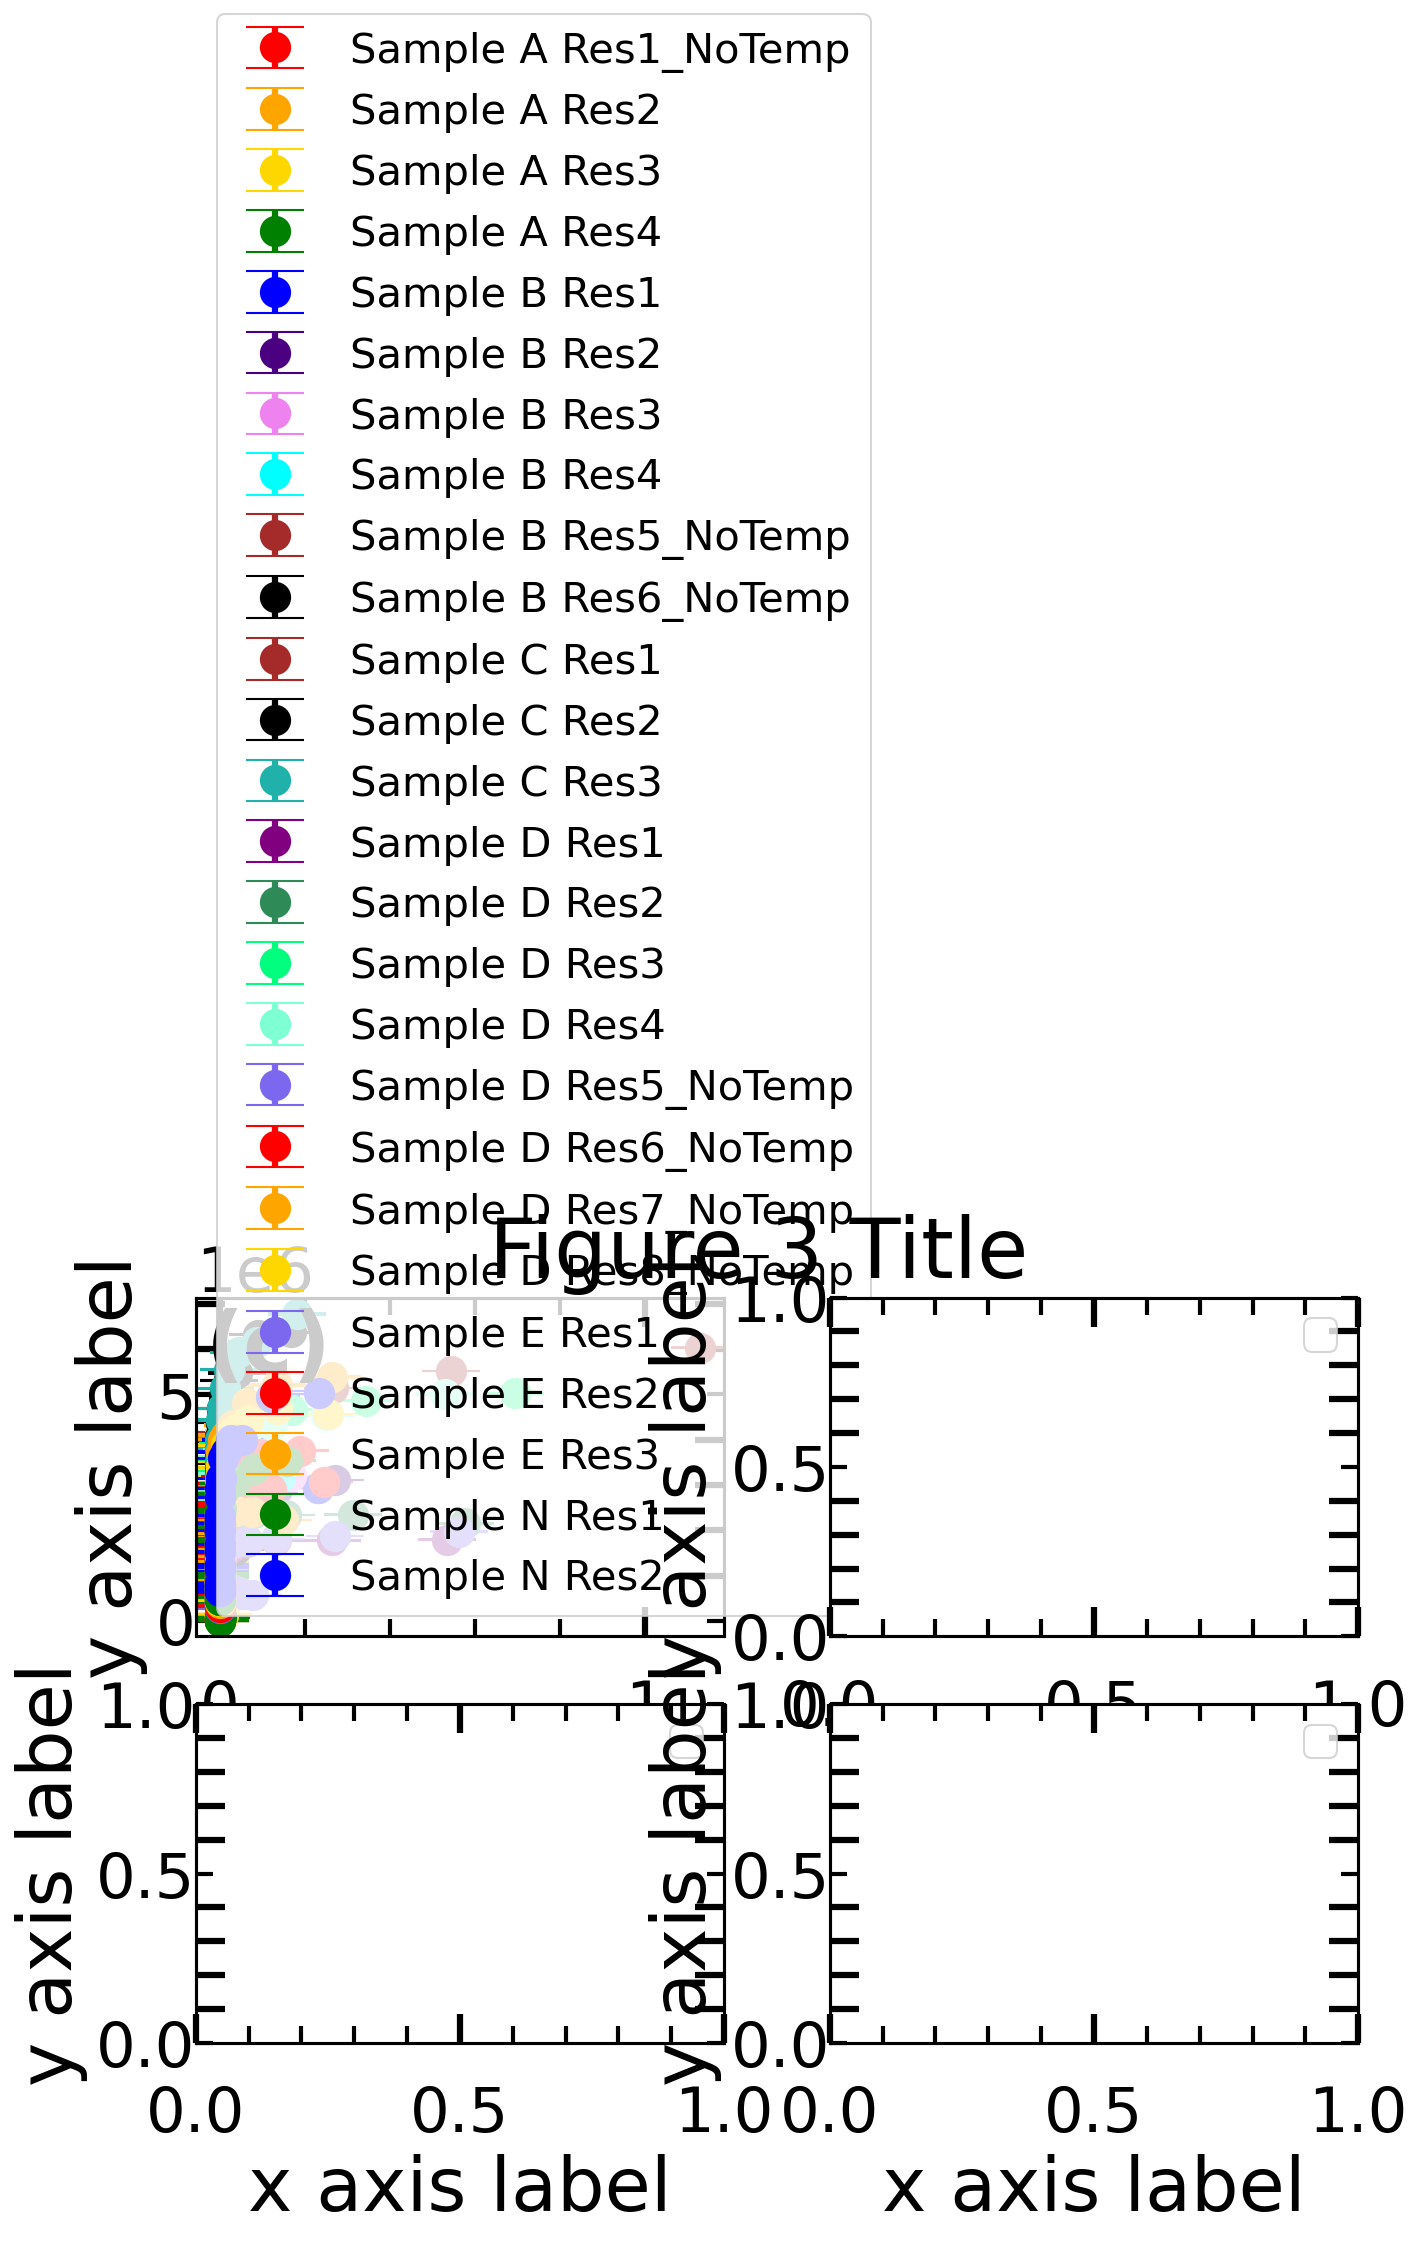

PosixPath('paper_figures/fig3.pdf')

In [6]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  FIGURE CELL 3 — Figure 3 Title                                       ║
# ╚══════════════════════════════════════════════════════════════════════╝
# Requires: Cell 1 (data_dict) and Cell 2 (formatting helpers).
# Edit the CONFIG block below; do not change code below '# ── END CONFIG'.

# ── CONFIG ────────────────────────────────────────────────────────────────

FIG3_TITLE    = 'Figure 3 Title'
FIG3_LABEL    = '(c)'        # panel label drawn in top-left corner of panel 0
FIG3_FILENAME = 'fig3'               # saved to ./paper_figures/

# Figure dimensions in inches (width, height). PHYSICAL size of the exported PDF.
FIG3_WIDTH  = 10   # inches
FIG3_HEIGHT = 4    # inches

# Grid layout: set rows × cols explicitly.
# Unused trailing slots are hidden automatically.
FIG3_ROWS = 2   # number of subplot rows
FIG3_COLS = 4   # number of subplot columns

# ── Figure-level legend ───────────────────────────────────────────────────
# One legend for the whole figure, drawn outside the panels.
# Each entry is a tuple: (label_string, color, marker_shape)
#
# marker_shape uses standard matplotlib marker codes, e.g.:
#   'o' circle  's' square  '^' triangle-up  'D' diamond
#   'v' triangle-down  '>' triangle-right  'p' pentagon  '*' star
#
# The legend is placed to the right of the rightmost panel by default.
# Set FIG3_LEGEND = [] to suppress the legend entirely.

# List sample names to include in the legend (order = display order).
# Each name is looked up in SAMPLE_STYLES for color/marker and in data_dict
# for its stress value, which becomes the label ("<stress> MPa").
# You can also mix in manual (label, color, marker) tuples if needed.
FIG3_LEGEND = [
    'Sample A',
    'Sample B',
    'Sample C',
    'Sample D',
    'Sample E',
    'Sample N',
]
# Legend anchor position in figure-fraction coordinates (0–1).
# (1.0, 0.5) = right edge, vertically centred.  Increase X beyond 1 to
# push further right if panels are wide; decrease to move left into whitespace.
FIG3_LEGEND_X = 0.91  # horizontal anchor (figure fraction); sits in the right-margin gap
FIG3_LEGEND_Y = 0.5   # vertical anchor   (figure fraction)

# ── Per-panel configuration ───────────────────────────────────────────────
# FIG3_PANELS is a list of dicts, one per panel (left-to-right, top-to-bottom).
# Panels beyond ROWS × COLS are ignored. Unfilled grid slots are hidden.
#
# Required keys per panel dict:
#   'samples'            : list of sample names from data_dict to plot in this panel.
#                          Use None or [] to leave the panel blank.
#   'resonators'         : list of resonator keys to include, e.g. ['Res1', 'Res2'].
#                          Use None to plot ALL resonators found in each sample.
#   'exclude_resonators' : list of resonator keys to skip, e.g. ['Res1'].
#                          Applied after 'resonators'; use None to skip nothing.
#                          Per-sample exclusions: dict keyed by sample name, e.g.
#                          {'Sample A': ['Res1'], 'Sample B': ['Res3']}
#   'x_key'              : data_dict key for the x axis, e.g. 'Num_Photon' or 'Temp'.
#   'y_key'              : data_dict key for the y axis, e.g. 'Qi_Power' or 'Qi_Temp'.
#   'ye_key'             : data_dict key for y error bars (set to None to suppress).
#
# Optional keys per panel dict:
#   'xlabel'     : x-axis label string  (default: '')
#   'ylabel'     : y-axis label string  (default: '')
#   'xscale'     : 'linear' or 'log'   (default: 'linear')
#   'yscale'     : 'linear' or 'log'   (default: 'linear')
#   'xlim'       : (lo, hi) or None    (default: None = auto)
#   'ylim'       : (lo, hi) or None    (default: None = auto)
#   'title'      : panel title string  (default: None = no title)
#
# Common x/y key names:
#   Qi_Temp, Qi_Power, Num_Photon, Temp, Freq,
#   Q_Temp, Qc_Temp, Freq_err_Temp, Power_Freq, Power_Freq_err

FIG3_PANELS = [
    # Panel 0
    dict(
        samples             = ['Sample A'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample A',
    ),
    # Panel 1
    dict(
        samples             = ['Sample B'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample B',
    ),
    # Panel 2
    dict(
        samples             = ['Sample C'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample C',
    ),
    # Panel 3
    dict(
        samples             = ['Sample D'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample D',
    ),
    # Panel 4
    dict(
        samples             = ['Sample E'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample E',
    ),
    # Panel 5
    dict(
        samples             = ['Sample N'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample N',
    ),
    # Panel 6 — overlay multiple samples on one panel
    dict(
        samples             = ['Sample A', 'Sample B'],
        resonators          = ['Res1', 'Res2'],
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'A vs B (Res1, Res2)',
    ),
    # Panel 7
    dict(
        samples             = ['Sample C', 'Sample D'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Temp',
        y_key               = 'Qi_Temp',
        ye_key              = 'Qi_Temp_err',
        xlabel              = 'T (mK)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'linear',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Loss vs T',
    ),
]

# ── END CONFIG ────────────────────────────────────────────────────────────

# ── Build figure ──────────────────────────────────────────────────────────
_n_slots3 = FIG3_ROWS * FIG3_COLS
_n_panels3 = min(len(FIG3_PANELS), _n_slots3)

_fig3_size = (FIG3_WIDTH, FIG3_HEIGHT)
if FIG3_ROWS == 1 and FIG3_COLS == 1:
    fig3, _ax_raw3 = plt.subplots(figsize=_fig3_size,
                                      layout='constrained')
    _axes_flat3 = np.array([_ax_raw3])
else:
    fig3, _ax_raw3 = plt.subplots(FIG3_ROWS, FIG3_COLS, figsize=_fig3_size,
                                      squeeze=False, layout='constrained')
    _axes_flat3 = np.array(_ax_raw3).flatten()

# layout='constrained' (set above) manages margins automatically.
# subplots_adjust is not used — it conflicts with constrained_layout.
# To add extra padding around the figure, edit FMT['left'/'right'/'bottom'/'top']
# then call fig3.set_constrained_layout_pads(w_pad=..., h_pad=...) after this block.

# Hide unused grid slots
for _k3 in range(_n_panels3, len(_axes_flat3)):
    _axes_flat3[_k3].axis('off')

# ── Plotting loop (no per-panel legend) ───────────────────────────────────
for _pi3, _pcfg3 in enumerate(FIG3_PANELS[:_n_panels3]):
    _ax3 = _axes_flat3[_pi3]

    _samples3    = _pcfg3.get('samples') or []
    _res_filter3 = _pcfg3.get('resonators')
    _xk3         = _pcfg3['x_key']
    _yk3         = _pcfg3['y_key']
    _yek3        = _pcfg3.get('ye_key')

    for _sample3 in _samples3:
        _chip3 = data_dict.get(_sample3, {})
        _excl_raw3 = _pcfg3.get('exclude_resonators')
        if isinstance(_excl_raw3, dict):
            _excl3 = _excl_raw3.get(_sample3, []) or []
        else:
            _excl3 = _excl_raw3 or []
        _res_keys3 = [
            k for k, v in _chip3.items()
            if isinstance(v, dict)
            and (_res_filter3 is None or k in _res_filter3)
            and k not in _excl3
        ]
        _color3, _marker3 = get_sample_style(_sample3)

        for _rk3 in _res_keys3:
            _rd3 = _chip3[_rk3]
            if _xk3 not in _rd3 or _yk3 not in _rd3:
                continue
            _x3  = _rd3[_xk3]
            _y3  = _rd3[_yk3]
            _ye3 = _rd3.get(_yek3) if _yek3 else None
            # Normalise Qi data to millions (y / 1e6) so axis reads in units of 10^6
            if 'Qi' in _yk3:
                _y3 = _y3 / 1e6
                if _ye3 is not None:
                    _ye3 = _ye3 / 1e6
            # Normalise frequency data to the first index (f / f_0)
            if 'Freq' in _yk3:
                _f03 = float(_y3[0]) if hasattr(_y3, '__len__') and len(_y3) > 0 else 1.0
                if _f03 != 0:
                    _y3  = _y3  / _f03
                    if _ye3 is not None:
                        _ye3 = _ye3 / _f03
            _ax3.errorbar(
                _x3, _y3, yerr=_ye3,
                fmt=_marker3 + '-',
                ms=FMT['marker_size'],
                capsize=FMT['cap_size'],
                elinewidth=FMT['err_lw'],
                color=_color3,
            )

    # ── Per-panel cosmetics ───────────────────────────────────────────────
    apply_axes_style(
        _ax3,
        xlabel=_pcfg3.get('xlabel', ''),
        ylabel=_pcfg3.get('ylabel', ''),
        xscale=_pcfg3.get('xscale', 'linear'),
        yscale=_pcfg3.get('yscale', 'linear'),
    )
    _xlim3 = _pcfg3.get('xlim')
    _ylim3 = _pcfg3.get('ylim')
    if _xlim3: _ax3.set_xlim(*_xlim3)
    if _ylim3: _ax3.set_ylim(*_ylim3)
    _ptitle3 = _pcfg3.get('title')
    if _ptitle3: _ax3.set_title(_ptitle3, fontsize=FMT['title_size'] * 0.6)

# ── Figure-level legend ───────────────────────────────────────────────────
if FIG3_LEGEND:
    _leg3 = fig3.legend(
        handles=make_legend_handles(FIG3_LEGEND),
        loc='center left',
        bbox_to_anchor=(FIG3_LEGEND_X, FIG3_LEGEND_Y),
        bbox_transform=fig3.transFigure,
        fontsize=FMT['legend_size'],
        frameon=True,
        borderpad=0.6,
        handlelength=1.4,
        handletextpad=0.5,
        labelspacing=0.4,
    )

# Panel label on first axes
_axes_flat3[0].text(
    0.02, 0.97, FIG3_LABEL,
    transform=_axes_flat3[0].transAxes,
    fontsize=FMT['title_size'], fontweight='bold', va='top', ha='left',
)

save_figure(fig3, FIG3_FILENAME)


### Figure Cell 4
*Custom figure 4*  
Edit `FIG4_*` variables in the CONFIG block to customise.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  FIGURE CELL 4 — Figure 4 Title                                       ║
# ╚══════════════════════════════════════════════════════════════════════╝
# Requires: Cell 1 (data_dict) and Cell 2 (formatting helpers).
# Edit the CONFIG block below; do not change code below '# ── END CONFIG'.

# ── CONFIG ────────────────────────────────────────────────────────────────

FIG4_TITLE    = 'Figure 4 Title'
FIG4_LABEL    = '(d)'        # panel label drawn in top-left corner of panel 0
FIG4_FILENAME = 'fig4'               # saved to ./paper_figures/

# Figure dimensions in inches (width, height). PHYSICAL size of the exported PDF.
FIG4_WIDTH  = 10   # inches
FIG4_HEIGHT = 4    # inches

# Grid layout: set rows × cols explicitly.
# Unused trailing slots are hidden automatically.
FIG4_ROWS = 2   # number of subplot rows
FIG4_COLS = 4   # number of subplot columns

# ── Figure-level legend ───────────────────────────────────────────────────
# One legend for the whole figure, drawn outside the panels.
# Each entry is a tuple: (label_string, color, marker_shape)
#
# marker_shape uses standard matplotlib marker codes, e.g.:
#   'o' circle  's' square  '^' triangle-up  'D' diamond
#   'v' triangle-down  '>' triangle-right  'p' pentagon  '*' star
#
# The legend is placed to the right of the rightmost panel by default.
# Set FIG4_LEGEND = [] to suppress the legend entirely.

# List sample names to include in the legend (order = display order).
# Each name is looked up in SAMPLE_STYLES for color/marker and in data_dict
# for its stress value, which becomes the label ("<stress> MPa").
# You can also mix in manual (label, color, marker) tuples if needed.
FIG4_LEGEND = [
    'Sample A',
    'Sample B',
    'Sample C',
    'Sample D',
    'Sample E',
    'Sample N',
]
# Legend anchor position in figure-fraction coordinates (0–1).
# (1.0, 0.5) = right edge, vertically centred.  Increase X beyond 1 to
# push further right if panels are wide; decrease to move left into whitespace.
FIG4_LEGEND_X = 0.91  # horizontal anchor (figure fraction); sits in the right-margin gap
FIG4_LEGEND_Y = 0.5   # vertical anchor   (figure fraction)

# ── Per-panel configuration ───────────────────────────────────────────────
# FIG4_PANELS is a list of dicts, one per panel (left-to-right, top-to-bottom).
# Panels beyond ROWS × COLS are ignored. Unfilled grid slots are hidden.
#
# Required keys per panel dict:
#   'samples'            : list of sample names from data_dict to plot in this panel.
#                          Use None or [] to leave the panel blank.
#   'resonators'         : list of resonator keys to include, e.g. ['Res1', 'Res2'].
#                          Use None to plot ALL resonators found in each sample.
#   'exclude_resonators' : list of resonator keys to skip, e.g. ['Res1'].
#                          Applied after 'resonators'; use None to skip nothing.
#                          Per-sample exclusions: dict keyed by sample name, e.g.
#                          {'Sample A': ['Res1'], 'Sample B': ['Res3']}
#   'x_key'              : data_dict key for the x axis, e.g. 'Num_Photon' or 'Temp'.
#   'y_key'              : data_dict key for the y axis, e.g. 'Qi_Power' or 'Qi_Temp'.
#   'ye_key'             : data_dict key for y error bars (set to None to suppress).
#
# Optional keys per panel dict:
#   'xlabel'     : x-axis label string  (default: '')
#   'ylabel'     : y-axis label string  (default: '')
#   'xscale'     : 'linear' or 'log'   (default: 'linear')
#   'yscale'     : 'linear' or 'log'   (default: 'linear')
#   'xlim'       : (lo, hi) or None    (default: None = auto)
#   'ylim'       : (lo, hi) or None    (default: None = auto)
#   'title'      : panel title string  (default: None = no title)
#
# Common x/y key names:
#   Qi_Temp, Qi_Power, Num_Photon, Temp, Freq,
#   Q_Temp, Qc_Temp, Freq_err_Temp, Power_Freq, Power_Freq_err

FIG4_PANELS = [
    # Panel 0
    dict(
        samples             = ['Sample A'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample A',
    ),
    # Panel 1
    dict(
        samples             = ['Sample B'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample B',
    ),
    # Panel 2
    dict(
        samples             = ['Sample C'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample C',
    ),
    # Panel 3
    dict(
        samples             = ['Sample D'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample D',
    ),
    # Panel 4
    dict(
        samples             = ['Sample E'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample E',
    ),
    # Panel 5
    dict(
        samples             = ['Sample N'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample N',
    ),
    # Panel 6 — overlay multiple samples on one panel
    dict(
        samples             = ['Sample A', 'Sample B'],
        resonators          = ['Res1', 'Res2'],
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'A vs B (Res1, Res2)',
    ),
    # Panel 7
    dict(
        samples             = ['Sample C', 'Sample D'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Temp',
        y_key               = 'Qi_Temp',
        ye_key              = 'Qi_Temp_err',
        xlabel              = 'T (mK)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'linear',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Loss vs T',
    ),
]

# ── END CONFIG ────────────────────────────────────────────────────────────

# ── Build figure ──────────────────────────────────────────────────────────
_n_slots4 = FIG4_ROWS * FIG4_COLS
_n_panels4 = min(len(FIG4_PANELS), _n_slots4)

_fig4_size = (FIG4_WIDTH, FIG4_HEIGHT)
if FIG4_ROWS == 1 and FIG4_COLS == 1:
    fig4, _ax_raw4 = plt.subplots(figsize=_fig4_size,
                                      layout='constrained')
    _axes_flat4 = np.array([_ax_raw4])
else:
    fig4, _ax_raw4 = plt.subplots(FIG4_ROWS, FIG4_COLS, figsize=_fig4_size,
                                      squeeze=False, layout='constrained')
    _axes_flat4 = np.array(_ax_raw4).flatten()

# layout='constrained' (set above) manages margins automatically.
# subplots_adjust is not used — it conflicts with constrained_layout.
# To add extra padding around the figure, edit FMT['left'/'right'/'bottom'/'top']
# then call fig4.set_constrained_layout_pads(w_pad=..., h_pad=...) after this block.

# Hide unused grid slots
for _k4 in range(_n_panels4, len(_axes_flat4)):
    _axes_flat4[_k4].axis('off')

# ── Plotting loop (no per-panel legend) ───────────────────────────────────
for _pi4, _pcfg4 in enumerate(FIG4_PANELS[:_n_panels4]):
    _ax4 = _axes_flat4[_pi4]

    _samples4    = _pcfg4.get('samples') or []
    _res_filter4 = _pcfg4.get('resonators')
    _xk4         = _pcfg4['x_key']
    _yk4         = _pcfg4['y_key']
    _yek4        = _pcfg4.get('ye_key')

    for _sample4 in _samples4:
        _chip4 = data_dict.get(_sample4, {})
        _excl_raw4 = _pcfg4.get('exclude_resonators')
        if isinstance(_excl_raw4, dict):
            _excl4 = _excl_raw4.get(_sample4, []) or []
        else:
            _excl4 = _excl_raw4 or []
        _res_keys4 = [
            k for k, v in _chip4.items()
            if isinstance(v, dict)
            and (_res_filter4 is None or k in _res_filter4)
            and k not in _excl4
        ]
        _color4, _marker4 = get_sample_style(_sample4)

        for _rk4 in _res_keys4:
            _rd4 = _chip4[_rk4]
            if _xk4 not in _rd4 or _yk4 not in _rd4:
                continue
            _x4  = _rd4[_xk4]
            _y4  = _rd4[_yk4]
            _ye4 = _rd4.get(_yek4) if _yek4 else None
            # Normalise Qi data to millions (y / 1e6) so axis reads in units of 10^6
            if 'Qi' in _yk4:
                _y4 = _y4 / 1e6
                if _ye4 is not None:
                    _ye4 = _ye4 / 1e6
            # Normalise frequency data to the first index (f / f_0)
            if 'Freq' in _yk4:
                _f04 = float(_y4[0]) if hasattr(_y4, '__len__') and len(_y4) > 0 else 1.0
                if _f04 != 0:
                    _y4  = _y4  / _f04
                    if _ye4 is not None:
                        _ye4 = _ye4 / _f04
            _ax4.errorbar(
                _x4, _y4, yerr=_ye4,
                fmt=_marker4 + '-',
                ms=FMT['marker_size'],
                capsize=FMT['cap_size'],
                elinewidth=FMT['err_lw'],
                color=_color4,
            )

    # ── Per-panel cosmetics ───────────────────────────────────────────────
    apply_axes_style(
        _ax4,
        xlabel=_pcfg4.get('xlabel', ''),
        ylabel=_pcfg4.get('ylabel', ''),
        xscale=_pcfg4.get('xscale', 'linear'),
        yscale=_pcfg4.get('yscale', 'linear'),
    )
    _xlim4 = _pcfg4.get('xlim')
    _ylim4 = _pcfg4.get('ylim')
    if _xlim4: _ax4.set_xlim(*_xlim4)
    if _ylim4: _ax4.set_ylim(*_ylim4)
    _ptitle4 = _pcfg4.get('title')
    if _ptitle4: _ax4.set_title(_ptitle4, fontsize=FMT['title_size'] * 0.6)

# ── Figure-level legend ───────────────────────────────────────────────────
if FIG4_LEGEND:
    _leg4 = fig4.legend(
        handles=make_legend_handles(FIG4_LEGEND),
        loc='center left',
        bbox_to_anchor=(FIG4_LEGEND_X, FIG4_LEGEND_Y),
        bbox_transform=fig4.transFigure,
        fontsize=FMT['legend_size'],
        frameon=True,
        borderpad=0.6,
        handlelength=1.4,
        handletextpad=0.5,
        labelspacing=0.4,
    )

# Panel label on first axes
_axes_flat4[0].text(
    0.02, 0.97, FIG4_LABEL,
    transform=_axes_flat4[0].transAxes,
    fontsize=FMT['title_size'], fontweight='bold', va='top', ha='left',
)

save_figure(fig4, FIG4_FILENAME)


### Figure Cell 5
*Custom figure 5*  
Edit `FIG5_*` variables in the CONFIG block to customise.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  FIGURE CELL 5 — Figure 5 Title                                       ║
# ╚══════════════════════════════════════════════════════════════════════╝
# Requires: Cell 1 (data_dict) and Cell 2 (formatting helpers).
# Edit the CONFIG block below; do not change code below '# ── END CONFIG'.

# ── CONFIG ────────────────────────────────────────────────────────────────

FIG5_TITLE    = 'Figure 5 Title'
FIG5_LABEL    = '(e)'        # panel label drawn in top-left corner of panel 0
FIG5_FILENAME = 'fig5'               # saved to ./paper_figures/

# Figure dimensions in inches (width, height). PHYSICAL size of the exported PDF.
FIG5_WIDTH  = 10   # inches
FIG5_HEIGHT = 4    # inches

# Grid layout: set rows × cols explicitly.
# Unused trailing slots are hidden automatically.
FIG5_ROWS = 2   # number of subplot rows
FIG5_COLS = 4   # number of subplot columns

# ── Figure-level legend ───────────────────────────────────────────────────
# One legend for the whole figure, drawn outside the panels.
# Each entry is a tuple: (label_string, color, marker_shape)
#
# marker_shape uses standard matplotlib marker codes, e.g.:
#   'o' circle  's' square  '^' triangle-up  'D' diamond
#   'v' triangle-down  '>' triangle-right  'p' pentagon  '*' star
#
# The legend is placed to the right of the rightmost panel by default.
# Set FIG5_LEGEND = [] to suppress the legend entirely.

# List sample names to include in the legend (order = display order).
# Each name is looked up in SAMPLE_STYLES for color/marker and in data_dict
# for its stress value, which becomes the label ("<stress> MPa").
# You can also mix in manual (label, color, marker) tuples if needed.
FIG5_LEGEND = [
    'Sample A',
    'Sample B',
    'Sample C',
    'Sample D',
    'Sample E',
    'Sample N',
]
# Legend anchor position in figure-fraction coordinates (0–1).
# (1.0, 0.5) = right edge, vertically centred.  Increase X beyond 1 to
# push further right if panels are wide; decrease to move left into whitespace.
FIG5_LEGEND_X = 0.91  # horizontal anchor (figure fraction); sits in the right-margin gap
FIG5_LEGEND_Y = 0.5   # vertical anchor   (figure fraction)

# ── Per-panel configuration ───────────────────────────────────────────────
# FIG5_PANELS is a list of dicts, one per panel (left-to-right, top-to-bottom).
# Panels beyond ROWS × COLS are ignored. Unfilled grid slots are hidden.
#
# Required keys per panel dict:
#   'samples'            : list of sample names from data_dict to plot in this panel.
#                          Use None or [] to leave the panel blank.
#   'resonators'         : list of resonator keys to include, e.g. ['Res1', 'Res2'].
#                          Use None to plot ALL resonators found in each sample.
#   'exclude_resonators' : list of resonator keys to skip, e.g. ['Res1'].
#                          Applied after 'resonators'; use None to skip nothing.
#                          Per-sample exclusions: dict keyed by sample name, e.g.
#                          {'Sample A': ['Res1'], 'Sample B': ['Res3']}
#   'x_key'              : data_dict key for the x axis, e.g. 'Num_Photon' or 'Temp'.
#   'y_key'              : data_dict key for the y axis, e.g. 'Qi_Power' or 'Qi_Temp'.
#   'ye_key'             : data_dict key for y error bars (set to None to suppress).
#
# Optional keys per panel dict:
#   'xlabel'     : x-axis label string  (default: '')
#   'ylabel'     : y-axis label string  (default: '')
#   'xscale'     : 'linear' or 'log'   (default: 'linear')
#   'yscale'     : 'linear' or 'log'   (default: 'linear')
#   'xlim'       : (lo, hi) or None    (default: None = auto)
#   'ylim'       : (lo, hi) or None    (default: None = auto)
#   'title'      : panel title string  (default: None = no title)
#
# Common x/y key names:
#   Qi_Temp, Qi_Power, Num_Photon, Temp, Freq,
#   Q_Temp, Qc_Temp, Freq_err_Temp, Power_Freq, Power_Freq_err

FIG5_PANELS = [
    # Panel 0
    dict(
        samples             = ['Sample A'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample A',
    ),
    # Panel 1
    dict(
        samples             = ['Sample B'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample B',
    ),
    # Panel 2
    dict(
        samples             = ['Sample C'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample C',
    ),
    # Panel 3
    dict(
        samples             = ['Sample D'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample D',
    ),
    # Panel 4
    dict(
        samples             = ['Sample E'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample E',
    ),
    # Panel 5
    dict(
        samples             = ['Sample N'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Sample N',
    ),
    # Panel 6 — overlay multiple samples on one panel
    dict(
        samples             = ['Sample A', 'Sample B'],
        resonators          = ['Res1', 'Res2'],
        exclude_resonators  = None,
        x_key               = 'Num_Photon',
        y_key               = 'Qi_Power',
        ye_key              = 'Qi_Power_err',
        xlabel              = r'$\langle n \rangle$ (photons)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'log',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'A vs B (Res1, Res2)',
    ),
    # Panel 7
    dict(
        samples             = ['Sample C', 'Sample D'],
        resonators          = None,
        exclude_resonators  = None,
        x_key               = 'Temp',
        y_key               = 'Qi_Temp',
        ye_key              = 'Qi_Temp_err',
        xlabel              = 'T (mK)',
        ylabel              = r'$Q_i$ $(10^6)$',
        xscale              = 'linear',
        yscale              = 'log',
        xlim                = None,
        ylim                = None,
        title               = 'Loss vs T',
    ),
]

# ── END CONFIG ────────────────────────────────────────────────────────────

# ── Build figure ──────────────────────────────────────────────────────────
_n_slots5 = FIG5_ROWS * FIG5_COLS
_n_panels5 = min(len(FIG5_PANELS), _n_slots5)

_fig5_size = (FIG5_WIDTH, FIG5_HEIGHT)
if FIG5_ROWS == 1 and FIG5_COLS == 1:
    fig5, _ax_raw5 = plt.subplots(figsize=_fig5_size,
                                      layout='constrained')
    _axes_flat5 = np.array([_ax_raw5])
else:
    fig5, _ax_raw5 = plt.subplots(FIG5_ROWS, FIG5_COLS, figsize=_fig5_size,
                                      squeeze=False, layout='constrained')
    _axes_flat5 = np.array(_ax_raw5).flatten()

# layout='constrained' (set above) manages margins automatically.
# subplots_adjust is not used — it conflicts with constrained_layout.
# To add extra padding around the figure, edit FMT['left'/'right'/'bottom'/'top']
# then call fig5.set_constrained_layout_pads(w_pad=..., h_pad=...) after this block.

# Hide unused grid slots
for _k5 in range(_n_panels5, len(_axes_flat5)):
    _axes_flat5[_k5].axis('off')

# ── Plotting loop (no per-panel legend) ───────────────────────────────────
for _pi5, _pcfg5 in enumerate(FIG5_PANELS[:_n_panels5]):
    _ax5 = _axes_flat5[_pi5]

    _samples5    = _pcfg5.get('samples') or []
    _res_filter5 = _pcfg5.get('resonators')
    _xk5         = _pcfg5['x_key']
    _yk5         = _pcfg5['y_key']
    _yek5        = _pcfg5.get('ye_key')

    for _sample5 in _samples5:
        _chip5 = data_dict.get(_sample5, {})
        _excl_raw5 = _pcfg5.get('exclude_resonators')
        if isinstance(_excl_raw5, dict):
            _excl5 = _excl_raw5.get(_sample5, []) or []
        else:
            _excl5 = _excl_raw5 or []
        _res_keys5 = [
            k for k, v in _chip5.items()
            if isinstance(v, dict)
            and (_res_filter5 is None or k in _res_filter5)
            and k not in _excl5
        ]
        _color5, _marker5 = get_sample_style(_sample5)

        for _rk5 in _res_keys5:
            _rd5 = _chip5[_rk5]
            if _xk5 not in _rd5 or _yk5 not in _rd5:
                continue
            _x5  = _rd5[_xk5]
            _y5  = _rd5[_yk5]
            _ye5 = _rd5.get(_yek5) if _yek5 else None
            # Normalise Qi data to millions (y / 1e6) so axis reads in units of 10^6
            if 'Qi' in _yk5:
                _y5 = _y5 / 1e6
                if _ye5 is not None:
                    _ye5 = _ye5 / 1e6
            # Normalise frequency data to the first index (f / f_0)
            if 'Freq' in _yk5:
                _f05 = float(_y5[0]) if hasattr(_y5, '__len__') and len(_y5) > 0 else 1.0
                if _f05 != 0:
                    _y5  = _y5  / _f05
                    if _ye5 is not None:
                        _ye5 = _ye5 / _f05
            _ax5.errorbar(
                _x5, _y5, yerr=_ye5,
                fmt=_marker5 + '-',
                ms=FMT['marker_size'],
                capsize=FMT['cap_size'],
                elinewidth=FMT['err_lw'],
                color=_color5,
            )

    # ── Per-panel cosmetics ───────────────────────────────────────────────
    apply_axes_style(
        _ax5,
        xlabel=_pcfg5.get('xlabel', ''),
        ylabel=_pcfg5.get('ylabel', ''),
        xscale=_pcfg5.get('xscale', 'linear'),
        yscale=_pcfg5.get('yscale', 'linear'),
    )
    _xlim5 = _pcfg5.get('xlim')
    _ylim5 = _pcfg5.get('ylim')
    if _xlim5: _ax5.set_xlim(*_xlim5)
    if _ylim5: _ax5.set_ylim(*_ylim5)
    _ptitle5 = _pcfg5.get('title')
    if _ptitle5: _ax5.set_title(_ptitle5, fontsize=FMT['title_size'] * 0.6)

# ── Figure-level legend ───────────────────────────────────────────────────
if FIG5_LEGEND:
    _leg5 = fig5.legend(
        handles=make_legend_handles(FIG5_LEGEND),
        loc='center left',
        bbox_to_anchor=(FIG5_LEGEND_X, FIG5_LEGEND_Y),
        bbox_transform=fig5.transFigure,
        fontsize=FMT['legend_size'],
        frameon=True,
        borderpad=0.6,
        handlelength=1.4,
        handletextpad=0.5,
        labelspacing=0.4,
    )

# Panel label on first axes
_axes_flat5[0].text(
    0.02, 0.97, FIG5_LABEL,
    transform=_axes_flat5[0].transAxes,
    fontsize=FMT['title_size'], fontweight='bold', va='top', ha='left',
)

save_figure(fig5, FIG5_FILENAME)
